# Bayesian Optimisation: ERK Oscillation (v11 — fixed light-budget, NO led_power)

v11 pins the **total light budget** to a single value
(`LIGHT_BUDGET_MS`, defined in the parameter cell below) and lets the
BO search only over `(ramp_fraction, pulse_interval)`.  The question
the optimiser answers is therefore *"given a fixed dose of LED-on
time, what's the best way to distribute it?"* — a clean efficiency
question, no dose vs. response trade-off.

| Notebook | BO axes | Objective |
|---|---|---|
| `…_testv10_led_power.ipynb`     | `led_power × stim_exposure × ramp × pulse_interval` | `frac_responders` |
| `…_testv11_light_budget.ipynb` (this) | `ramp_fraction × pulse_interval` (light_budget pinned) | `frac_responders` |
| `…_testv12_light_budget_auc.ipynb` | `light_budget × ramp_fraction × pulse_interval` | `auc_per_light` |

**Pinned `light_budget`.**  At fixed total dose, the 3D physical space
`(stim_exposure, ramp, pulse_interval)` reduces to a 2D surface — the
constraint `n*stim_exposure + ramp*n*(n-1)/2 = LIGHT_BUDGET_MS` removes
one degree of freedom.  `(ramp_fraction, pulse_interval)` are the
natural coordinates on that surface, so dropping `light_budget` from
the BO axes is *not* a loss of expressivity — `stim_exposure` and
`ramp` are still computed per pulse, just from those two knobs plus
the pinned budget.

**Carried over from the original v11:**

1. `pulse_interval` grid: 1–10 frames step 1 ⇒ {1, 2, ..., 10}.
2. FOV finder pre-screen with `FE_ErkKtr` + CNR < 1.0 in ≥ 75 % of cells.
3. Quality gates unchanged (`max_baseline_cnr=1.0`, `min_track_fraction=0.8`).

Total grid: 11 × 10 = **110 candidate conditions**.


In [1]:
import os
import time
import logging
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP, viGP, viSparseGP), so we install stubs
# that raise only if viDKL is actually called. This MUST run before any
# `import gpax` (including the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
)
from faro.agents.bo_oscillation import OscillationBO
import faro.core.utils as utils

## Microscope & pipeline setup

**Microscope:** Jungfrau (no DMD -- full-FOV stimulation).

**Channels:**
- Imaging: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- Stimulation: CyanStim (optogenetic activation, power 10)
- Optocheck: mCitrine (verify optoRTK expression, last frame only)

**Pipeline:** CellposeV4 segmentation -> ERK-KTR FE -> Trackpy tracking
-> OptoCheckFE on reference frames. Full-FOV stimulation (no DMD).

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [4]:
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [3]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari

In [7]:
WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

In [8]:
WELLS

['A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'A11',
 'A12',
 'B12',
 'B11',
 'B10',
 'B9',
 'B8',
 'B7',
 'B6',
 'B5',
 'B4',
 'B3',
 'B2',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'D12',
 'D11',
 'D10',
 'D9',
 'D8',
 'D7',
 'D6',
 'D5',
 'D4',
 'D3',
 'D2',
 'E2',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'E8',
 'E9',
 'E10',
 'E11',
 'E12',
 'F12',
 'F11',
 'F10',
 'F9',
 'F8',
 'F7',
 'F6',
 'F5',
 'F4',
 'F3',
 'F2',
 'G2',
 'G3',
 'G4',
 'G5',
 'G6',
 'G7',
 'G8',
 'G9',
 'G10',
 'G11',
 'G12',
 'H12',
 'H11',
 'H10',
 'H9',
 'H8',
 'H7',
 'H6',
 'H5',
 'H4',
 'H3',
 'H2']

In [5]:
len(WELLS)

88

In [9]:
# --- Experiment parameters ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# --- Light budget (PINNED -- not a BO axis in v11) ---
# Total LED-on time per condition, summed across all pulses.  The BO
# searches (ramp_fraction, pulse_interval) at this fixed dose.  Bump
# this if responders are weak, drop it if you want a stricter
# efficiency test.
LIGHT_BUDGET_MS = 10000.0

# Hardware/biology safeguard: any individual pulse exceeding this
# value is clipped (NOT dropped) inside OscillationBO and a loud
# warning is printed.  At LIGHT_BUDGET_MS=10000 + ramp_fraction=1
# + pulse_interval=9 the worst-case peak is ~5.7s, well under this
# cap, so the BO should never trigger it -- this is a defensive
# backstop against accidental budget bumps or math errors.
MAX_STIM_EXPOSURE_MS = 10000.0

# --- Phase layout (frames; 1 frame == 1 minute at TIME_BETWEEN_TIMESTEPS=60) ---
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20

# Derived (don't edit -- adjust the three above instead).
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY  # 90
FIRST_FRAME_STIM = N_FRAMES_BASELINE  # 10
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM  # 70

# --- Plate calibration ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder knobs ---
FOV_BORDER_UM = 1100.0
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 9

# --- Phased FOV layout ---
N_WELLS_PER_PHASE = 6
FOVS_PER_WELL = 3
N_FOVS = N_WELLS_PER_PHASE * FOVS_PER_WELL  # 18 FOVs per phase
N_CONDITIONS_PER_ITER = 3
FOVS_PER_CONDITION = N_FOVS // N_CONDITIONS_PER_ITER
N_PHASES = 13

WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE]


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-08_bo_erk_oscillation_v11_light_budget_fixed10s_pi10"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (base -- exposure is overridden by BO; power fixed) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (acquired every timepoint AND used by FOV finder) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (acquired on last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)

In [7]:
len(WELLS) / N_WELLS_PER_PHASE

13.0

In [10]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4

# A single Cellpose instance is shared by the experiment pipeline AND the
# FOVFinderAgent below.  Reusing the same model avoids loading it twice
# (memory + GPU savings) and guarantees that the FOV finder counts cells
# with exactly the same segmentation the experiment will use.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,  # segment on miRFP (nuclear marker)
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)

from faro.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-08_bo_erk_oscillation_v11_light_budget_fixed10s_pi10\tracks created 


## FOV selection (per-phase, automated)

Instead of manually selecting 18 positions in napari, a `FOVFinderAgent`
(plugged into the generic `ComposedAgent`) picks fresh positions before
**every phase**:

1. The agent loads the plate calibration (`WellPlatePlan` JSON saved by
   the pymmcore-widgets MDA plate widget).
2. It pops the next `N_WELLS_PER_PHASE` (= 6) wells from `WELLS`.
3. For each well it generates `FOV_N_CANDIDATES_PER_WELL` (= 10) random
   candidate positions, kept `FOV_BORDER_UM` µm away from the well edge
   and at least `FOV_MIN_DISTANCE_UM` apart from each other.
4. It snaps the candidates with the segmentation channel only (miRFP)
   via `mic.run_mda` and segments the result with the **same**
   `CellposeV4` instance the experiment pipeline uses (`segmentator`).
5. Candidates with `< FOV_MIN_CELLS` cells are dropped; the remaining
   ones are reduced to `FOVS_PER_WELL` (= 3) per well by greedy
   farthest-point sampling so the picked FOVs do not overlap.

The result (18 fresh FOVs / phase) is fed straight into
`OscillationBO.run_one_phase`, which is wired up by the `ComposedAgent`
in the next sections.

The segmentator was already created in the pipeline cell above and is
reused here -- no extra setup needed.  The `FOVFinderAgent` is constructed
in the *Configure and run* section together with the BO agent and the
composed driver.


## Oscillation classifier

Load the pre-trained sliding-window oscillation classifier. This model
uses FFT, ACF, and time-domain features extracted from the ERK-KTR
`cnr` trace to classify each window as oscillating or not.

The classifier is restricted at runtime to the **stimulation window
only** (via `OscillationBO.classifier_window`, which defaults to
`(FIRST_FRAME_STIM, LAST_FRAME_STIM)`). Baseline and recovery frames
are acquired but not classified.

The BO target in this notebook is **`frac_responders`** — per FOV, the
fraction of valid cells whose **mean** classifier osc-probability across
the scoring window is `>= frac_responder_threshold` (default 0.75).
This is computed *directly* from the classifier's per-window
probabilities; the legacy 3-gate `frac_oscillating` rule (FFT amplitude
+ max probability + consecutive windows) is **not** used by the BO and
is disabled in the cell below by setting all three thresholds to 0.

Cells are only included in the responder calculation if they pass two
quality gates:
- Tracked for `>= min_track_fraction * n_frames` (default 80 %)
- Baseline CNR `< max_baseline_cnr` (default 1.0)


In [11]:
import joblib

# --- Load pre-trained oscillation classifier ---
CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"  # <-- UPDATE THIS PATH

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

# Import the predict_trace function from the classifier script
_classifier_script = "./apply_oscillation_classifier_v2.py"

_spec = importlib.util.spec_from_file_location("osc_classifier", _classifier_script)
_osc_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_osc_module)
predict_trace = _osc_module.predict_trace

# --- Oscillation thresholds ---
# A cell is oscillating iff ALL three gates pass (>= for all):
#   1. FFT amplitude score >= 0.3
#   2. Max osc. probability >= 0.95
#   3. Consecutive osc. windows >= 3
MIN_OSC_PROBABILITY = (
    0.0  # v6: gates disabled, BO target is frac_responders (mean prob >= 0.75 per cell)
)
MIN_CONSECUTIVE_WINDOWS = 0
MIN_FFT_AMPLITUDE = 0.0

print(f"Loaded oscillation classifier from {CLASSIFIER_PATH}")
print(f"  Window: {osc_cfg['window_size']} steps, stride {osc_cfg['window_step']}")
print(
    f"  Thresholds: prob >= {MIN_OSC_PROBABILITY}, "
    f"consecutive >= {MIN_CONSECUTIVE_WINDOWS}, "
    f"fft_amplitude >= {MIN_FFT_AMPLITUDE}"
)

Loaded oscillation classifier from ./oscillation_model_60min.joblib
  Window: 20 steps, stride 5
  Thresholds: prob >= 0.0, consecutive >= 0, fft_amplitude >= 0.0


## Batch BO agent

The :class:`OscillationBO` subclass of :class:`BOptGPAX` lives in
``faro.agents.bo_oscillation``.  It overrides:

- ``_create_events_for_batch`` -- builds RTMEvents for ``N_FOVS`` FOVs across
  ``N_CONDITIONS_PER_ITER`` conditions (``FOVS_PER_CONDITION`` each), applying
  per-frame ramped stim exposure.
- ``_preprocess_results`` -- runs the oscillation classifier on each cell's
  ``cnr`` trace (sliced to the stimulation window via ``classifier_window``)
  and computes the per-FOV oscillating fraction. Also computes the
  ``baseline_cnr`` covariate from the first ``n_baseline_frames``.
- ``_on_phase_complete`` -- live plotting + checkpoint saving + saves the
  trained GP to ``{storage_path}/bo_model.joblib`` for post-hoc analysis.

All batch-BO machinery (sequential greedy acquisition with local penalisation,
FOV-index offsetting across phases, ``run_one_phase`` integration with
``ComposedAgent``) is inherited from ``BOptGPAX``.  See
[faro/agents/bo_oscillation.py](../../faro/agents/bo_oscillation.py).


## Configure and run Bayesian Optimisation

**Parameter space (v11 fixed-budget):**

- `light_budget`: **PINNED at `LIGHT_BUDGET_MS`** (not a BO axis)
- `ramp_fraction`: 0.0–1.0 (step 0.1) = 11 levels
- `pulse_interval`: 1–10 frames step 1 = 10 levels ⇒ {1, 2, ..., 10}
- Total grid: 11 × 10 = **110 candidate conditions**

**Initial exploration cap (`initial_exploration_cap=0.7`):**
First 2 phases (farthest-point sampling) restrict to `ramp_fraction ≤
0.7`, `pulse_interval ≤ 7` (initial pool: 8 × 7 = 56 candidates).

**Covariates:** `n_cells`, `optortk_expression` (log-scaled),
`baseline_cnr`. Marginalised over during acquisition.

**Default objective: `frac_responders`** — per-FOV fraction of cells
whose per-cell mean classifier probability across the scoring window is
`≥ 0.75`.  At fixed `light_budget`, this rewards the most
oscillation-provoking distribution of the dose.

**FOV finder pre-screen.**  Each candidate FOV is now imaged with
miRFP + mScarlet3, segmented, run through `FE_ErkKtr` for per-cell CNR,
and rejected unless ≥ 75 % of cells have CNR < 1.0.  See the
`FOVFinderAgent(...)` invocation below.


In [12]:
from faro.agents import FOVFinderAgent, ComposedAgent, FOVCondition

# ---------------------------------------------------------------------------
# v11 fixed-budget reparameterisation: ramp_fraction / pulse_interval
# ---------------------------------------------------------------------------
# Same conversion math as v9/v11 (BudgetOscillationBO) but the total
# light_budget is pinned at the module-level LIGHT_BUDGET_MS instead of
# being a BO axis.  pulse_interval grid is 1-10 step 2 = {1, 3, 5, 7, 9}.


class BudgetOscillationBO(OscillationBO):
    """OscillationBO subclass: ramp_fraction / pulse_interval at fixed budget.

    The BO sees (ramp_fraction, pulse_interval); the total light dose is
    pinned at the module-level ``LIGHT_BUDGET_MS``.  Per-pulse
    ``stim_exposure`` and ``ramp`` are derived in
    :meth:`_create_events_for_batch` before delegating to the parent.
    ``df_results`` ends up with all five columns: ``light_budget``
    (constant), ``ramp_fraction`` (BO axis), ``pulse_interval`` (BO axis),
    plus the derived ``stim_exposure``, ``ramp``.  Per-FOV mean CNR-
    above-baseline is also computed as a diagnostic.
    """

    @staticmethod
    def _budget_to_base_ramp(budget, ramp_fraction, n_pulses):
        if n_pulses <= 0:
            return 0.0, 0.0
        if n_pulses == 1:
            return float(budget), 0.0
        base = float(budget) * (1.0 - float(ramp_fraction)) / n_pulses
        ramp = 2.0 * float(budget) * float(ramp_fraction) / (n_pulses * (n_pulses - 1))
        return base, ramp

    def _create_events_for_batch(self, param_list):
        converted = []
        for params in param_list:
            pi = max(1, int(params["pulse_interval"]))
            n = len(range(self.first_frame_stim, self.last_frame_stim, pi))
            base, ramp = self._budget_to_base_ramp(
                LIGHT_BUDGET_MS, params["ramp_fraction"], n
            )
            converted.append(
                {
                    **params,
                    "light_budget": LIGHT_BUDGET_MS,
                    "stim_exposure": base,
                    "ramp": ramp,
                    "pulse_interval": pi,
                }
            )
            print(
                f"    [fixed-budget reparam] light_budget={LIGHT_BUDGET_MS:.0f}ms, "
                f"ramp_fraction={params['ramp_fraction']:.2f}, "
                f"pulse_interval={pi}: n_pulses={n} -> "
                f"base={base:.1f}ms, ramp={ramp:.2f}ms/pulse, "
                f"peak={base + ramp * (n - 1):.1f}ms"
            )
        return super()._create_events_for_batch(converted)

    def _compute_auc_per_fov(self, fov_tracks):
        """Per-FOV CNR-above-baseline metrics (diagnostic only at fixed budget)."""
        phase_id = self._current_phase_id
        out = {}
        min_frames = int(self.min_track_fraction * self.n_frames)

        for fov_idx, df_tracks in fov_tracks.items():
            if df_tracks.empty or "particle" not in df_tracks.columns:
                continue
            if "phase_id" in df_tracks.columns:
                df_phase = df_tracks[df_tracks["phase_id"] == phase_id]
            else:
                df_phase = df_tracks
            if df_phase.empty:
                continue

            cnr_col = (
                "cnr"
                if "cnr" in df_phase.columns
                else "cnr_median" if "cnr_median" in df_phase.columns else None
            )
            if cnr_col is None:
                continue

            frames_per_cell = df_phase.groupby("particle")["fov_timestep"].nunique()
            well_tracked = set(frames_per_cell[frames_per_cell >= min_frames].index)

            baseline_df = df_phase[df_phase["fov_timestep"] < self.n_baseline_frames]
            per_cell_baseline = (
                baseline_df.groupby("particle")[cnr_col].mean().dropna()
                if not baseline_df.empty
                else pd.Series(dtype=float)
            )

            valid = well_tracked
            if self.max_baseline_cnr is not None and len(per_cell_baseline) > 0:
                valid = valid & set(
                    per_cell_baseline[per_cell_baseline < self.max_baseline_cnr].index
                )
            if not valid:
                continue

            in_stim = df_phase[
                (df_phase["fov_timestep"] >= self.first_frame_stim)
                & (df_phase["fov_timestep"] < self.last_frame_stim)
                & (df_phase["particle"].isin(valid))
            ]
            if in_stim.empty:
                continue

            per_cell_mean_cnr_stim = in_stim.groupby("particle")[cnr_col].mean()
            per_cell_above_baseline = (
                per_cell_mean_cnr_stim
                - per_cell_baseline.reindex(per_cell_mean_cnr_stim.index).fillna(0.0)
            )

            out[int(fov_idx)] = {
                "mean_cnr_stim": float(per_cell_mean_cnr_stim.mean()),
                "mean_cnr_above_baseline": float(per_cell_above_baseline.mean()),
            }
        return out

    def _preprocess_results(self, fov_tracks):
        df = super()._preprocess_results(fov_tracks)
        if df.empty:
            return df

        # light_budget is pinned at LIGHT_BUDGET_MS (not a BO axis); pull
        # ramp_fraction from the per-FOV condition map written by the BO.
        ramp_fracs = []
        for fov_idx in df["fov"].astype(int):
            params = self._current_condition_map.get(int(fov_idx), {})
            ramp_fracs.append(float(params.get("ramp_fraction", float("nan"))))
        df["light_budget"] = LIGHT_BUDGET_MS
        df["ramp_fraction"] = ramp_fracs

        auc_by_fov = self._compute_auc_per_fov(fov_tracks)
        df["mean_cnr_stim"] = [
            auc_by_fov.get(int(f), {}).get("mean_cnr_stim", 0.0)
            for f in df["fov"].astype(int)
        ]
        df["mean_cnr_above_baseline"] = [
            auc_by_fov.get(int(f), {}).get("mean_cnr_above_baseline", 0.0)
            for f in df["fov"].astype(int)
        ]
        # Note: no auc_per_light column at fixed budget -- it would be a
        # rescaled copy of mean_cnr_above_baseline (light_budget is constant).
        # See the v12 notebook for the real-AUC objective.
        return df


# --- BO parameters ----------------------------------------------------------
# Order matters: x_total_linespace is built via np.meshgrid(..., indexing="ij")
# so the FIRST parameter varies SLOWEST in the linearised grid.  The plot
# code below relies on (ramp_fraction, pulse_interval) order.
# light_budget is intentionally NOT in this list -- it is pinned at
# LIGHT_BUDGET_MS by BudgetOscillationBO above.
bo_params = [
    BO_Parameter(name="ramp_fraction", bounds=(0.0, 1.0), spacing=0.1),
    BO_Parameter(
        name="pulse_interval",
        bounds=(1.0, 10.0),
        spacing=1.0,  # np.arange(1, 10+1, 1) = {1, 2, ..., 10}
        param_type="int",
    ),
]

# --- Covariates (observed, not controlled) ---
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]

# --- Objective ---
bo_objective = BO_Objective(name="frac_responders", goal="maximize")

# --- Pre-phase agent: FOV finder with CNR pre-screen --------------------
# v11: FOV finder now images BOTH miRFP and mScarlet3 (so FE_ErkKtr can
# compute per-cell CNR on the candidate frame) and rejects FOVs where
# fewer than 75 % of cells have baseline CNR < 1.0.  Filters out fields
# the per-cell `max_baseline_cnr=1.0` gate downstream would later strip
# down to <5 valid cells, before any wet-lab time is spent on them.
fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    # v11: acquire BOTH channels so FE_ErkKtr (which reads channel index 1)
    # has the mScarlet3 (ERK-KTR) signal it needs to compute per-cell CNR.
    # Doubles the per-candidate scan time vs v9 but lets us screen on
    # biology, not just count.
    imaging_channels=imaging_channels,
    segmentator=segmentator,
    seg_channel_index=0,
    feature_extractor=FE_ErkKtr("labels"),
    fov_conditions=[
        FOVCondition("cnr", "below", 1.0, min_fraction=0.75),
    ],
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(WELLS)} wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
    f"  (cycle_wells=True: refills indefinitely)"
)
print("  Pre-screen: FE_ErkKtr + FOVCondition(cnr<1.0, min_fraction=0.75)")

# --- BO agent ---
agent = BudgetOscillationBO(
    storage_path=path,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=MIN_OSC_PROBABILITY,
    min_consecutive_windows=MIN_CONSECUTIVE_WINDOWS,
    min_fft_amplitude=MIN_FFT_AMPLITUDE,
    n_baseline_frames=N_FRAMES_BASELINE,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=2,
    initial_exploration_cap=0.7,
    frac_responder_threshold=0.75,
    acquisition_function="ei",
    n_cov_samples=16,  # was 40 in v9 — dropped to 16 to halve robust-acq predict cost.
    ei_xi=0.1,
    ei_xi_final=0.01,
    ei_num_samples=4,  # was 8 in v9 — dropped to 4 (still 4*num_mcmc=3200 effective draws).
    ei_xi_decay_fraction=0.7,
    use_closed_form_predict=True,  # ~10x faster acquisition; see BOptGPAX._predict_mean_diag_var_closed_form for caveats.
    verbose=True,
    max_baseline_cnr=1.00,
    min_track_fraction=0.8,
    max_stim_exposure_ms=MAX_STIM_EXPOSURE_MS,
)

# --- Composed agent: drives FOV finder + BO for N_PHASES phases ---
composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

# --- Create controller ---
ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

print(f"Parameter grid: {len(agent.x_total_linespace)} candidate conditions")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} initial-spread + "
    f"{N_PHASES - agent.n_initial_phases} BO batches)"
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(f"Total FOV observations after {N_PHASES} phases: ~{N_PHASES * N_FOVS}")
print(f"BO objective: {bo_objective.name} (goal={bo_objective.goal})")

FOVFinder: 78 wells queued -> 13 phases @ 6 wells/phase  (cycle_wells=True: refills indefinitely)
  Pre-screen: FE_ErkKtr + FOVCondition(cnr<1.0, min_fraction=0.75)
Parameter grid: 110 candidate conditions
Phases: 13  (2 initial-spread + 11 BO batches)
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
Total FOV observations after 13 phases: ~234
BO objective: frac_responders (goal=maximize)


In [13]:
# ---------------------------------------------------------------------------
# 2D-aware live plot override (v11 fixed-budget: ramp_fraction × pulse_interval)
# ---------------------------------------------------------------------------
# OscillationBO._plot_live and _plot_landscape_and_acq_from_context build a
# 2D ctrl_grid hardcoded for 2 control parameters but label the axes
# stim_exposure / ramp.  We swap the column names + axis labels so the live
# plot reflects the actual BO axes (ramp_fraction, pulse_interval), and add
# the next-batch picks overlay.
import types
import matplotlib.pyplot as _plt

_AXIS_LABELS = {
    "ramp_fraction": "ramp_fraction (0=flat, 1=full ramp)",
    "pulse_interval": "pulse_interval (frames)",
    "stim_exposure": "stim_exposure (ms)",
    "ramp": "ramp (ms/pulse)",
}


def _axis_label(name):
    return _AXIS_LABELS.get(name, name)


def _plot_landscape_and_acq_2d(self, ctx, df_results, ax_mean, ax_acq, fig, p1, p2):
    gp_model = ctx["gp_model"]
    x_scaler = ctx["x_scaler"]
    y_scaler = ctx["y_scaler"]
    rng_key_predict = ctx["rng_key_predict"]
    acq_values_total = ctx["acq_values_total"]
    acquisition_used = ctx["acquisition_used"]
    x_unmeasured = ctx["x_unmeasured_at_computation"]

    x_total_ctrl = self.x_total_linespace.copy()
    unique_x1 = np.unique(x_total_ctrl[:, 0])
    unique_x2 = np.unique(x_total_ctrl[:, 1])
    n_ctrl = len(unique_x1) * len(unique_x2)
    ctrl_grid = np.array([[x1, x2] for x1 in unique_x1 for x2 in unique_x2])

    if len(self.bo_covariates) > 0 and not df_results.empty:
        cov_cols = [c.name for c in self.bo_covariates]
        cov_vals_full = np.asarray(df_results[cov_cols].to_numpy(), dtype=float)
        n_cov_samples = 50
        _plot_rng = np.random.default_rng(0)
        row_idx = _plot_rng.integers(0, cov_vals_full.shape[0], size=n_cov_samples)
        cov_samples_joint = cov_vals_full[row_idx]
        x_grid_full = np.hstack(
            [
                np.repeat(ctrl_grid, n_cov_samples, axis=0),
                np.tile(cov_samples_joint, (n_ctrl, 1)),
            ]
        )
    else:
        n_cov_samples = 1
        x_grid_full = ctrl_grid

    x_grid_scaled = x_scaler.transform(x_grid_full)

    from faro.agents.bo_optimization_sparse import _safe_batch_size

    n_rows = np.asarray(x_grid_scaled).shape[0]
    _bs = _safe_batch_size(n_rows, 1000)
    y_pred_scaled, _ = gp_model.predict_in_batches(
        rng_key_predict,
        x_grid_scaled,
        batch_size=_bs,
        n=self.ei_num_samples,
        noiseless=True,
    )
    y_pred = y_scaler.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).flatten()

    if len(self.bo_covariates) > 0:
        y_pred_marg = y_pred.reshape(n_ctrl, n_cov_samples).mean(axis=1)
    else:
        y_pred_marg = y_pred

    X_mesh, Y_mesh = np.meshgrid(unique_x1, unique_x2, indexing="ij")
    y_pred_2d = y_pred_marg.reshape(len(unique_x1), len(unique_x2))

    im1 = ax_mean.pcolormesh(X_mesh, Y_mesh, y_pred_2d, cmap="viridis", shading="auto")
    fig.colorbar(im1, ax=ax_mean, label=f"predicted {self.objective_metric.name}")
    if not df_results.empty:
        ax_mean.scatter(
            df_results[p1],
            df_results[p2],
            c="white",
            s=15,
            alpha=0.6,
            marker="x",
            linewidths=0.8,
        )
    ax_mean.set_xlabel(_axis_label(p1))
    ax_mean.set_ylabel(_axis_label(p2))
    ax_mean.set_title("GP predicted landscape")

    # Pad acq_values_total to full grid ordering, then reshape.
    acq_marg = np.asarray(acq_values_total)
    full_n = len(x_total_ctrl)
    if len(acq_marg) != full_n:
        acq_full = np.zeros(full_n)
        for j, pt in enumerate(x_unmeasured):
            diffs = np.abs(x_total_ctrl - pt).sum(axis=1)
            idx = np.argmin(diffs)
            if j < len(acq_marg):
                acq_full[idx] = float(acq_marg[j])
        acq_marg = acq_full

    acq_2d = acq_marg.reshape(len(unique_x1), len(unique_x2))

    im2 = ax_acq.pcolormesh(X_mesh, Y_mesh, acq_2d, cmap="inferno", shading="auto")
    fig.colorbar(im2, ax=ax_acq, label=f"{acquisition_used.upper()} acquisition")
    if not df_results.empty:
        ax_acq.scatter(
            df_results[p1],
            df_results[p2],
            c="white",
            s=15,
            alpha=0.6,
            marker="x",
            linewidths=0.8,
        )

    picks = getattr(self, "_current_batch_picks", None)
    if picks:
        picks_arr = np.array(picks, dtype=float)
        if len(picks_arr) > 0:
            ax_acq.scatter(
                picks_arr[:, 0],
                picks_arr[:, 1],
                c="cyan",
                s=120,
                marker="X",
                edgecolors="k",
                linewidths=1.0,
                zorder=10,
                label="next conditions",
            )
            ax_acq.legend(loc="upper right", fontsize=7)

    ax_acq.set_xlabel(_axis_label(p1))
    ax_acq.set_ylabel(_axis_label(p2))
    ax_acq.set_title(f"Acquisition {acquisition_used.upper()}")


def _plot_live_2d(self, df_results, iteration_label, save_subdir="after"):
    p1 = self.parameters_to_optimize[0].name
    p2 = self.parameters_to_optimize[1].name
    obj_name = self.objective_metric.name

    fig, axes = _plt.subplots(1, 3, figsize=(18, 5), dpi=200)
    fig.suptitle(iteration_label, fontsize=13, fontweight="bold")

    # Per-axis jitter sized by parameter spacing so points don't stack.
    p1_step = float(self.parameters_to_optimize[0].spacing or 1.0)
    p2_step = float(self.parameters_to_optimize[1].spacing or 1.0)

    if not df_results.empty:
        jitter_x = self._rng.normal(0, p1_step * 0.15, size=len(df_results))
        jitter_y = self._rng.normal(0, p2_step * 0.15, size=len(df_results))
        sc = axes[0].scatter(
            df_results[p1].values + jitter_x,
            df_results[p2].values + jitter_y,
            c=df_results[obj_name],
            cmap="viridis",
            s=30,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.8,
        )
        fig.colorbar(sc, ax=axes[0], label=obj_name)
    axes[0].set_xlabel(_axis_label(p1))
    axes[0].set_ylabel(_axis_label(p2))
    axes[0].set_title(f"Measured {obj_name}")

    ctx = getattr(self, "_last_plot_context", None)
    if ctx is None:
        for ax in axes[1:]:
            ax.text(
                0.5,
                0.5,
                "GP not fit yet\n(initial batch)",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=11,
                color="gray",
            )
            ax.set_xlabel(_axis_label(p1))
            ax.set_ylabel(_axis_label(p2))
        axes[1].set_title("GP predicted landscape")
        axes[2].set_title("Acquisition")
    else:
        try:
            _plot_landscape_and_acq_2d(
                self, ctx, df_results, axes[1], axes[2], fig, p1, p2
            )
        except Exception as e:
            for ax in axes[1:]:
                ax.text(
                    0.5,
                    0.5,
                    f"Plot failed:\n{type(e).__name__}: {e}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=9,
                    color="red",
                )

    _plt.tight_layout()

    plots_dir = os.path.join(self.storage_path, "plots", save_subdir)
    os.makedirs(plots_dir, exist_ok=True)
    fig.savefig(
        os.path.join(plots_dir, f"phase_{self._current_phase_id:03d}.png"),
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(plots_dir, f"phase_{self._current_phase_id:03d}.svg"),
        bbox_inches="tight",
    )
    _plt.show()


agent._plot_live = types.MethodType(_plot_live_2d, agent)
print(
    f"Live-plot override installed: 1x3 panel (measured | GP landscape | acquisition) "
    f"on ({agent.parameters_to_optimize[0].name}, {agent.parameters_to_optimize[1].name})."
)

Live-plot override installed: 1x3 panel (measured | GP landscape | acquisition) on (ramp_fraction, pulse_interval).



=== ComposedAgent: phase 1/13 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 0 — selected FOVs:
    A2_0000: 172 cells  cnr(mean=0.777, 85% below 1)
    A2_0001: 28 cells (below min_cells)
    A2_0002: 16 cells (below min_cells)
    A3_0000: 57 cells  cnr(mean=0.804, 82% below 1)
    A3_0001: 94 cells  cnr(mean=0.798, 82% below 1)
    A3_0002: 217 cells  cnr(mean=0.638, 93% below 1)
    A4_0000: 35 cells  cnr(mean=0.799, 89% below 1)
    A4_0001: 103 cells  cnr(mean=0.719, 89% below 1)
    A4_0002: 123 cells  cnr(mean=0.811, 78% below 1)
    A5_0000: 37 cells  cnr(mean=0.840, 84% below 1)
    A5_0001: 43 cells  cnr(mean=0.823, 76% below 1)
    A5_0002: 112 cells  cnr(mean=0.714, 90% below 1)
    A6_0000: 39 cells  cnr(mean=0.800, 76% below 1)
    A6_0001: 120 cells  cnr(mean=0.799, 85% below 1)
    A6_0002: 184 cells  cnr(mean=0.676, 91% below 1)
    A7_0000: 53 cells  cnr(mean=0.717, 87% below 1)
    A7_0001: 64 cells  cnr(mean=0.744, 87% below 1)
    A7_0002: 128 cells  cnr(mean=0.739, 87% below 1)
=== Phase 0: initial batch 1/2 ===
  C

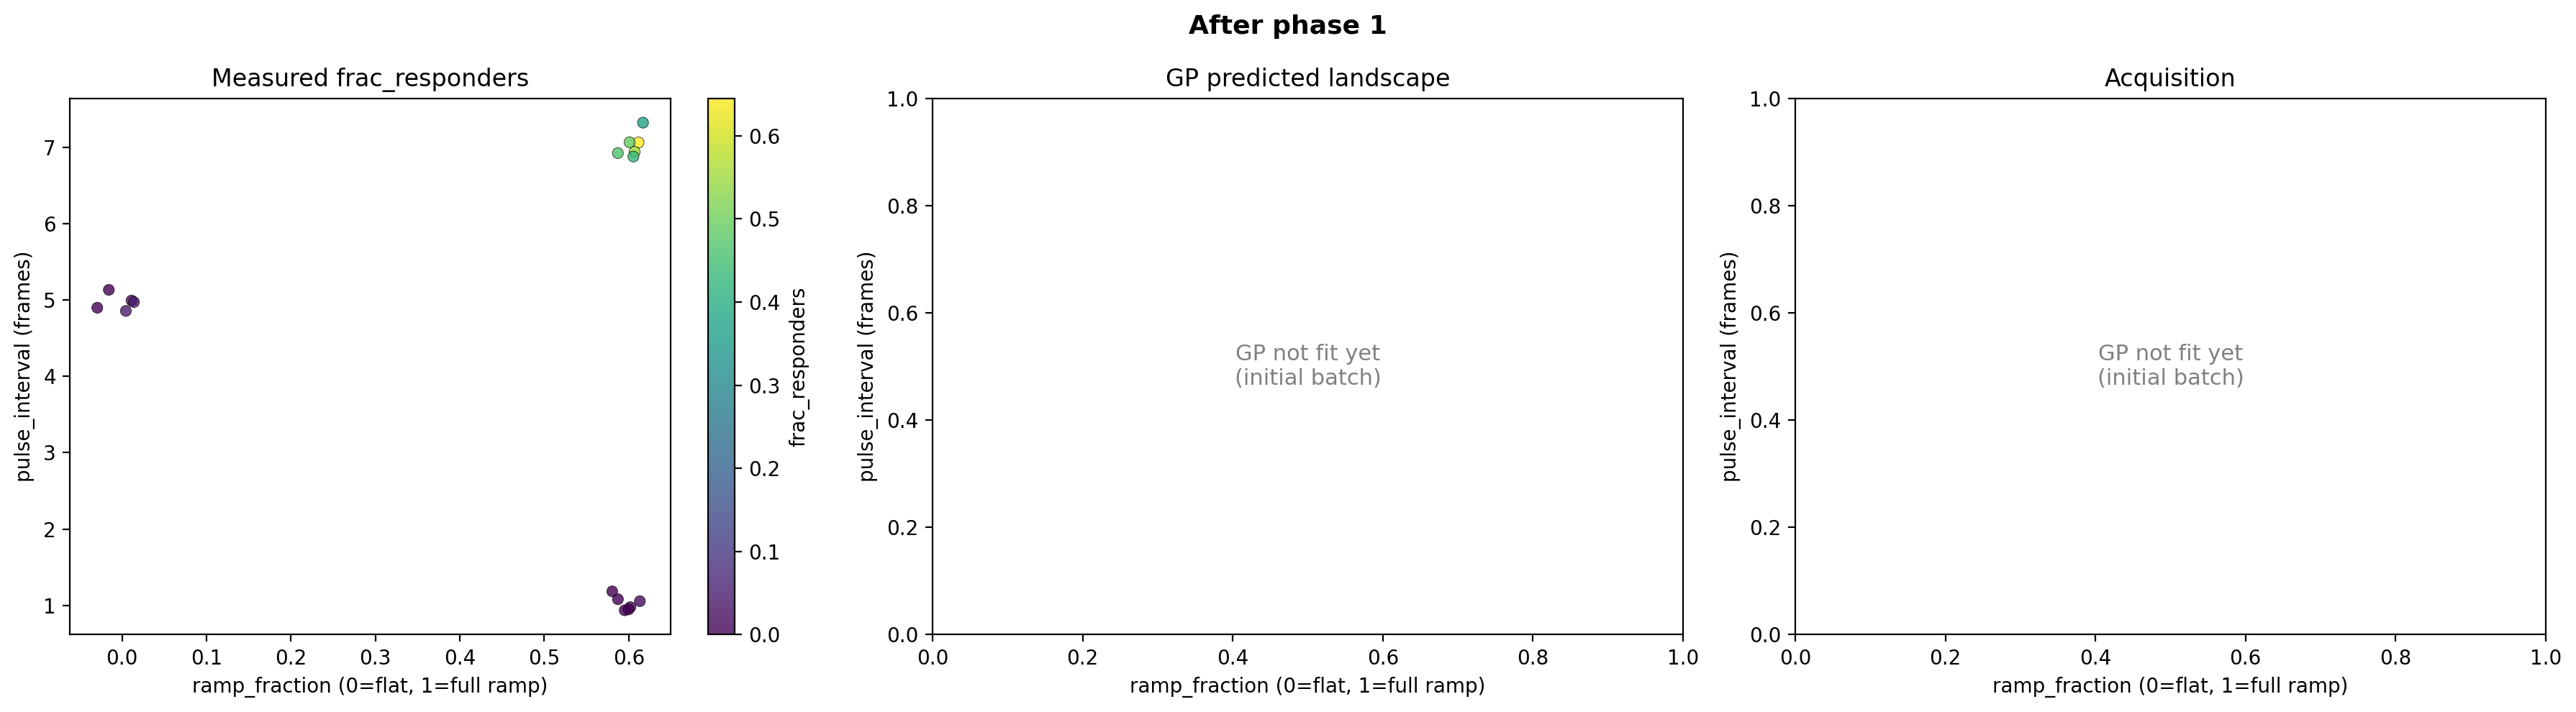


=== ComposedAgent: phase 2/13 ===
[FOVFinderAgent] Phase 1 — selected FOVs:
    A8_0000: 44 cells  cnr(mean=0.776, 91% below 1)
    A8_0001: 45 cells  cnr(mean=0.756, 89% below 1)
    A8_0002: 50 cells  cnr(mean=0.796, 90% below 1)
    A9_0000: 36 cells  cnr(mean=0.818, 86% below 1)
    A9_0001: 44 cells  cnr(mean=0.813, 86% below 1)
    A9_0002: 130 cells  cnr(mean=0.689, 83% below 1)
    A10_0000: 39 cells  cnr(mean=0.784, 81% below 1)
    A10_0001: 77 cells  cnr(mean=0.781, 81% below 1)
    A10_0002: 29 cells (below min_cells)
    A11_0000: 39 cells  cnr(mean=0.877, 77% below 1)
    A11_0001: 103 cells  cnr(mean=0.789, 77% below 1)
    A11_0002: 128 cells  cnr(mean=0.803, 81% below 1)
    A12_0000: 61 cells  cnr(mean=0.784, 83% below 1)
    A12_0001: 31 cells (below min_cells)
    A12_0002: 29 cells (below min_cells)
    B12_0000: 139 cells  cnr(mean=0.770, 83% below 1)
    B12_0001: 157 cells  cnr(mean=0.694, 85% below 1)
    B12_0002: 29 cells (below min_cells)
=== Phase 1: initi

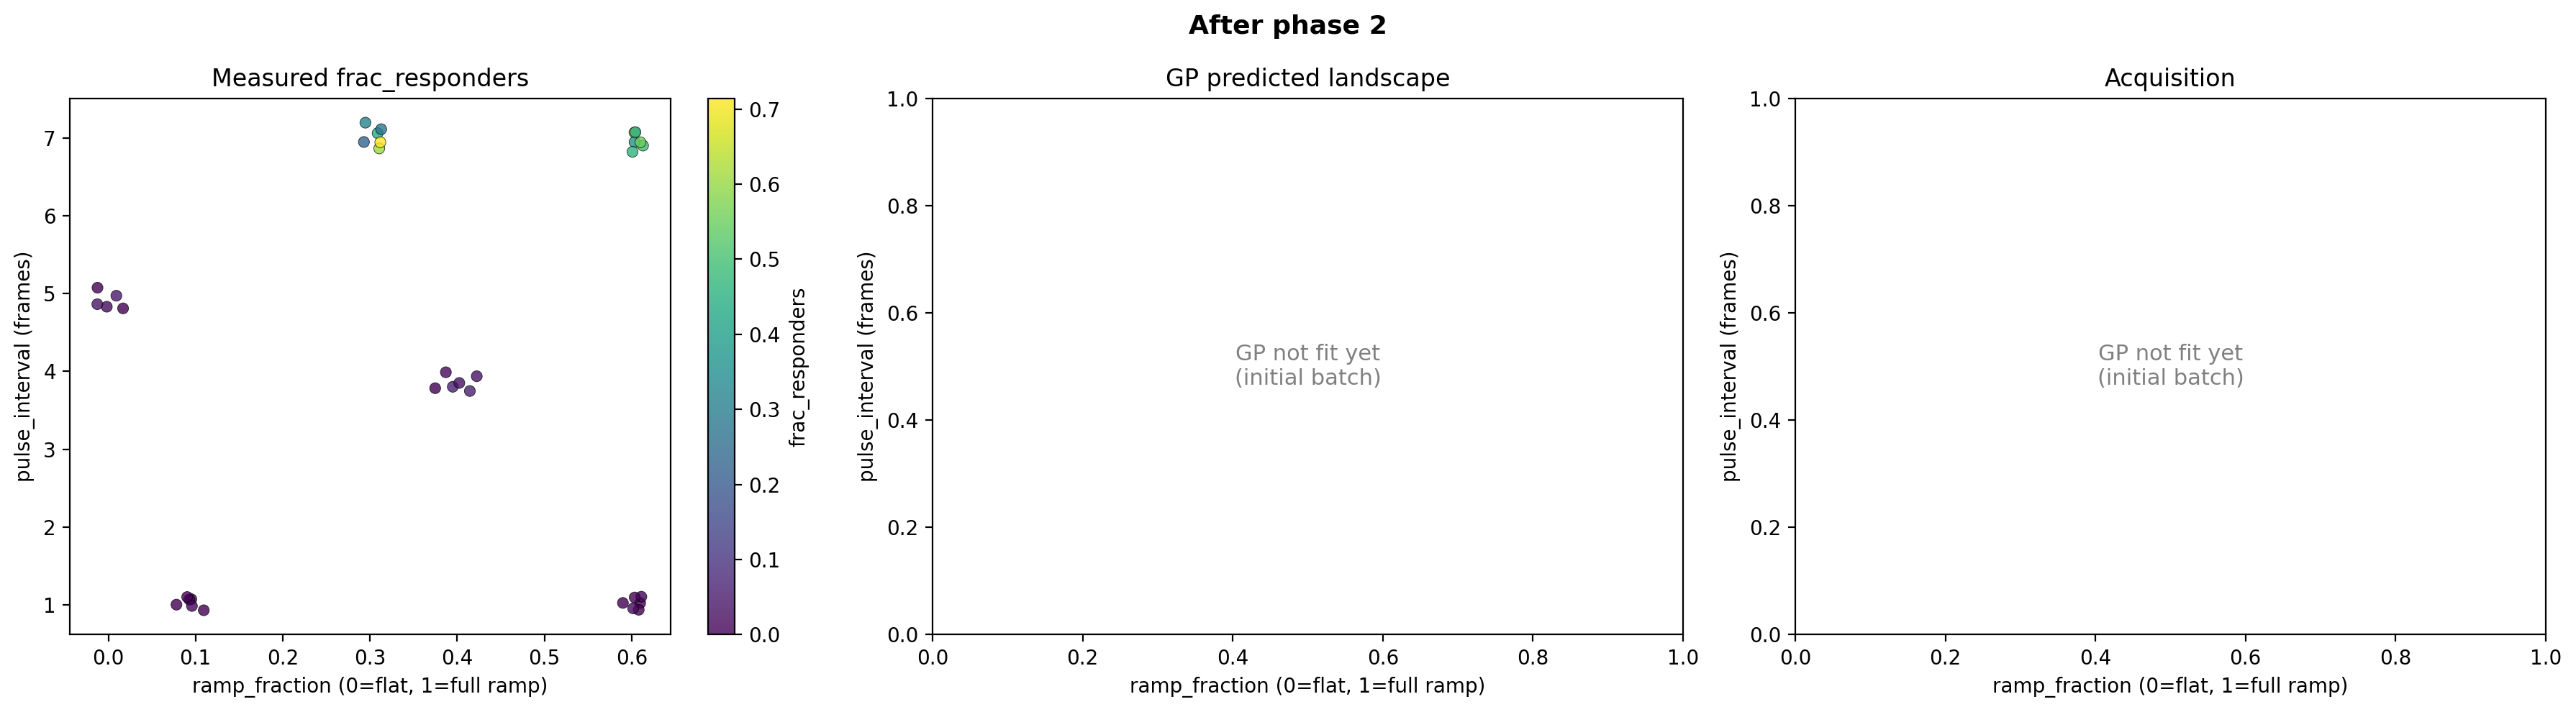


=== ComposedAgent: phase 3/13 ===
[FOVFinderAgent] Phase 2 — selected FOVs:
    B11_0000: 36 cells  cnr(mean=0.827, 78% below 1)
    B11_0001: 147 cells  cnr(mean=0.583, 94% below 1)
    B11_0002: 159 cells  cnr(mean=0.679, 88% below 1)
    B10_0000: 37 cells  cnr(mean=0.821, 81% below 1)
    B10_0001: 49 cells  cnr(mean=0.842, 77% below 1)
    B10_0002: 91 cells  cnr(mean=0.719, 87% below 1)
    B9_0000: 35 cells  cnr(mean=0.845, 77% below 1)
    B9_0001: 56 cells  cnr(mean=0.777, 76% below 1)
    B9_0002: 97 cells  cnr(mean=0.762, 83% below 1)
    B8_0000: 124 cells  cnr(mean=0.740, 87% below 1)
    B8_0001: 168 cells  cnr(mean=0.598, 95% below 1)
    B8_0002: 36 cells  cnr(mean=0.837, 71% below 1) (below min_cells)
    B7_0000: 36 cells  cnr(mean=0.805, 89% below 1)
    B7_0001: 49 cells  cnr(mean=0.718, 85% below 1)
    B7_0002: 124 cells  cnr(mean=0.648, 93% below 1)
    B6_0000: 35 cells  cnr(mean=0.732, 83% below 1)
    B6_0001: 105 cells  cnr(mean=0.728, 89% below 1)
    B6_00

sample: 100%|##########| 1200/1200 [00:03<00:00, 326.42it/s, 7 steps of size 4.68e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.76      2.70      2.06      0.42      5.42    756.42      1.00
k_length[1]      0.44      0.24      0.40      0.08      0.77    780.59      1.00
k_length[2]      4.92      3.26      4.26      0.83      8.47    828.22      1.00
k_length[3]      8.47      7.36      6.84      1.37     15.19    415.87      1.00
k_length[4]      2.63      2.13      2.00      0.86      4.50    429.80      1.00
    k_scale      0.82      0.43      0.71      0.31      1.34    670.74      1.00
      noise      0.08      0.04      0.07      0.02      0.14    827.76      1.00

Computing robust acquisition over 1664 scenarios (104 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 1.365138
  Robust acq stats: min=0.000003, max=0.213148
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 103 grid points x 16 covariate samples
  bes

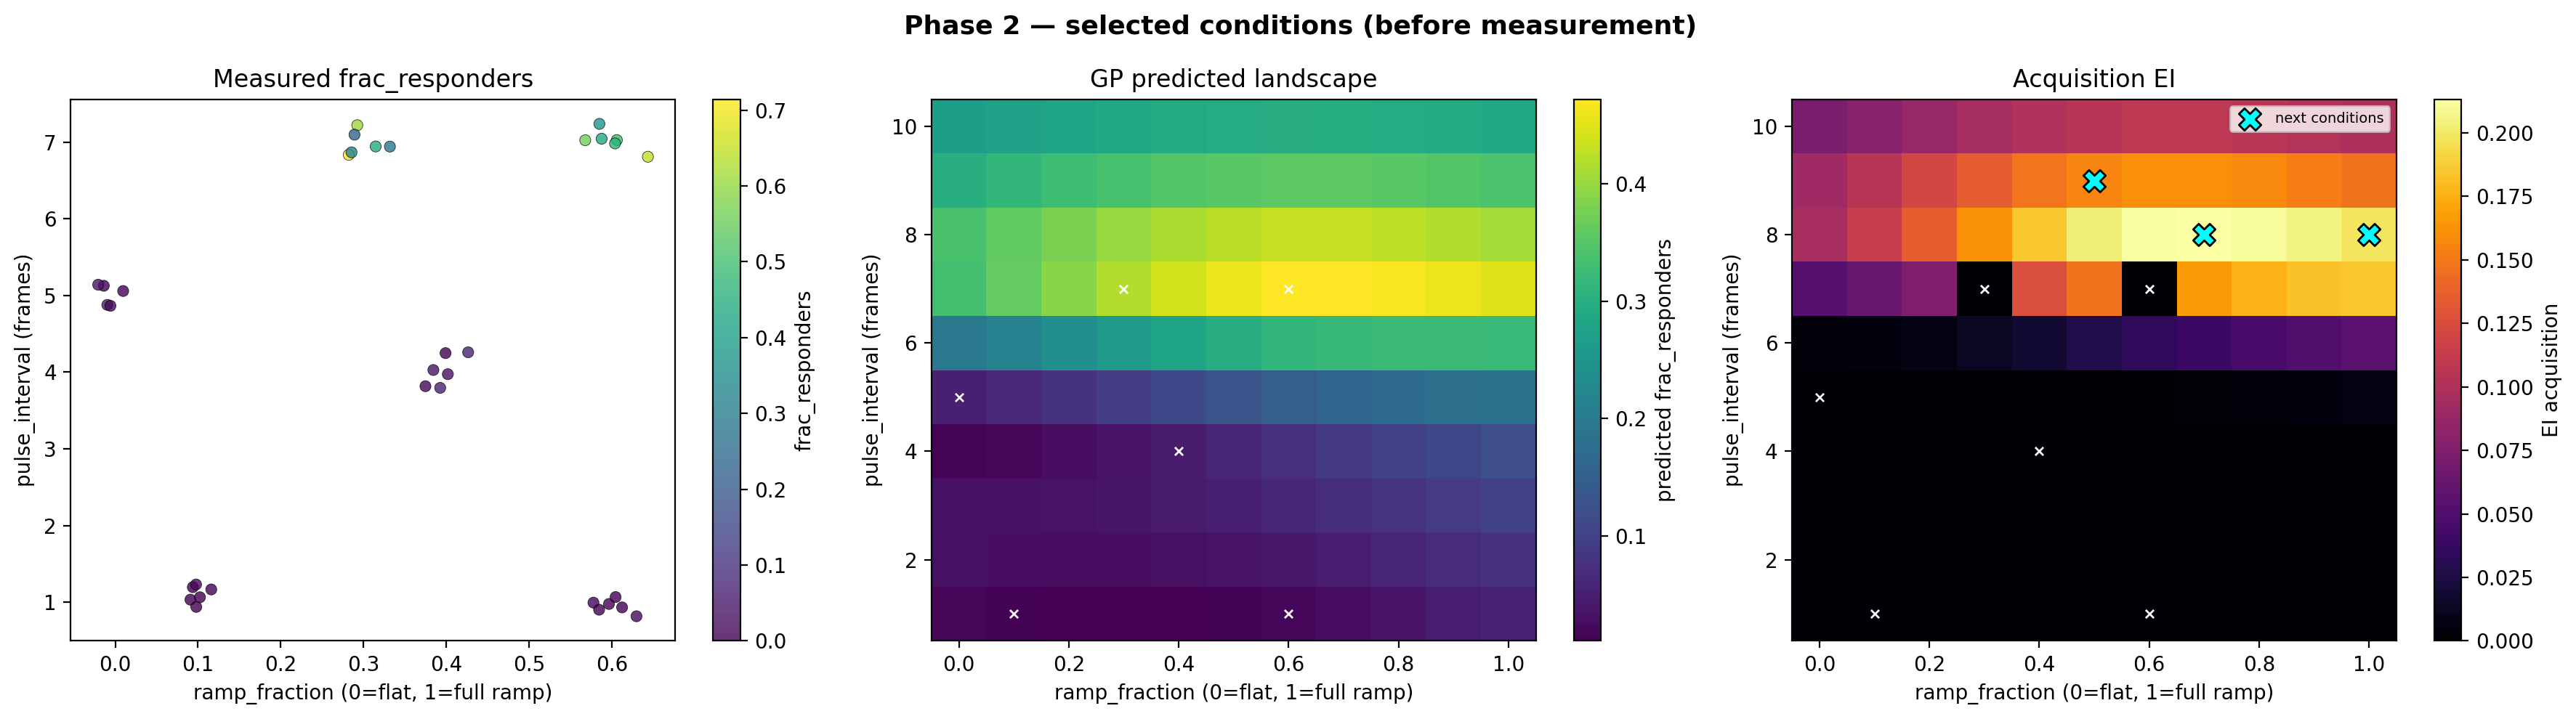

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.70, pulse_interval=8: n_pulses=8 -> base=375.0ms, ramp=250.00ms/pulse, peak=2125.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=1.00, pulse_interval=8: n_pulses=8 -> base=0.0ms, ramp=357.14ms/pulse, peak=2500.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.50, pulse_interval=9: n_pulses=7 -> base=714.3ms, ramp=238.10ms/pulse, peak=2142.9ms
  Cond 1: dropped 1/8 sub-25ms pulses (min computed exposure was 0.000 ms)
  Created 1620 events for phase 2
    Cond 0 (FOVs 36-41): stim_exposure=375ms, ramp=250ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 2125ms)
    Cond 1 (FOVs 42-47): stim_exposure=0ms, ramp=357ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 2500ms)
    Cond 2 (FOVs 48-53): stim_exposure=714ms, ramp=238ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2143ms)
  Recovered optoRTK for FOV 53 after 1.0 s re-read (147 cells, mean=1193.204)
  Ph

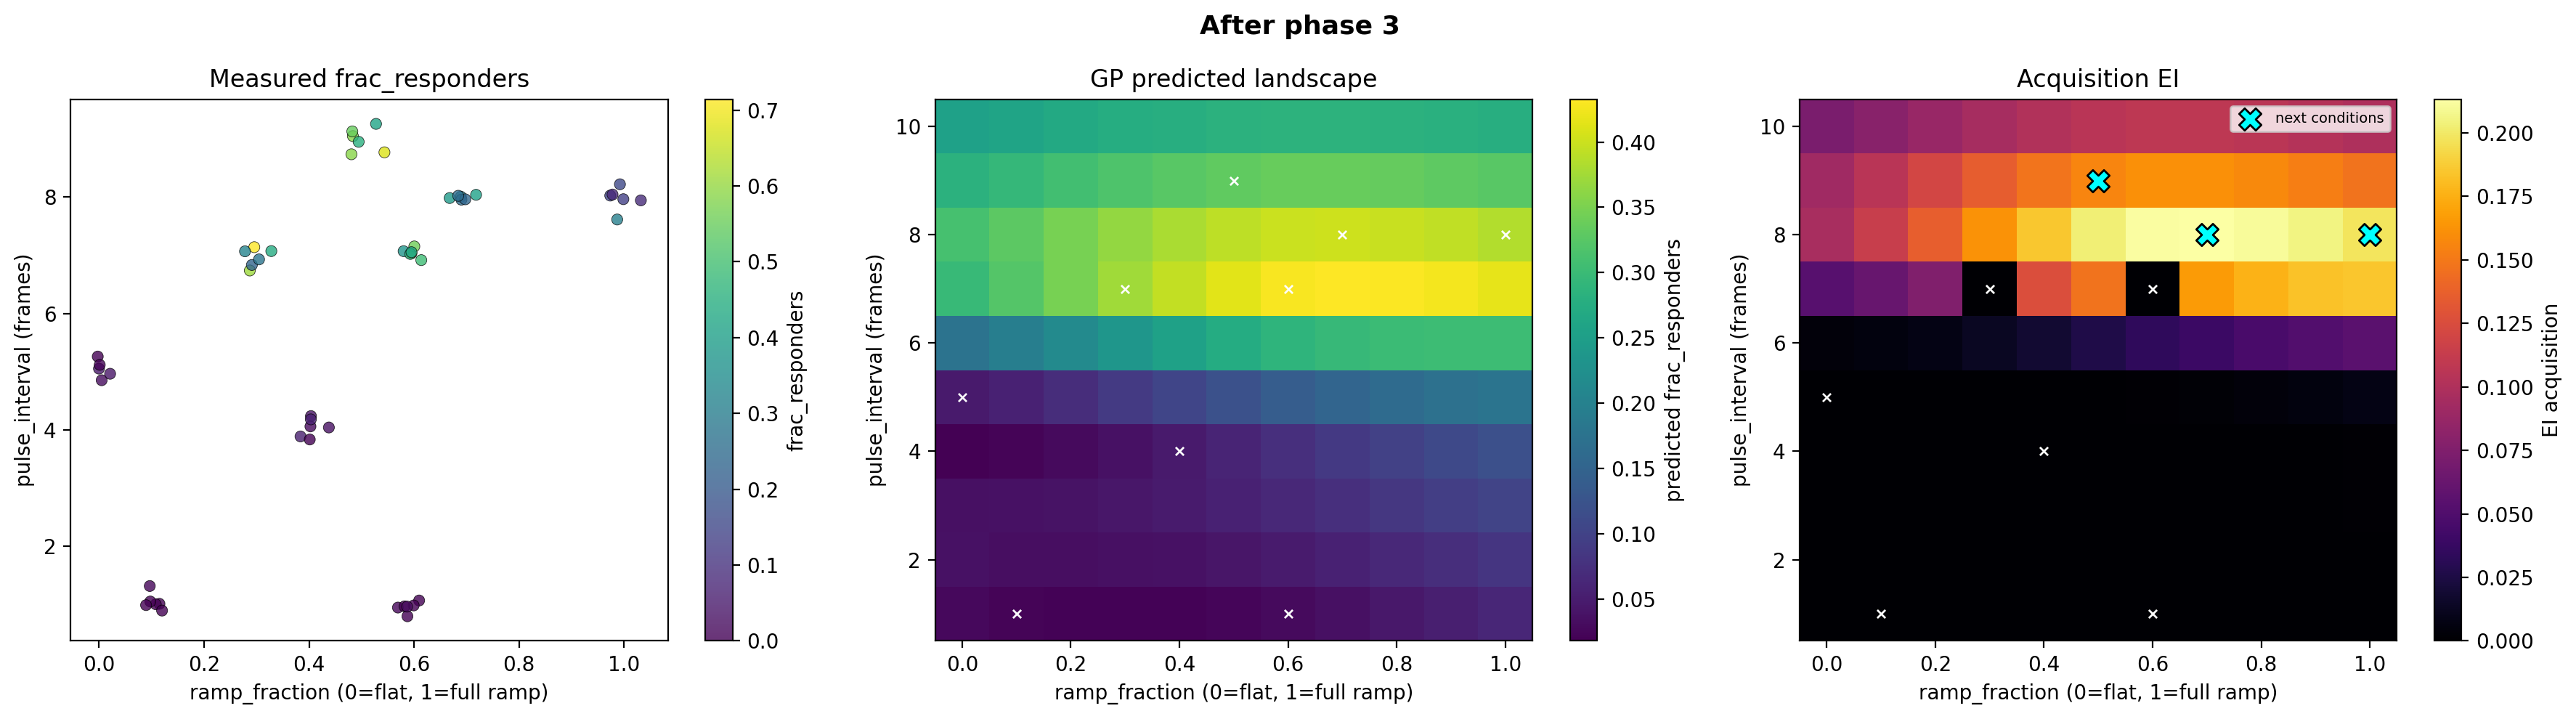


=== ComposedAgent: phase 4/13 ===
[FOVFinderAgent] Phase 3 — selected FOVs:
    B5_0000: 45 cells  cnr(mean=0.812, 84% below 1)
    B5_0001: 49 cells  cnr(mean=0.838, 75% below 1)
    B5_0002: 79 cells  cnr(mean=0.785, 87% below 1)
    B4_0000: 42 cells  cnr(mean=0.807, 86% below 1)
    B4_0001: 137 cells  cnr(mean=0.748, 84% below 1)
    B4_0002: 200 cells  cnr(mean=0.659, 91% below 1)
    B3_0000: 47 cells  cnr(mean=0.846, 76% below 1)
    B3_0001: 110 cells  cnr(mean=0.761, 85% below 1)
    B3_0002: 92 cells  cnr(mean=0.859, 74% below 1) (below min_cells)
    B2_0000: 44 cells  cnr(mean=0.928, 77% below 1)
    B2_0001: 68 cells  cnr(mean=0.873, 66% below 1) (below min_cells)
    B2_0002: 53 cells  cnr(mean=0.933, 59% below 1) (below min_cells)
    C2_0000: 93 cells  cnr(mean=0.751, 81% below 1)
    C2_0001: 126 cells  cnr(mean=0.815, 78% below 1)
    C2_0002: 58 cells  cnr(mean=0.883, 73% below 1) (below min_cells)
    C3_0000: 40 cells  cnr(mean=0.827, 75% below 1)
    C3_0001: 69

sample: 100%|##########| 1200/1200 [00:04<00:00, 260.94it/s, 15 steps of size 4.03e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.94      0.80      0.75      0.22      1.74    359.19      1.00
k_length[1]      0.48      0.25      0.45      0.14      0.86    400.85      1.00
k_length[2]      5.50      3.11      4.77      2.08      9.47    556.14      1.00
k_length[3]      9.69      6.56      8.07      2.47     16.86    530.30      1.00
k_length[4]      4.10      3.83      2.86      0.93      7.80    332.68      1.00
    k_scale      0.80      0.33      0.74      0.34      1.25    598.95      1.00
      noise      0.10      0.04      0.09      0.04      0.16    533.39      1.00

Computing robust acquisition over 1616 scenarios (101 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 1.397811
  Robust acq stats: min=0.000000, max=0.182598
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 100 grid points x 16 covariate samples
  bes

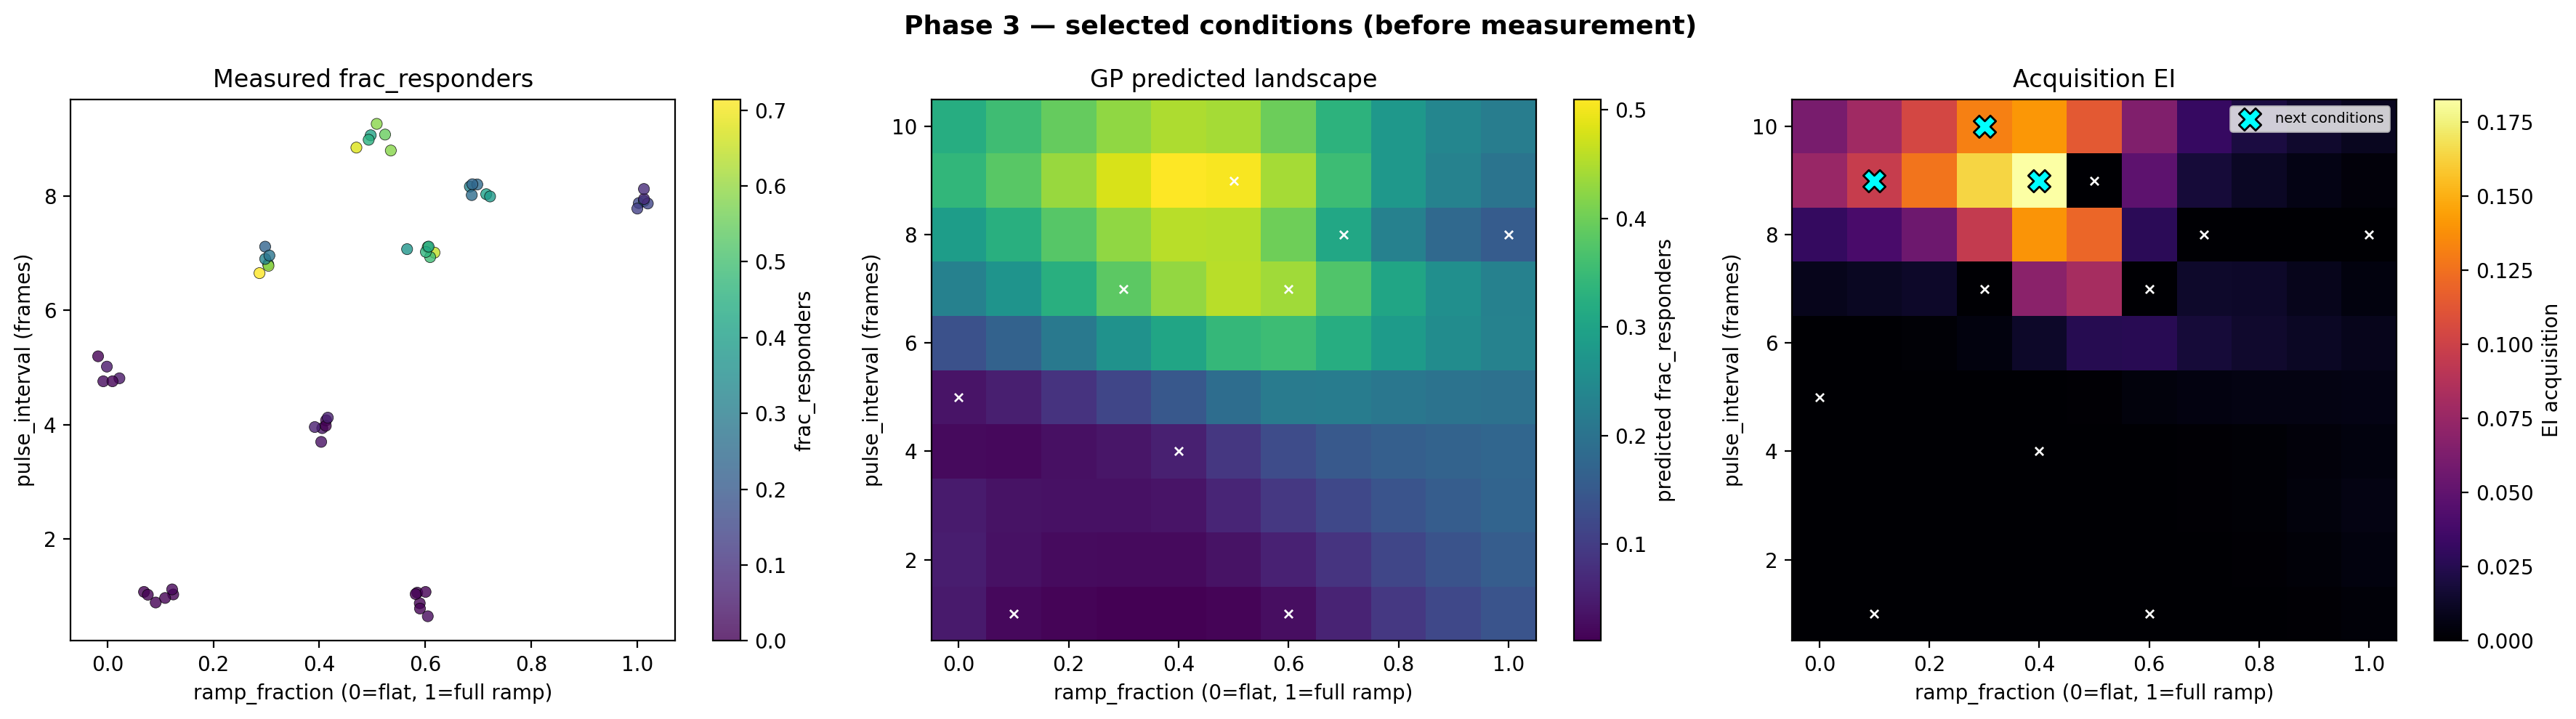

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.40, pulse_interval=9: n_pulses=7 -> base=857.1ms, ramp=190.48ms/pulse, peak=2000.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.10, pulse_interval=9: n_pulses=7 -> base=1285.7ms, ramp=47.62ms/pulse, peak=1571.4ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.30, pulse_interval=10: n_pulses=6 -> base=1166.7ms, ramp=200.00ms/pulse, peak=2166.7ms
  Created 1620 events for phase 3
    Cond 0 (FOVs 54-59): stim_exposure=857ms, ramp=190ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2000ms)
    Cond 1 (FOVs 60-65): stim_exposure=1286ms, ramp=48ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 1571ms)
    Cond 2 (FOVs 66-71): stim_exposure=1167ms, ramp=200ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 2167ms)
  Recovered optoRTK for FOV 71 after 1.0 s re-read (106 cells, mean=1177.969)
  Phase 3: 18 FOVs, mean frac_oscillating=0.9992, max=1.0000
  optoRTK 

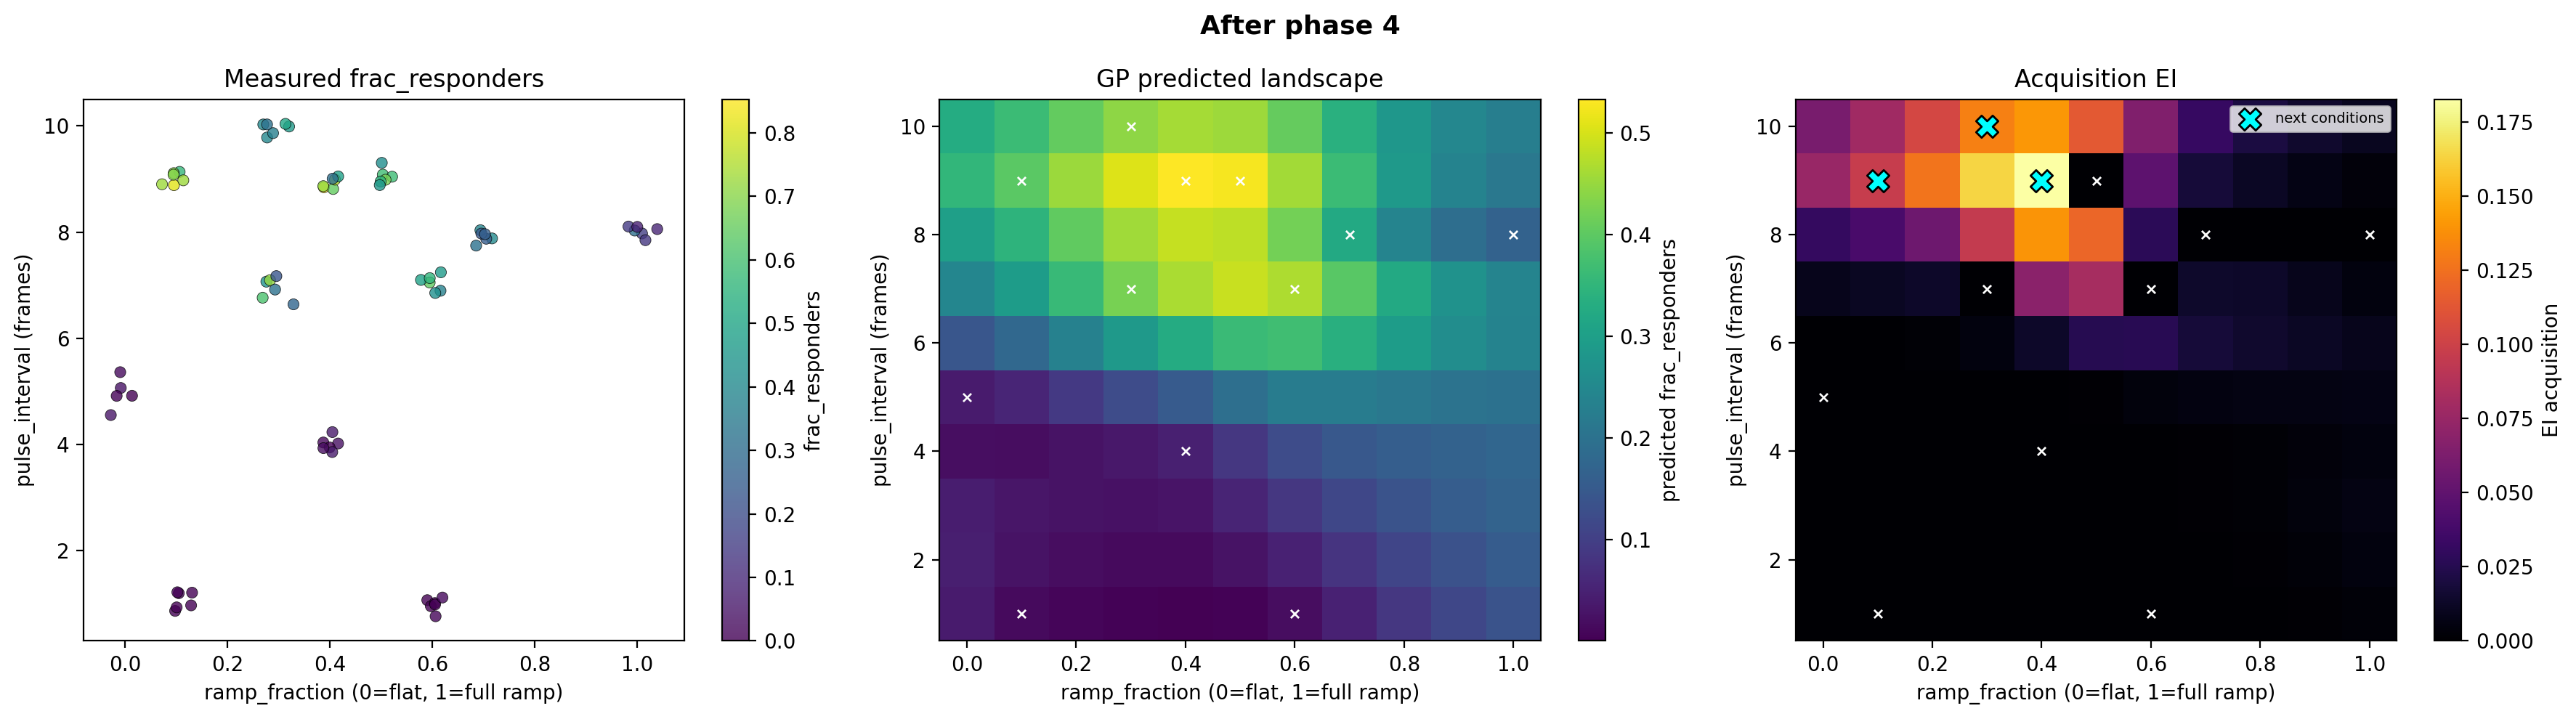


=== ComposedAgent: phase 5/13 ===
[FOVFinderAgent] Phase 4 — selected FOVs:
    C4_0000: 36 cells  cnr(mean=0.824, 75% below 1)
    C4_0001: 59 cells  cnr(mean=0.826, 81% below 1)
    C4_0002: 141 cells  cnr(mean=0.733, 89% below 1)
    C5_0000: 44 cells  cnr(mean=0.796, 75% below 1)
    C5_0001: 57 cells  cnr(mean=0.849, 84% below 1)
    C5_0002: 127 cells  cnr(mean=0.811, 84% below 1)
    C6_0000: 38 cells  cnr(mean=0.818, 83% below 1)
    C6_0001: 64 cells  cnr(mean=0.818, 83% below 1)
    C6_0002: 153 cells  cnr(mean=0.657, 93% below 1)
    C7_0000: 39 cells  cnr(mean=0.818, 77% below 1)
    C7_0001: 154 cells  cnr(mean=0.700, 90% below 1)
    C7_0002: 155 cells  cnr(mean=0.777, 81% below 1)
    C8_0000: 40 cells  cnr(mean=0.759, 82% below 1)
    C8_0001: 62 cells  cnr(mean=0.786, 85% below 1)
    C8_0002: 127 cells  cnr(mean=0.689, 93% below 1)
    C9_0000: 70 cells  cnr(mean=0.750, 83% below 1)
    C9_0001: 86 cells  cnr(mean=0.866, 73% below 1) (below min_cells)
    C9_0002: 28

sample: 100%|##########| 1200/1200 [00:05<00:00, 216.10it/s, 7 steps of size 4.22e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.42      0.85      1.21      0.36      2.30    618.14      1.00
k_length[1]      0.29      0.12      0.27      0.11      0.45    521.43      1.01
k_length[2]      5.40      2.23      4.93      2.47      8.75    700.01      1.00
k_length[3]     11.58      7.02      9.99      3.48     19.86    474.25      1.00
k_length[4]      5.31      4.17      3.94      1.44     10.38    371.63      1.01
    k_scale      0.78      0.31      0.71      0.37      1.21    591.48      1.00
      noise      0.07      0.02      0.07      0.03      0.09    460.30      1.01

Computing robust acquisition over 1568 scenarios (98 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 1.297533
  Robust acq stats: min=0.000000, max=0.156016
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 97 grid points x 16 covariate samples
  best_

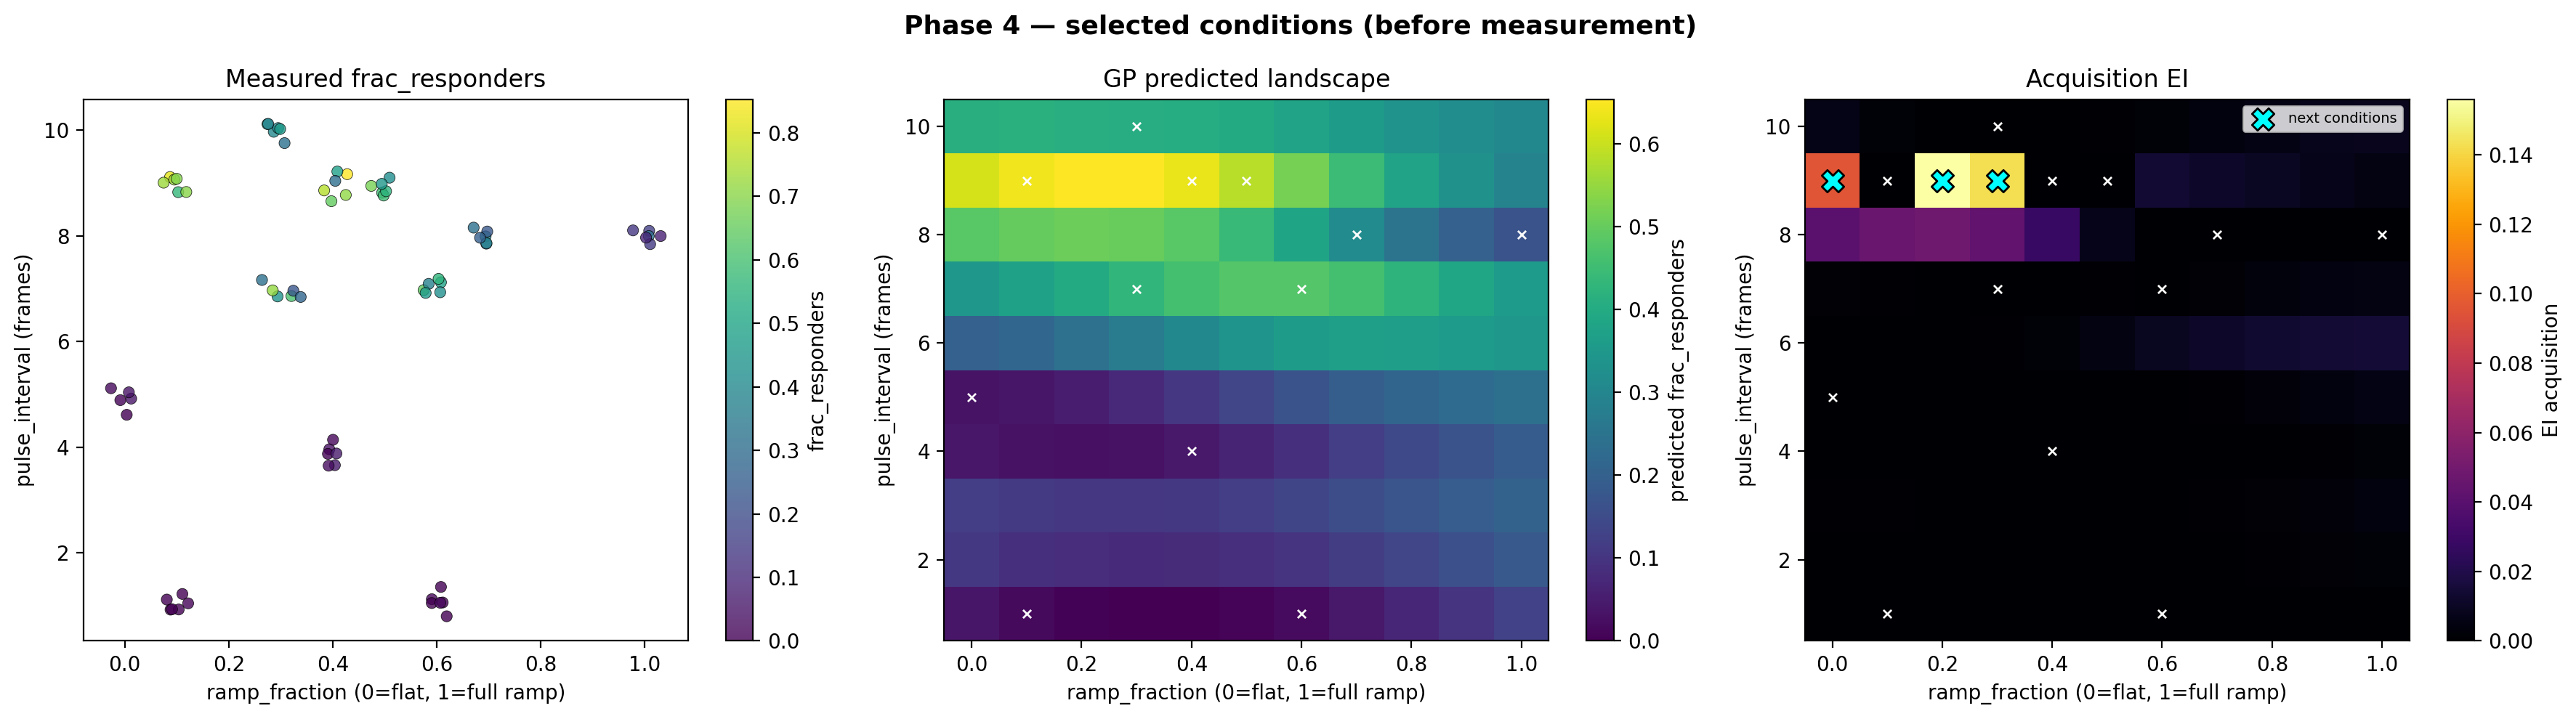

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.20, pulse_interval=9: n_pulses=7 -> base=1142.9ms, ramp=95.24ms/pulse, peak=1714.3ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.30, pulse_interval=9: n_pulses=7 -> base=1000.0ms, ramp=142.86ms/pulse, peak=1857.1ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.00, pulse_interval=9: n_pulses=7 -> base=1428.6ms, ramp=0.00ms/pulse, peak=1428.6ms
  Created 1620 events for phase 4
    Cond 0 (FOVs 72-77): stim_exposure=1143ms, ramp=95ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 1714ms)
    Cond 1 (FOVs 78-83): stim_exposure=1000ms, ramp=143ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 1857ms)
    Cond 2 (FOVs 84-89): stim_exposure=1429ms, ramp=0ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 1429ms)
  Recovered optoRTK for FOV 89 after 1.0 s re-read (25 cells, mean=1512.846)
  Phase 4: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  optoRTK re-re

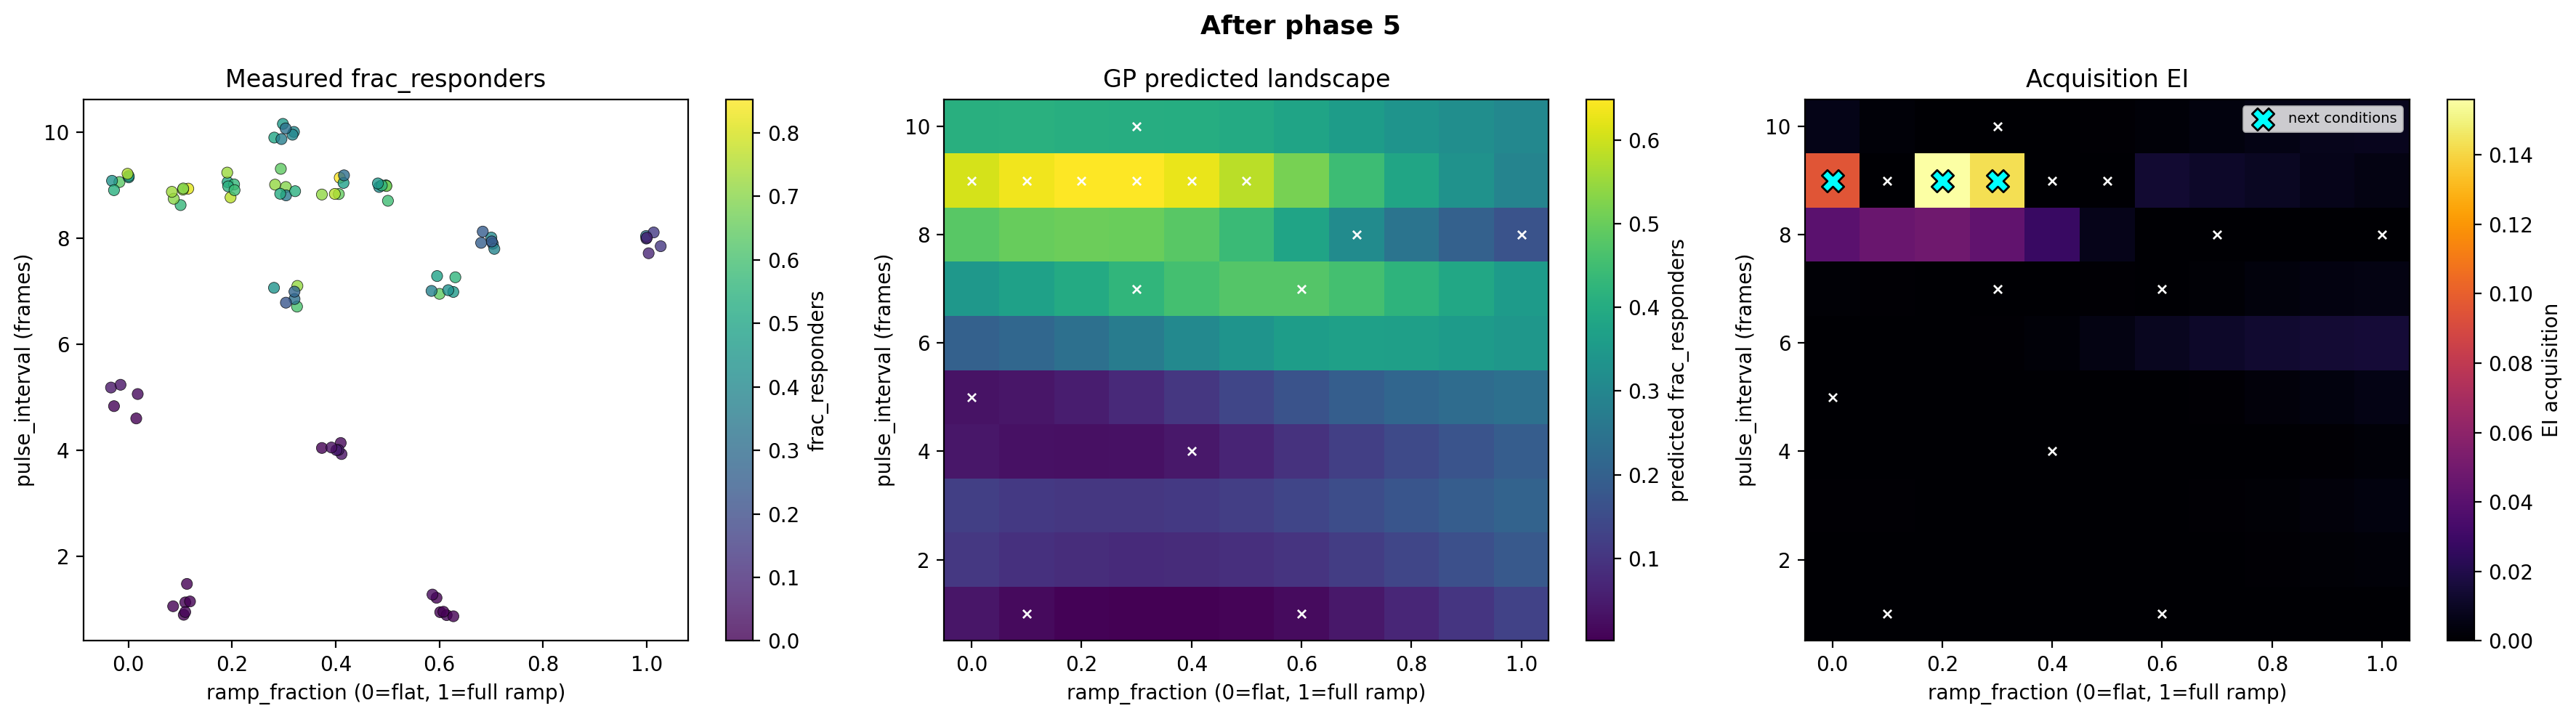


=== ComposedAgent: phase 6/13 ===
[FOVFinderAgent] Phase 5 — selected FOVs:
    C10_0000: 45 cells  cnr(mean=0.832, 84% below 1)
    C10_0001: 45 cells  cnr(mean=0.926, 73% below 1) (below min_cells)
    C10_0002: 42 cells  cnr(mean=0.879, 71% below 1) (below min_cells)
    C11_0000: 125 cells  cnr(mean=0.721, 88% below 1)
    C11_0001: 143 cells  cnr(mean=0.713, 89% below 1)
    C11_0002: 33 cells (below min_cells)
    C12_0000: 39 cells  cnr(mean=0.814, 77% below 1)
    C12_0001: 62 cells  cnr(mean=0.796, 87% below 1)
    C12_0002: 89 cells  cnr(mean=0.735, 89% below 1)
    D12_0000: 42 cells  cnr(mean=0.861, 67% below 1) (below min_cells)
    D12_0001: 35 cells  cnr(mean=0.939, 66% below 1) (below min_cells)
    D12_0002: 34 cells (below min_cells)
    D11_0000: 36 cells  cnr(mean=0.848, 80% below 1)
    D11_0001: 38 cells  cnr(mean=0.825, 87% below 1)
    D11_0002: 57 cells  cnr(mean=0.806, 79% below 1)
    D10_0000: 39 cells  cnr(mean=0.837, 79% below 1)
    D10_0001: 47 cells  c

sample: 100%|##########| 1200/1200 [00:06<00:00, 195.39it/s, 7 steps of size 4.49e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.63      0.87      1.44      0.60      2.49    498.33      1.00
k_length[1]      0.28      0.12      0.26      0.10      0.46    773.86      1.00
k_length[2]      6.79      2.85      6.19      3.01     10.85    665.06      1.00
k_length[3]      9.59      4.08      8.76      3.46     14.99    697.41      1.00
k_length[4]      7.36      4.78      6.13      2.00     12.64    679.76      1.00
    k_scale      0.84      0.34      0.75      0.39      1.30    623.03      1.00
      noise      0.08      0.02      0.08      0.06      0.11    866.13      1.00

Computing robust acquisition over 1520 scenarios (95 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.771715
  Robust acq stats: min=0.000000, max=0.135068
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 94 grid points x 16 covariate samples
  best_

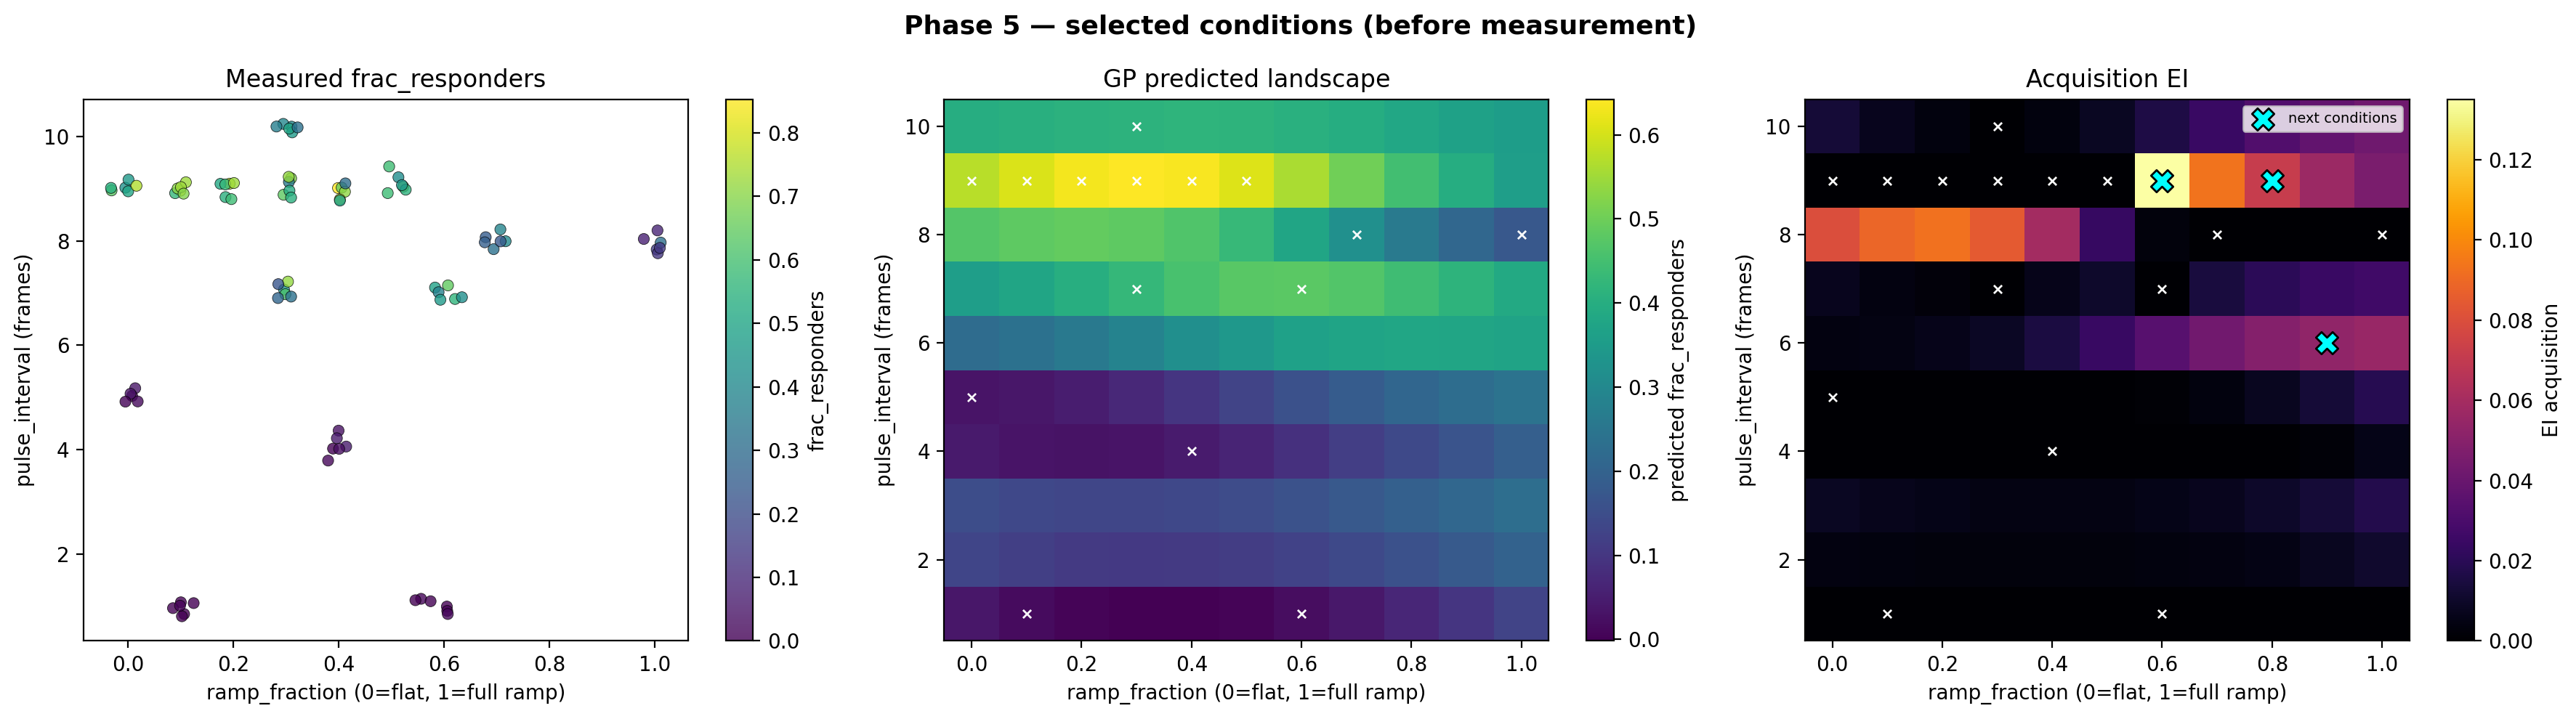

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.60, pulse_interval=9: n_pulses=7 -> base=571.4ms, ramp=285.71ms/pulse, peak=2285.7ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.90, pulse_interval=6: n_pulses=10 -> base=100.0ms, ramp=200.00ms/pulse, peak=1900.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.80, pulse_interval=9: n_pulses=7 -> base=285.7ms, ramp=380.95ms/pulse, peak=2571.4ms
  Created 1620 events for phase 5
    Cond 0 (FOVs 90-95): stim_exposure=571ms, ramp=286ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2286ms)
    Cond 1 (FOVs 96-101): stim_exposure=100ms, ramp=200ms/frame, pulse_interval=6min, n_pulses=10 (final exposure: 1900ms)
    Cond 2 (FOVs 102-107): stim_exposure=286ms, ramp=381ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2571ms)
  Recovered optoRTK for FOV 107 after 1.0 s re-read (74 cells, mean=1212.146)
  Phase 5: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  optoRTK

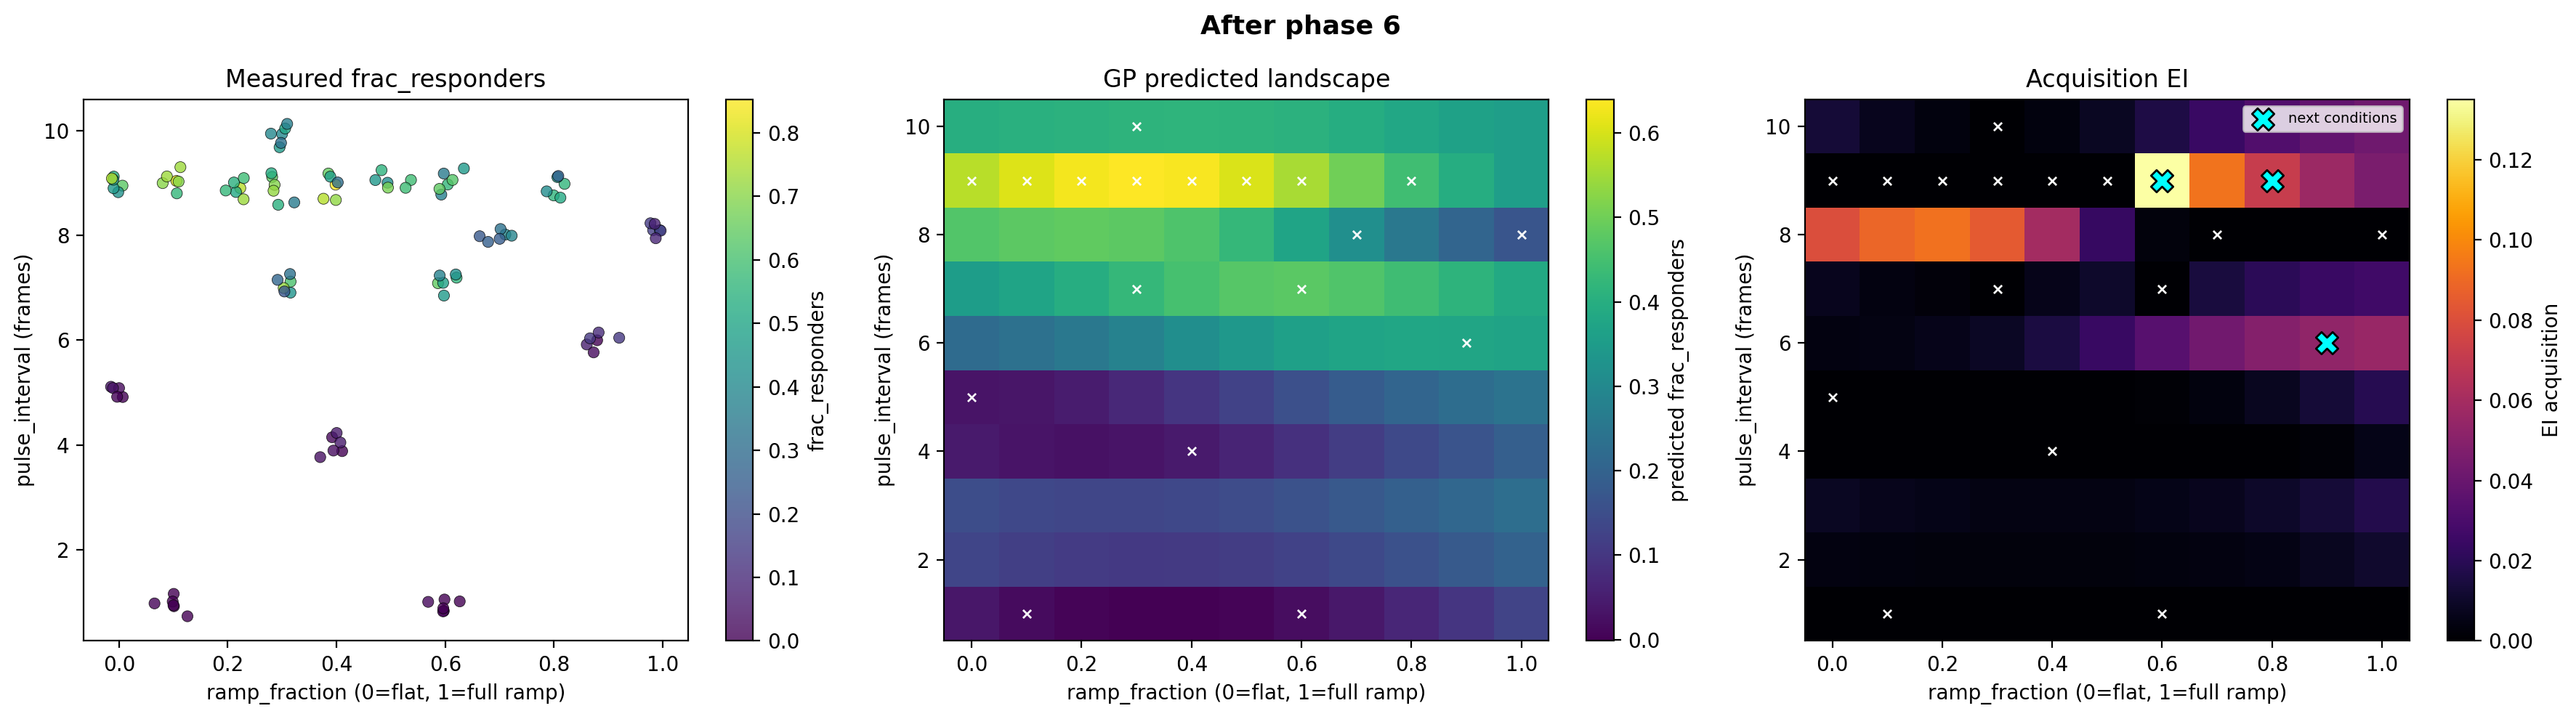


=== ComposedAgent: phase 7/13 ===
[FOVFinderAgent] Phase 6 — selected FOVs:
    D9_0000: 76 cells  cnr(mean=0.819, 67% below 1) (below min_cells)
    D9_0001: 57 cells  cnr(mean=0.953, 55% below 1) (below min_cells)
    D9_0002: 53 cells  cnr(mean=0.908, 64% below 1) (below min_cells)
    D8_0000: 44 cells  cnr(mean=0.807, 77% below 1)
    D8_0001: 70 cells  cnr(mean=0.751, 94% below 1)
    D8_0002: 103 cells  cnr(mean=0.767, 88% below 1)
    D7_0000: 41 cells  cnr(mean=0.860, 76% below 1)
    D7_0001: 72 cells  cnr(mean=0.743, 89% below 1)
    D7_0002: 73 cells  cnr(mean=0.763, 88% below 1)
    D6_0000: 39 cells  cnr(mean=0.834, 79% below 1)
    D6_0001: 76 cells  cnr(mean=0.810, 74% below 1) (below min_cells)
    D6_0002: 69 cells  cnr(mean=0.891, 74% below 1) (below min_cells)
    D5_0000: 49 cells  cnr(mean=0.723, 87% below 1)
    D5_0001: 66 cells  cnr(mean=0.771, 86% below 1)
    D5_0002: 81 cells  cnr(mean=0.840, 82% below 1)
    D4_0000: 41 cells  cnr(mean=0.830, 79% below 1)


sample: 100%|##########| 1200/1200 [00:07<00:00, 169.63it/s, 7 steps of size 4.89e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.46      0.41      1.41      0.81      2.09    734.81      1.00
k_length[1]      0.26      0.09      0.25      0.12      0.40    904.09      1.00
k_length[2]      6.73      2.47      6.21      2.91     10.27    599.12      1.00
k_length[3]     10.03      3.82      9.41      4.33     15.45    881.47      1.00
k_length[4]      9.69      6.35      7.96      2.46     16.45    819.86      1.00
    k_scale      0.92      0.37      0.85      0.41      1.44    579.74      1.00
      noise      0.08      0.01      0.08      0.06      0.11   1024.69      1.00

Computing robust acquisition over 1472 scenarios (92 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.552299
  Robust acq stats: min=0.000000, max=0.204351
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 91 grid points x 16 covariate samples
  best_

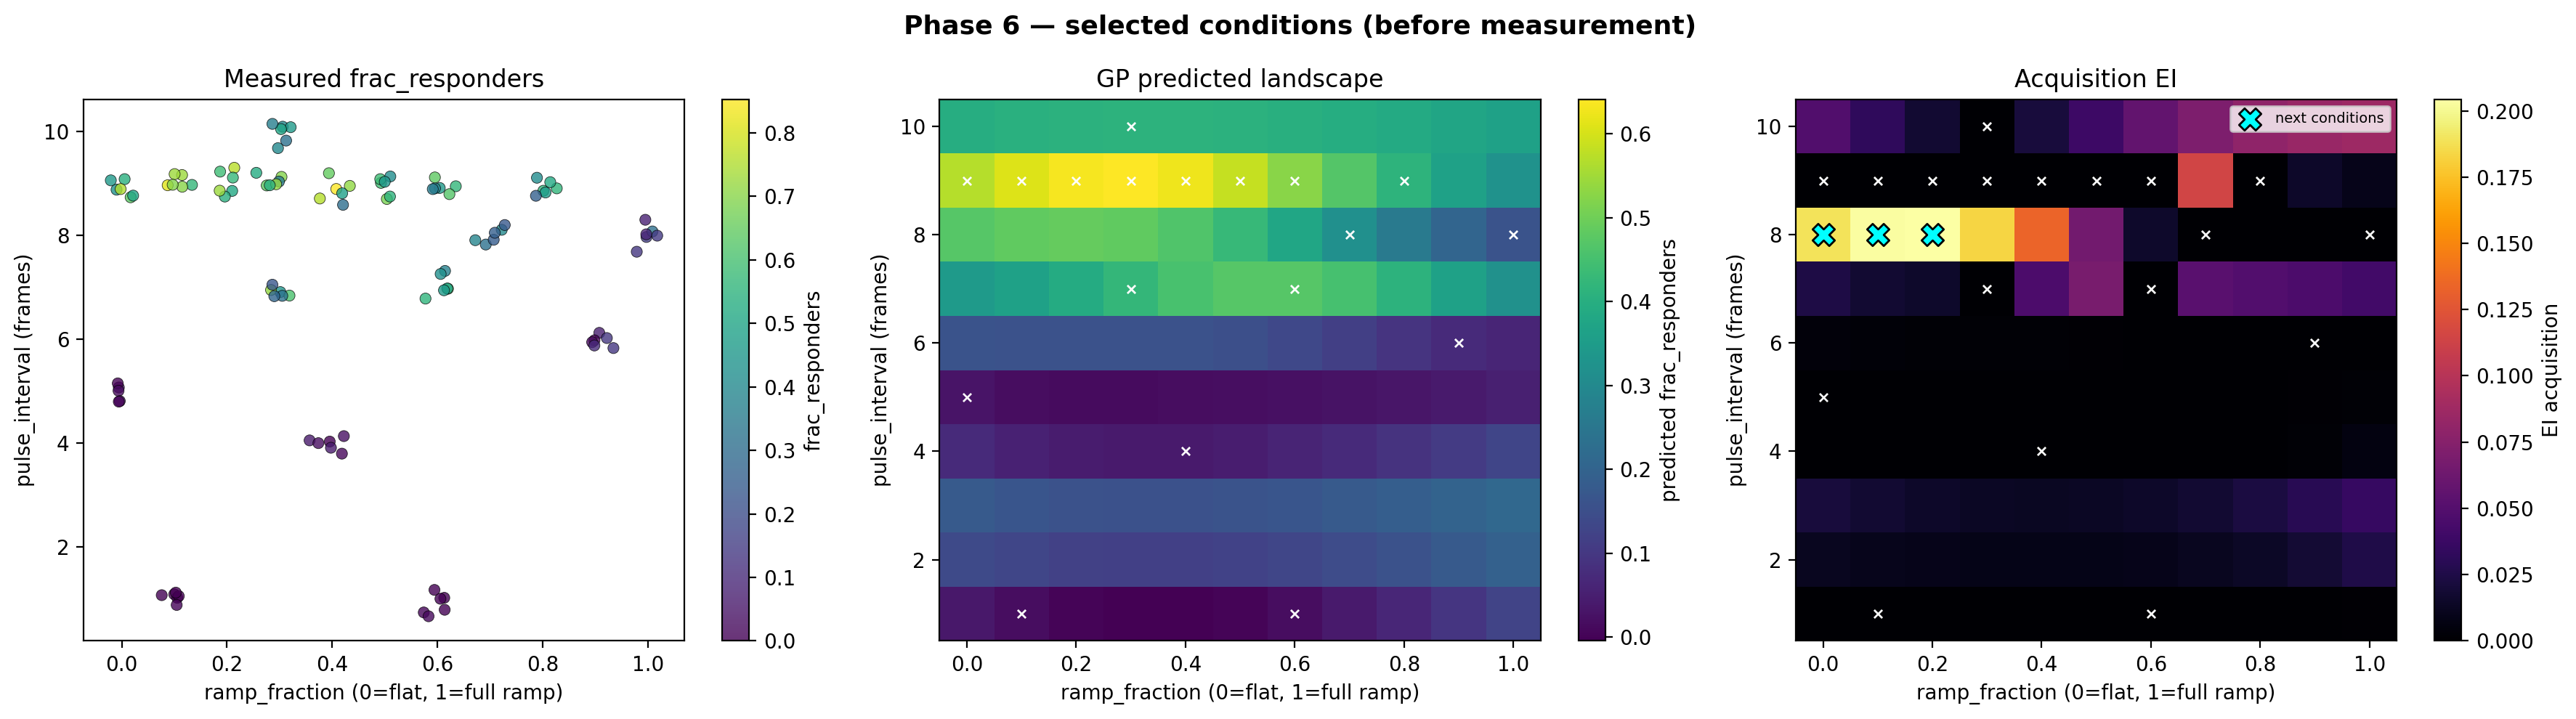

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.20, pulse_interval=8: n_pulses=8 -> base=1000.0ms, ramp=71.43ms/pulse, peak=1500.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.00, pulse_interval=8: n_pulses=8 -> base=1250.0ms, ramp=0.00ms/pulse, peak=1250.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.10, pulse_interval=8: n_pulses=8 -> base=1125.0ms, ramp=35.71ms/pulse, peak=1375.0ms
  Created 1620 events for phase 6
    Cond 0 (FOVs 108-113): stim_exposure=1000ms, ramp=71ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1500ms)
    Cond 1 (FOVs 114-119): stim_exposure=1250ms, ramp=0ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1250ms)
    Cond 2 (FOVs 120-125): stim_exposure=1125ms, ramp=36ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1375ms)
  Recovered optoRTK for FOV 125 after 1.0 s re-read (54 cells, mean=1477.180)
  Phase 6: 18 FOVs, mean frac_oscillating=1.0000, max=1.0000
  optoRTK 

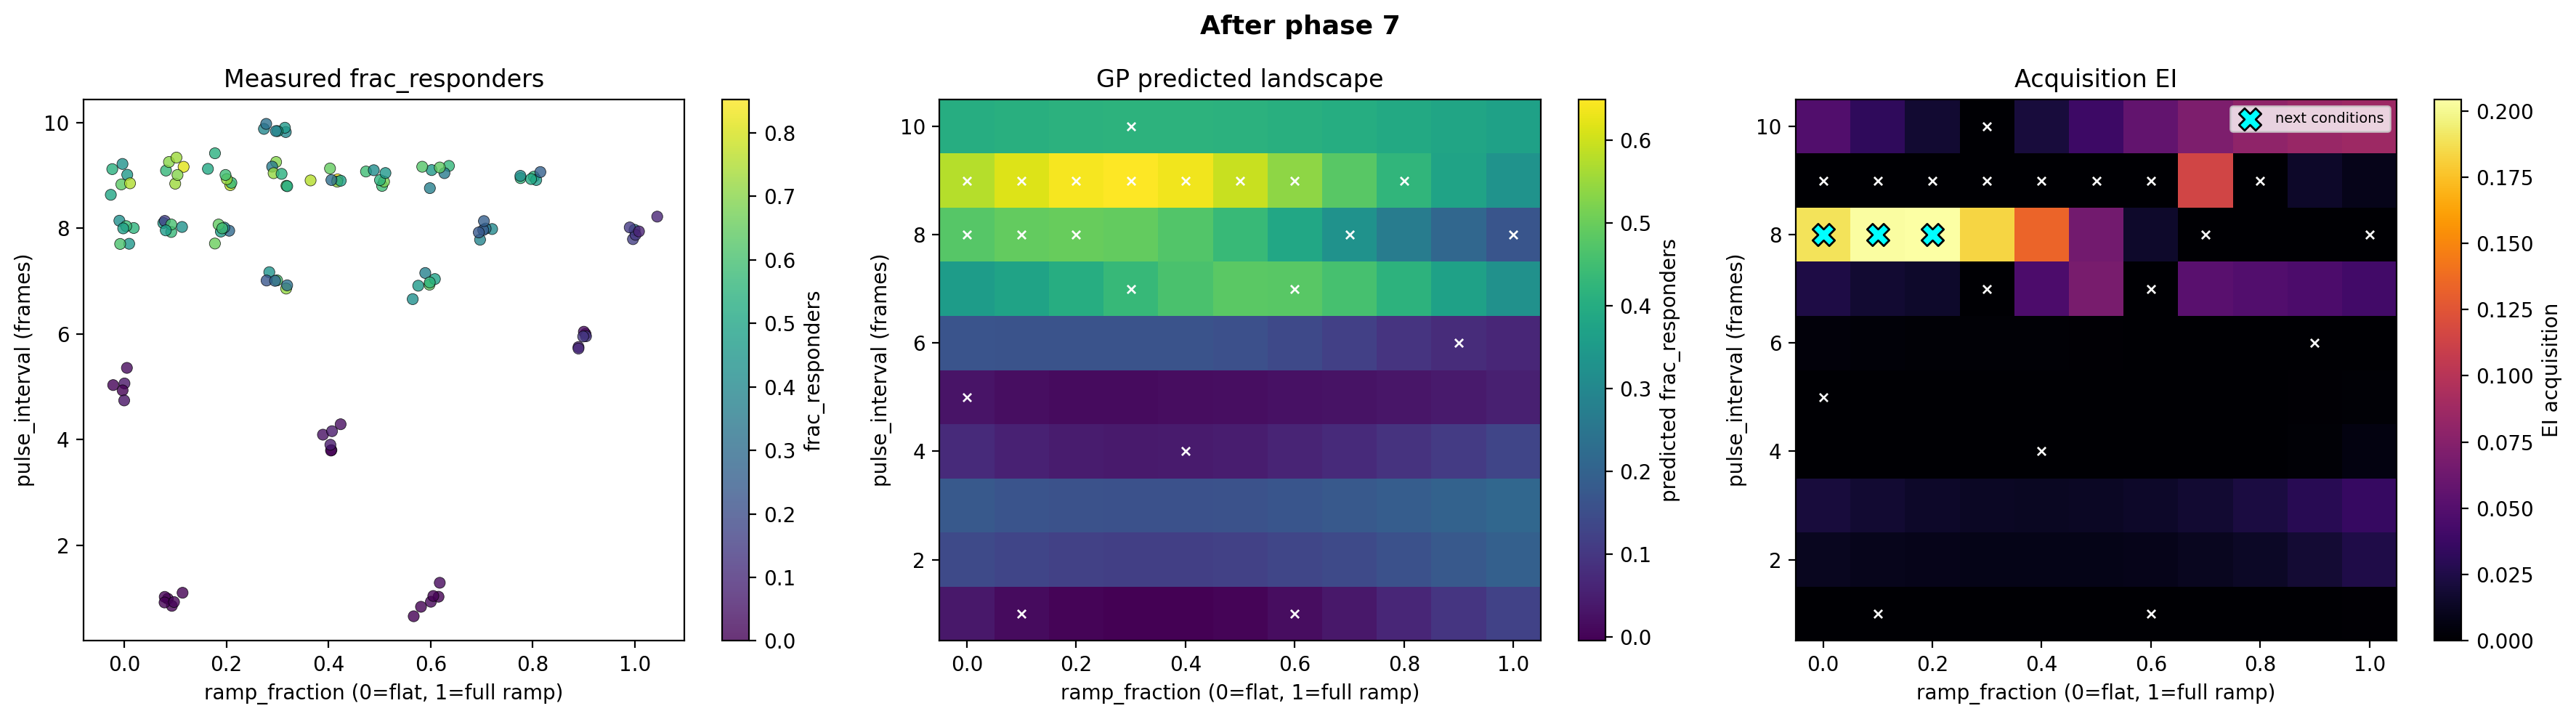


=== ComposedAgent: phase 8/13 ===
[FOVFinderAgent] Phase 7 — selected FOVs:
    D3_0000: 56 cells  cnr(mean=0.855, 78% below 1)
    D3_0001: 60 cells  cnr(mean=0.863, 80% below 1)
    D3_0002: 90 cells  cnr(mean=0.877, 70% below 1) (below min_cells)
    D2_0000: 49 cells  cnr(mean=0.822, 86% below 1)
    D2_0001: 138 cells  cnr(mean=0.772, 76% below 1)
    D2_0002: 85 cells  cnr(mean=0.811, 68% below 1) (below min_cells)
    E2_0000: 38 cells  cnr(mean=0.833, 79% below 1)
    E2_0001: 77 cells  cnr(mean=0.781, 78% below 1)
    E2_0002: 200 cells  cnr(mean=0.590, 94% below 1)
    E3_0000: 119 cells  cnr(mean=0.808, 76% below 1)
    E3_0001: 133 cells  cnr(mean=0.802, 77% below 1)
    E3_0002: 138 cells  cnr(mean=0.819, 79% below 1)
    E4_0000: 40 cells  cnr(mean=0.857, 78% below 1)
    E4_0001: 99 cells  cnr(mean=0.729, 86% below 1)
    E4_0002: 207 cells  cnr(mean=0.560, 96% below 1)
    E5_0000: 65 cells  cnr(mean=0.823, 80% below 1)
    E5_0001: 84 cells  cnr(mean=0.792, 78% below 

sample: 100%|##########| 1200/1200 [00:07<00:00, 155.72it/s, 7 steps of size 5.03e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.52      0.54      1.46      0.69      2.33    867.01      1.00
k_length[1]      0.29      0.10      0.28      0.12      0.43    865.51      1.00
k_length[2]      7.48      2.98      6.83      3.28     11.61    820.01      1.00
k_length[3]      9.55      3.64      8.78      4.16     14.60    742.02      1.00
k_length[4]     10.24      6.32      8.48      2.96     17.67    879.40      1.00
    k_scale      0.99      0.39      0.91      0.40      1.50    667.42      1.00
      noise      0.12      0.02      0.12      0.09      0.15   1361.49      1.00

Computing robust acquisition over 1424 scenarios (89 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.482737
  Robust acq stats: min=0.000000, max=0.113739
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 88 grid points x 16 covariate samples
  best_

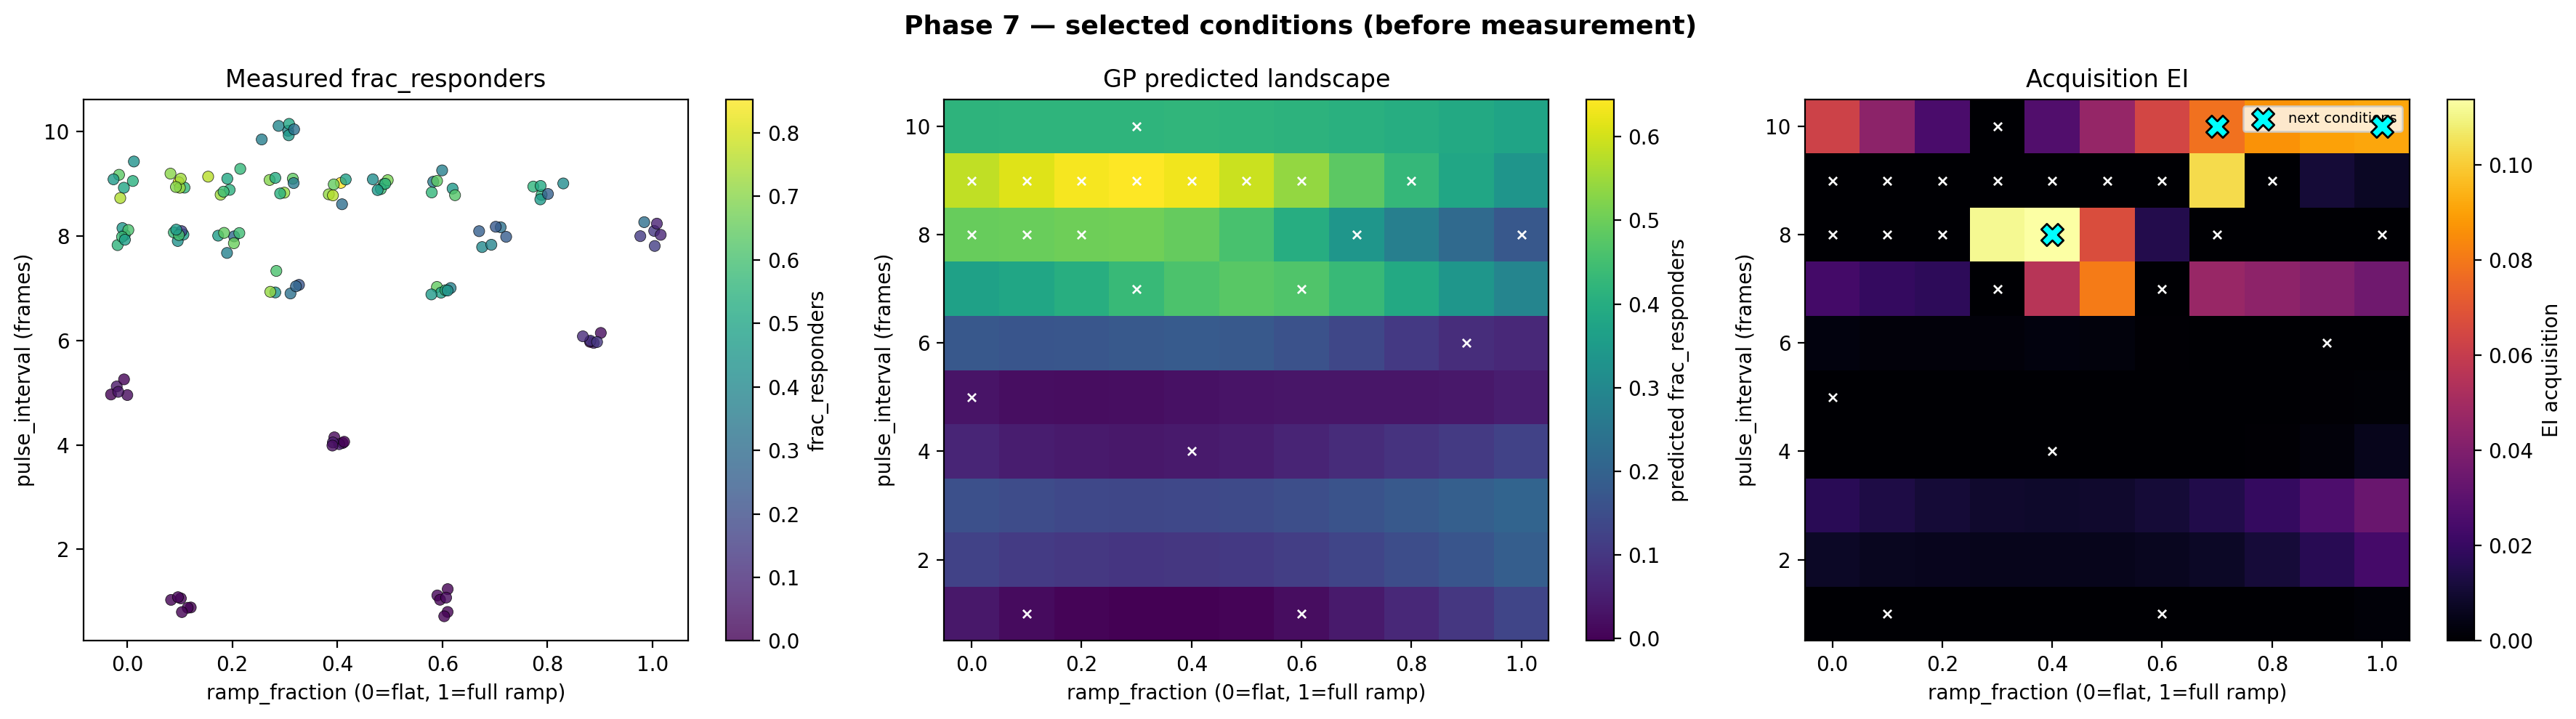

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.40, pulse_interval=8: n_pulses=8 -> base=750.0ms, ramp=142.86ms/pulse, peak=1750.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=1.00, pulse_interval=10: n_pulses=6 -> base=0.0ms, ramp=666.67ms/pulse, peak=3333.3ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.70, pulse_interval=10: n_pulses=6 -> base=500.0ms, ramp=466.67ms/pulse, peak=2833.3ms
  Cond 1: dropped 1/6 sub-25ms pulses (min computed exposure was 0.000 ms)
  Created 1620 events for phase 7
    Cond 0 (FOVs 126-131): stim_exposure=750ms, ramp=143ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1750ms)
    Cond 1 (FOVs 132-137): stim_exposure=0ms, ramp=667ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 3333ms)
    Cond 2 (FOVs 138-143): stim_exposure=500ms, ramp=467ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 2833ms)
  Recovered optoRTK for FOV 143 after 1.0 s re-read (150 cells, mean=132

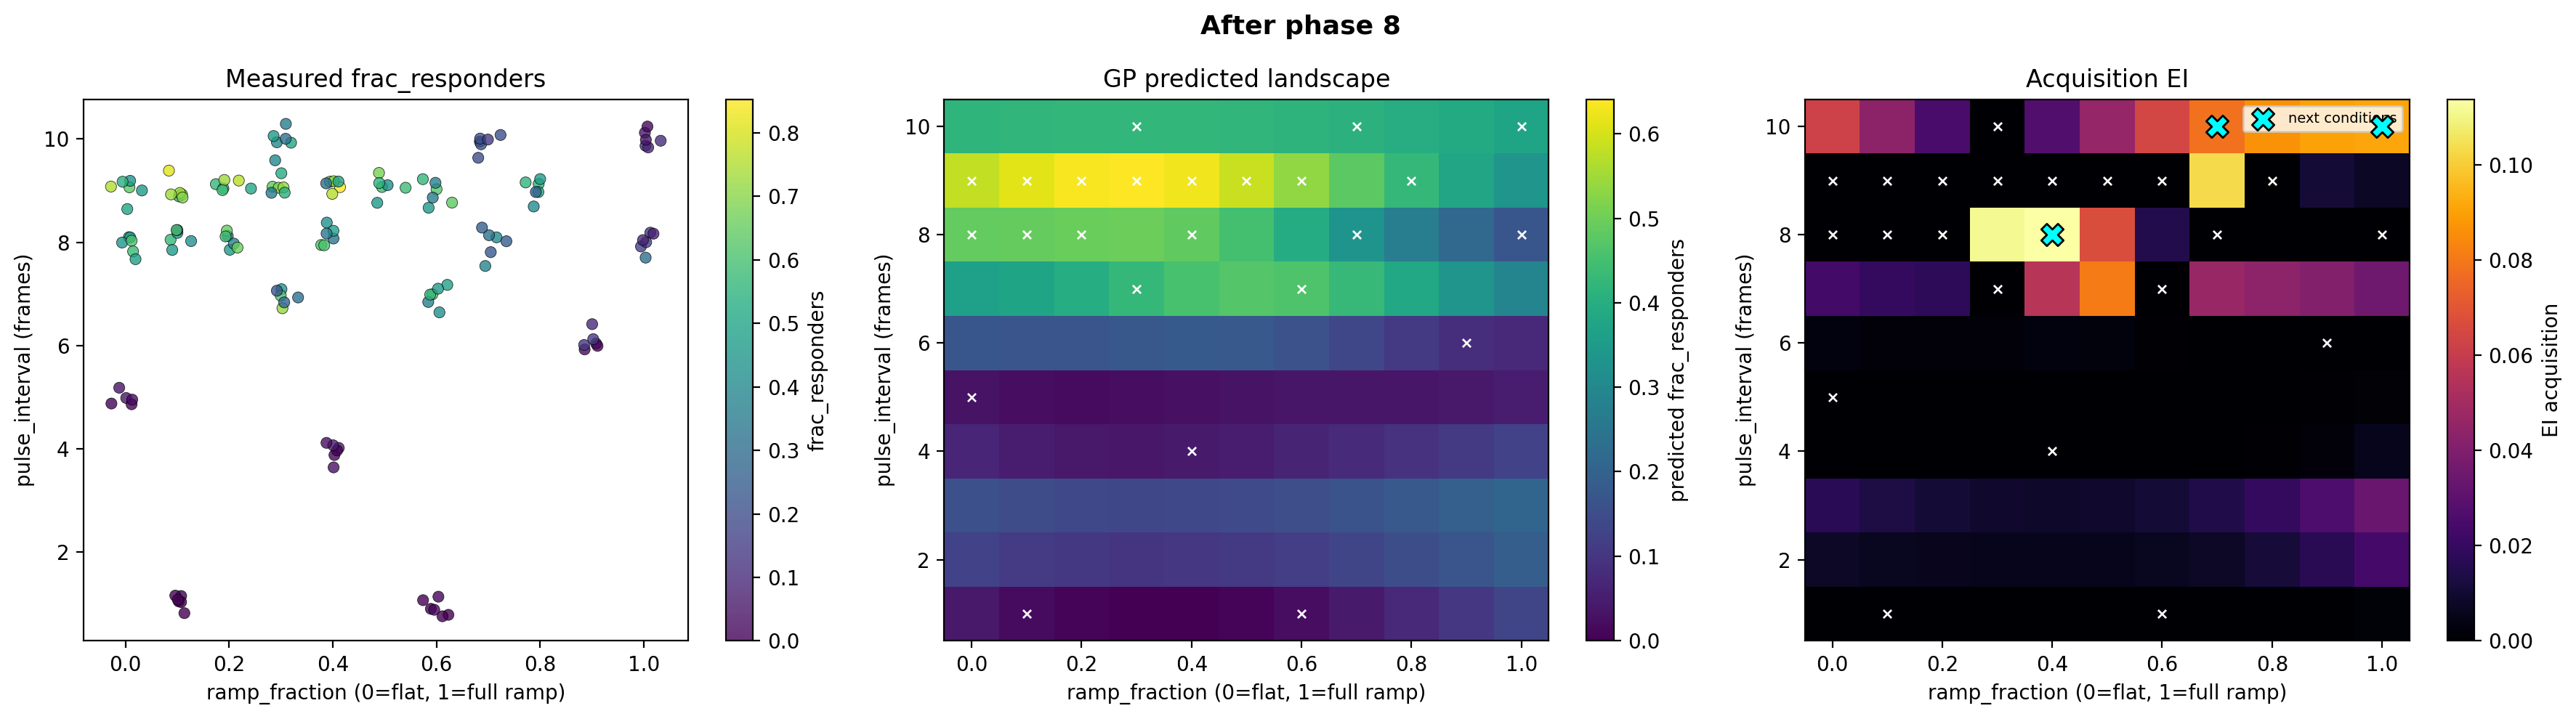


=== ComposedAgent: phase 9/13 ===
[FOVFinderAgent] Phase 8 — selected FOVs:
    E6_0000: 37 cells  cnr(mean=0.818, 81% below 1)
    E6_0001: 52 cells  cnr(mean=0.865, 79% below 1)
    E6_0002: 151 cells  cnr(mean=0.676, 91% below 1)
    E7_0000: 49 cells  cnr(mean=0.770, 85% below 1)
    E7_0001: 59 cells  cnr(mean=0.838, 83% below 1)
    E7_0002: 105 cells  cnr(mean=0.700, 91% below 1)
    E8_0000: 43 cells  cnr(mean=0.805, 90% below 1)
    E8_0001: 133 cells  cnr(mean=0.679, 92% below 1)
    E8_0002: 178 cells  cnr(mean=0.662, 93% below 1)
    E9_0000: 37 cells  cnr(mean=0.836, 81% below 1)
    E9_0001: 50 cells  cnr(mean=0.827, 80% below 1)
    E9_0002: 73 cells  cnr(mean=0.869, 71% below 1) (below min_cells)
    E10_0000: 41 cells  cnr(mean=0.873, 78% below 1)
    E10_0001: 43 cells  cnr(mean=0.786, 86% below 1)
    E10_0002: 110 cells  cnr(mean=0.732, 86% below 1)
    E11_0000: 42 cells  cnr(mean=0.833, 76% below 1)
    E11_0001: 50 cells  cnr(mean=0.867, 80% below 1)
    E11_000

sample: 100%|##########| 1200/1200 [00:09<00:00, 126.95it/s, 7 steps of size 5.49e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.58      0.40      1.55      0.92      2.18    723.14      1.00
k_length[1]      0.25      0.08      0.25      0.12      0.36    676.39      1.00
k_length[2]      7.88      3.11      7.24      3.67     12.29    844.56      1.00
k_length[3]      9.37      3.44      8.74      4.72     14.73    711.32      1.00
k_length[4]     11.78      7.00      9.98      3.78     20.18    547.56      1.00
    k_scale      1.00      0.39      0.93      0.42      1.50    616.38      1.00
      noise      0.12      0.02      0.12      0.09      0.14   1411.82      1.00

Computing robust acquisition over 1376 scenarios (86 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.619755
  Robust acq stats: min=0.000000, max=0.119886
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 85 grid points x 16 covariate samples
  best_

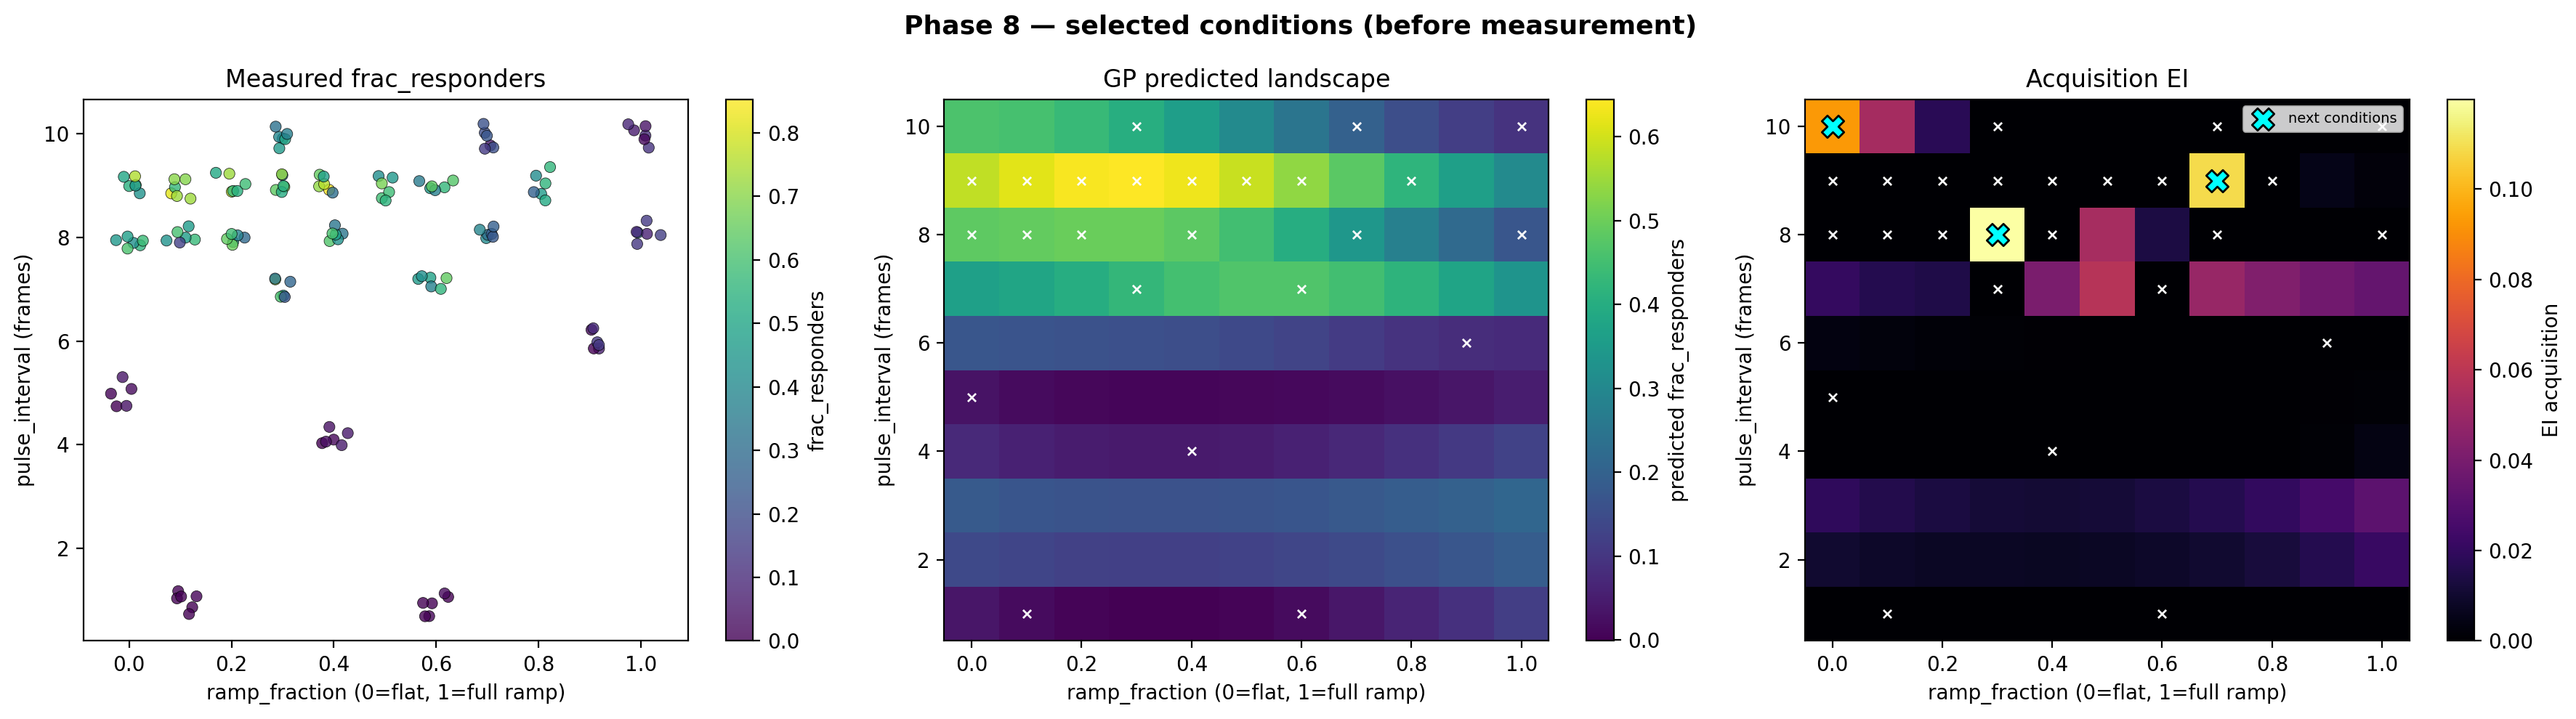

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.30, pulse_interval=8: n_pulses=8 -> base=875.0ms, ramp=107.14ms/pulse, peak=1625.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.70, pulse_interval=9: n_pulses=7 -> base=428.6ms, ramp=333.33ms/pulse, peak=2428.6ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.00, pulse_interval=10: n_pulses=6 -> base=1666.7ms, ramp=0.00ms/pulse, peak=1666.7ms
  Created 1620 events for phase 8
    Cond 0 (FOVs 144-149): stim_exposure=875ms, ramp=107ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1625ms)
    Cond 1 (FOVs 150-155): stim_exposure=429ms, ramp=333ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2429ms)
    Cond 2 (FOVs 156-161): stim_exposure=1667ms, ramp=0ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 1667ms)
  Recovered optoRTK for FOV 161 after 1.0 s re-read (67 cells, mean=1335.491)
  Phase 8: 18 FOVs, mean frac_oscillating=0.9997, max=1.0000
  optoRT

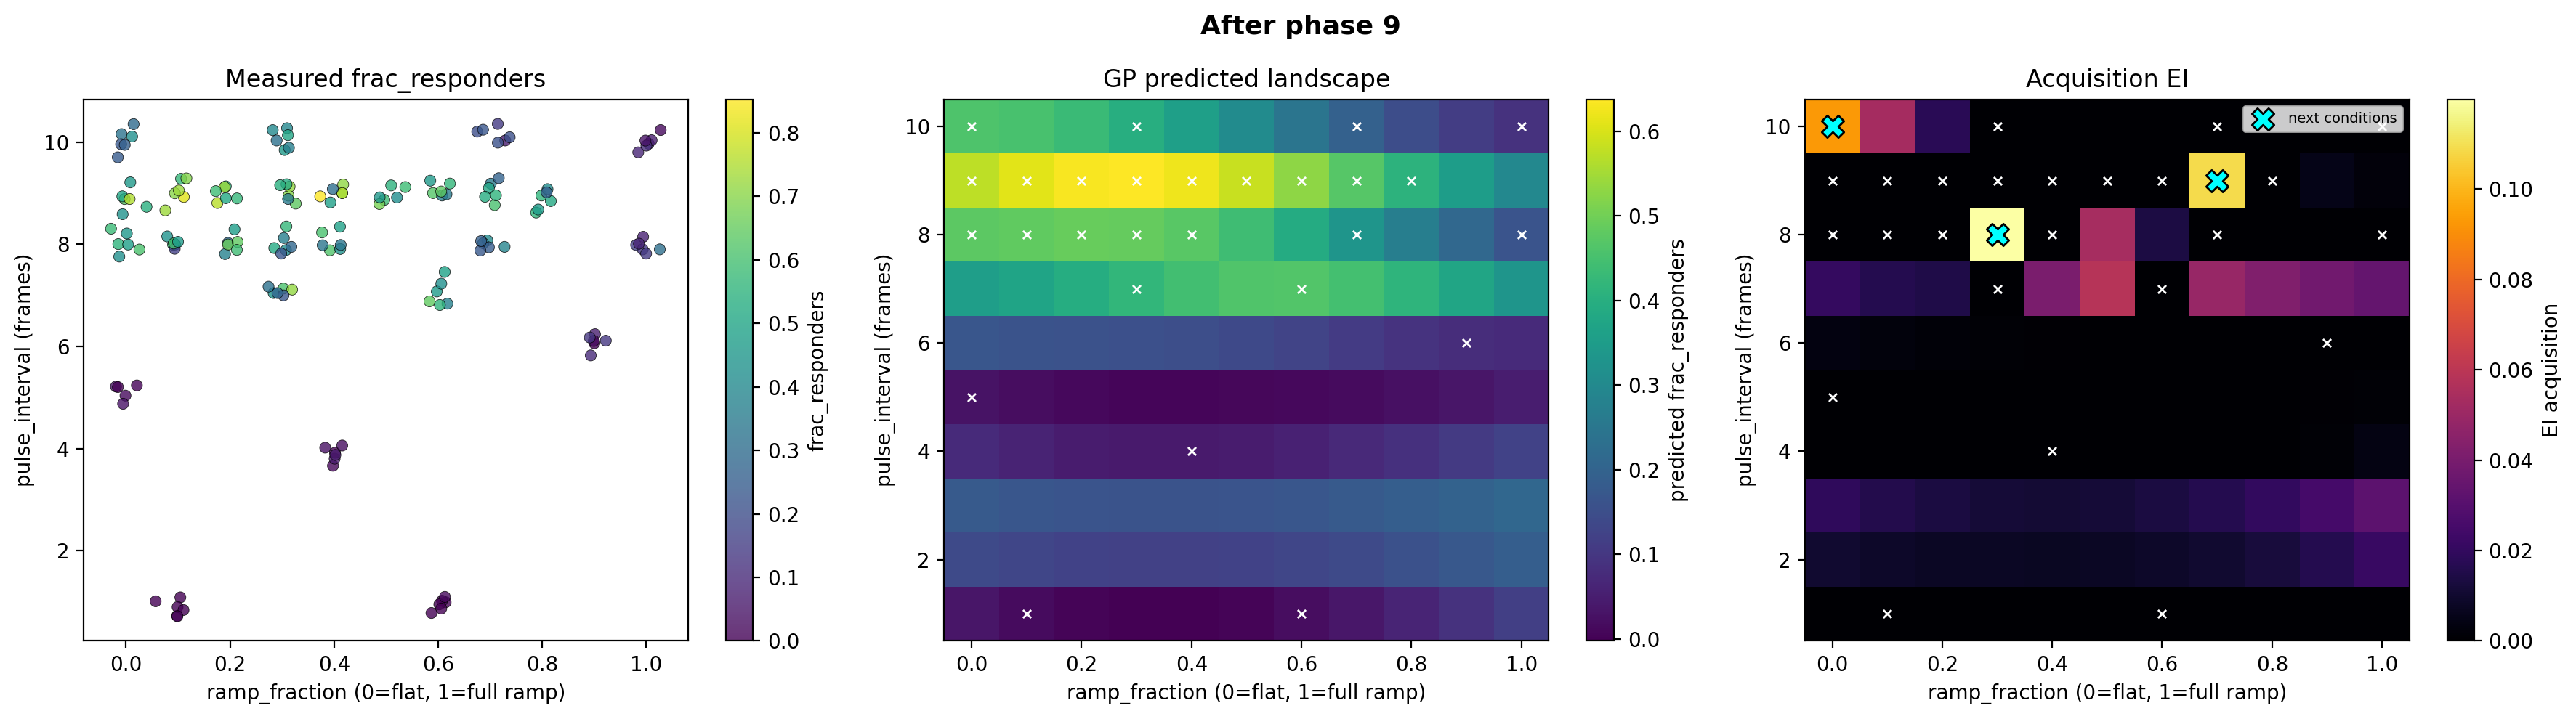


=== ComposedAgent: phase 10/13 ===
[FOVFinderAgent] Phase 9 — selected FOVs:
    E12_0000: 53 cells  cnr(mean=0.847, 69% below 1) (below min_cells)
    E12_0001: 48 cells  cnr(mean=0.884, 73% below 1) (below min_cells)
    E12_0002: 33 cells (below min_cells)
    F12_0000: 124 cells  cnr(mean=0.802, 81% below 1)
    F12_0001: 139 cells  cnr(mean=0.808, 83% below 1)
    F12_0002: 67 cells  cnr(mean=0.901, 65% below 1) (below min_cells)
    F11_0000: 85 cells  cnr(mean=0.843, 71% below 1) (below min_cells)
    F11_0001: 62 cells  cnr(mean=0.881, 74% below 1) (below min_cells)
    F11_0002: 61 cells  cnr(mean=0.943, 52% below 1) (below min_cells)
    F10_0000: 68 cells  cnr(mean=0.859, 81% below 1)
    F10_0001: 99 cells  cnr(mean=0.919, 68% below 1) (below min_cells)
    F10_0002: 53 cells  cnr(mean=0.910, 70% below 1) (below min_cells)
    F9_0000: 59 cells  cnr(mean=0.880, 76% below 1)
    F9_0001: 63 cells  cnr(mean=0.931, 66% below 1) (below min_cells)
    F9_0002: 53 cells  cnr(mea

sample: 100%|##########| 1200/1200 [00:12<00:00, 96.10it/s, 3 steps of size 5.66e-01. acc. prob=0.89]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.61      0.43      1.57      0.92      2.23    831.84      1.00
k_length[1]      0.26      0.07      0.26      0.15      0.37    821.42      1.00
k_length[2]      8.33      3.01      7.69      3.73     12.65    801.66      1.00
k_length[3]     10.20      3.58      9.59      5.06     15.54    752.71      1.00
k_length[4]     11.63      6.64      9.71      3.29     20.51    728.17      1.00
    k_scale      1.13      0.44      1.04      0.52      1.70    653.69      1.00
      noise      0.14      0.02      0.14      0.11      0.16   1326.68      1.00

Computing robust acquisition over 1328 scenarios (83 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.513584
  Robust acq stats: min=0.000000, max=0.106636
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 82 grid points x 16 covariate samples
  best_

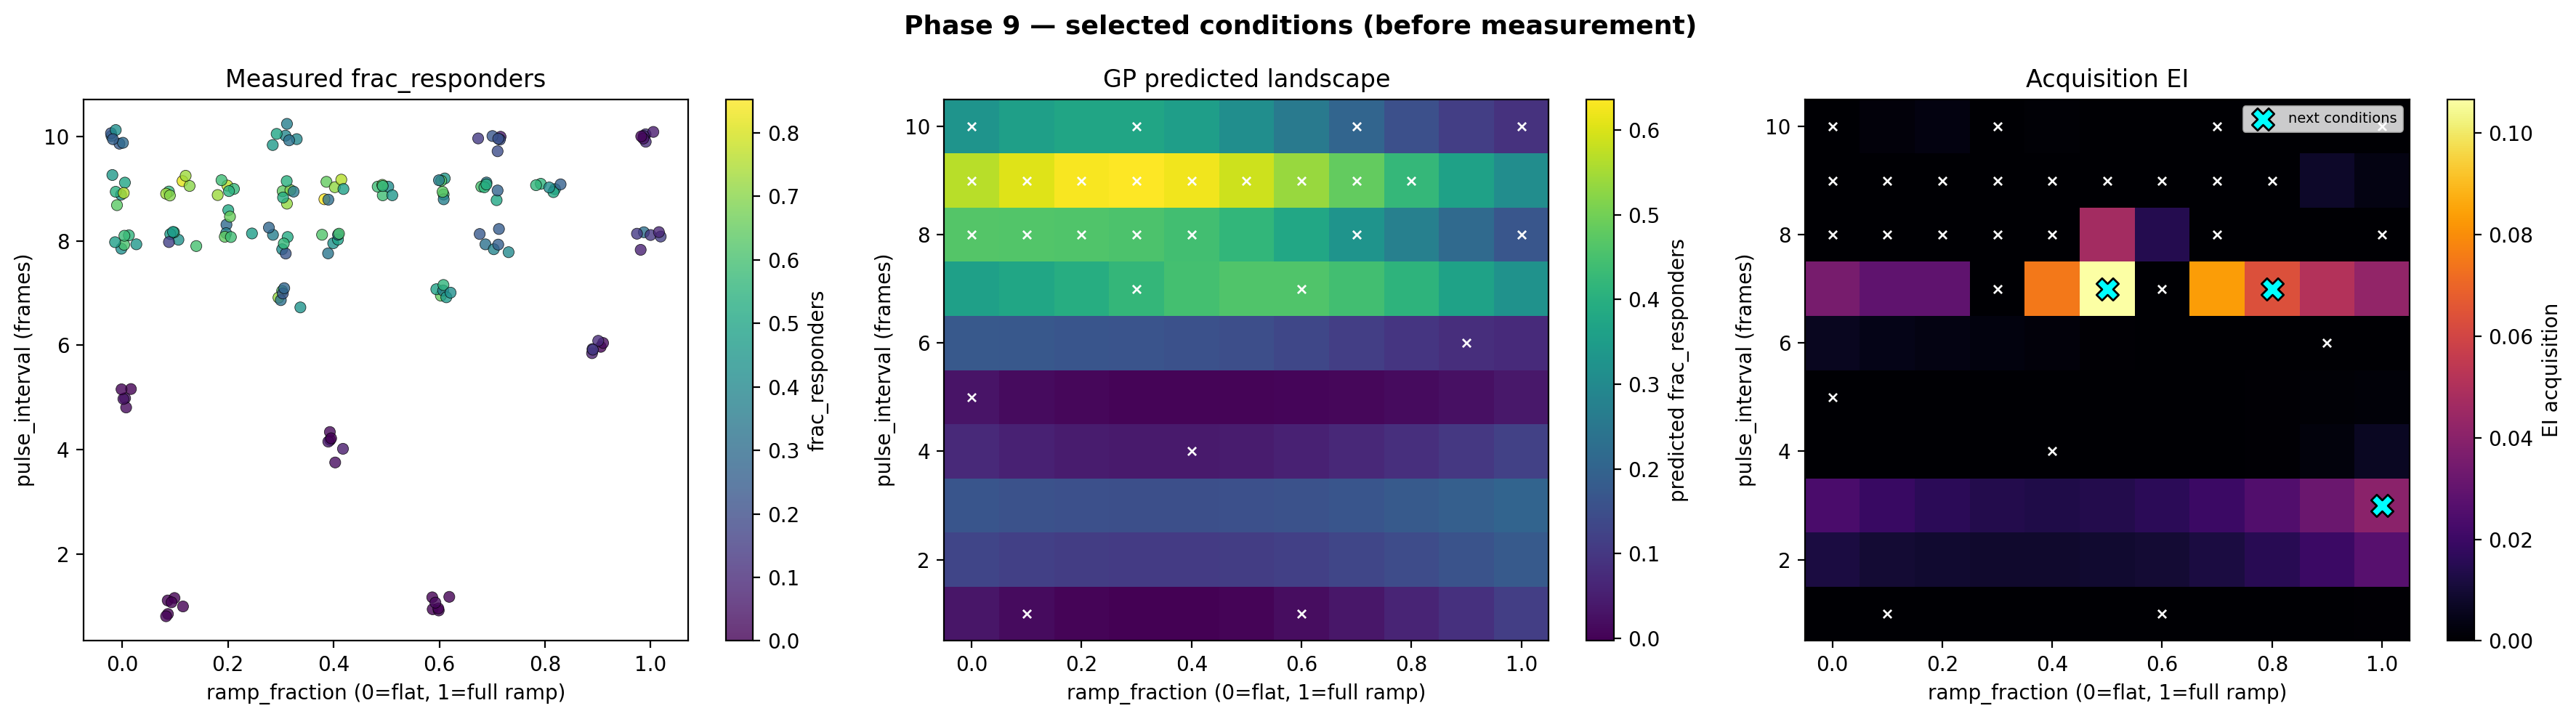

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.50, pulse_interval=7: n_pulses=9 -> base=555.6ms, ramp=138.89ms/pulse, peak=1666.7ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=1.00, pulse_interval=3: n_pulses=20 -> base=0.0ms, ramp=52.63ms/pulse, peak=1000.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.80, pulse_interval=7: n_pulses=9 -> base=222.2ms, ramp=222.22ms/pulse, peak=2000.0ms
  Cond 1: dropped 1/20 sub-25ms pulses (min computed exposure was 0.000 ms)
  Created 1620 events for phase 9
    Cond 0 (FOVs 162-167): stim_exposure=556ms, ramp=139ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 1667ms)
    Cond 1 (FOVs 168-173): stim_exposure=0ms, ramp=53ms/frame, pulse_interval=3min, n_pulses=20 (final exposure: 1000ms)
    Cond 2 (FOVs 174-179): stim_exposure=222ms, ramp=222ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 2000ms)
  Recovered optoRTK for FOV 179 after 1.0 s re-read (160 cells, mean=1212.5

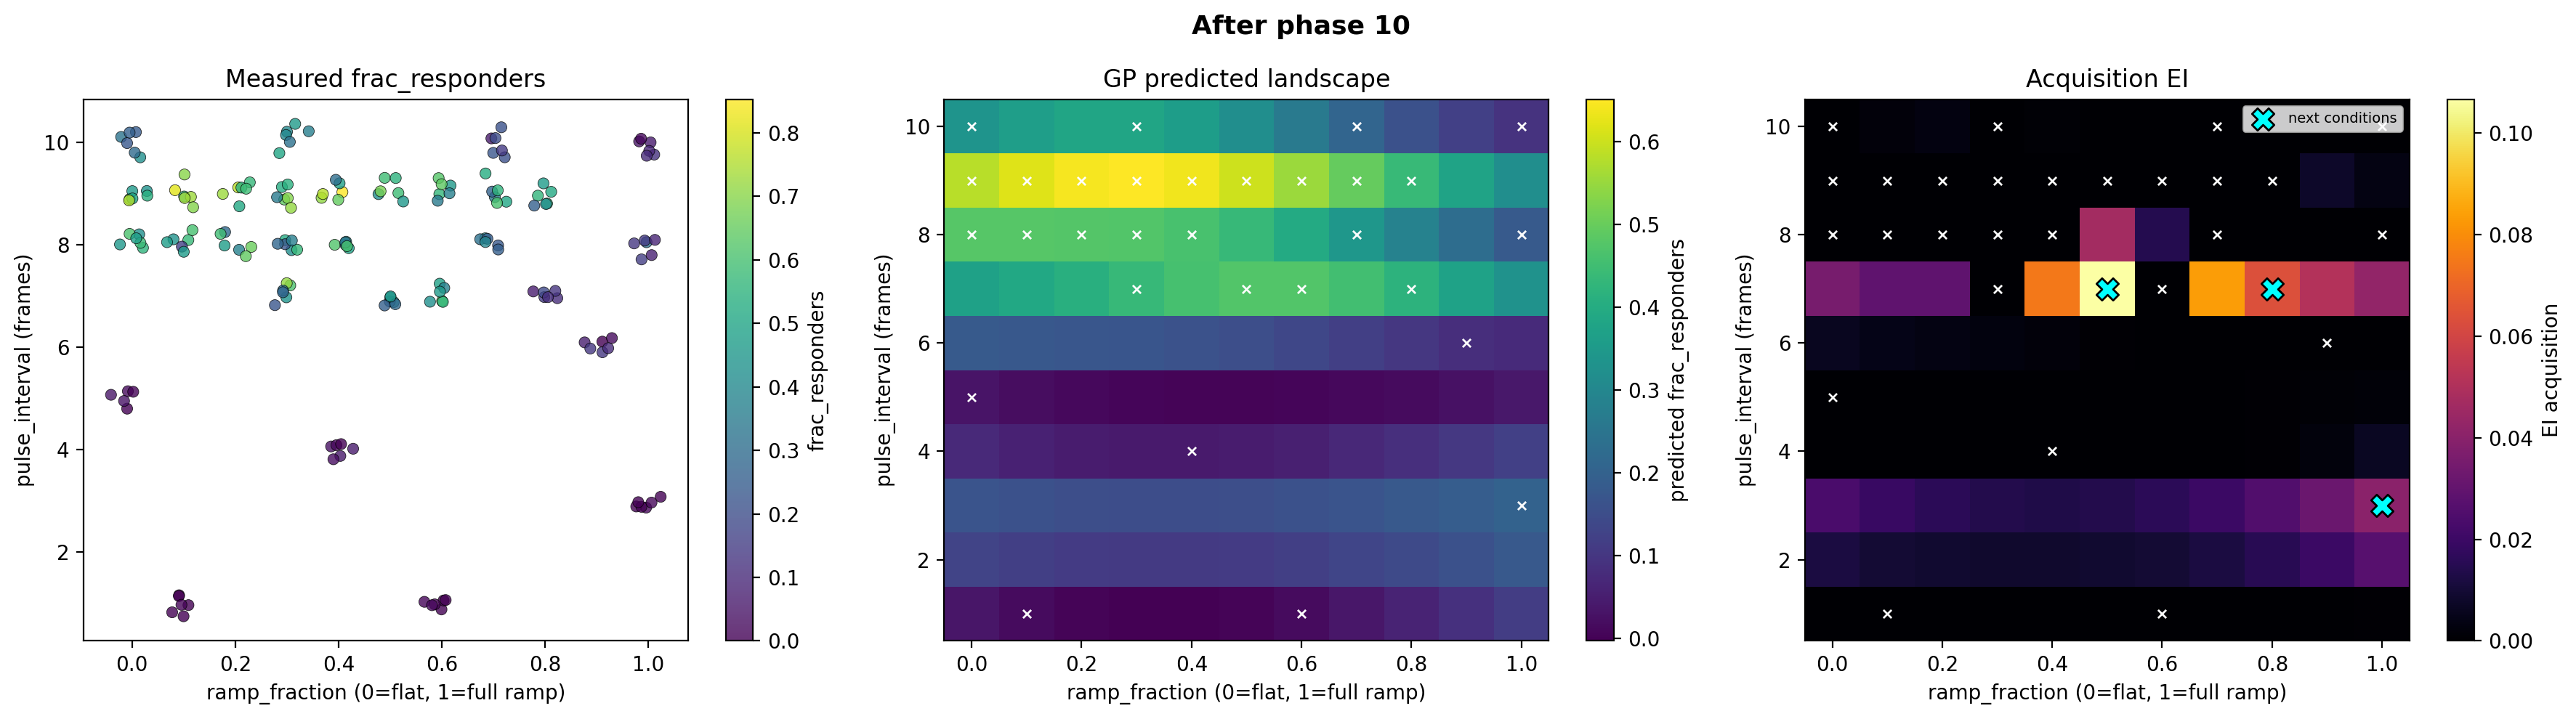


=== ComposedAgent: phase 11/13 ===
[FOVFinderAgent] Phase 10 — selected FOVs:
    F7_0000: 42 cells  cnr(mean=0.852, 85% below 1)
    F7_0001: 79 cells  cnr(mean=0.749, 81% below 1)
    F7_0002: 89 cells  cnr(mean=0.744, 88% below 1)
    F6_0000: 47 cells  cnr(mean=0.910, 81% below 1)
    F6_0001: 72 cells  cnr(mean=0.776, 79% below 1)
    F6_0002: 80 cells  cnr(mean=0.877, 76% below 1)
    F5_0000: 59 cells  cnr(mean=0.818, 81% below 1)
    F5_0001: 97 cells  cnr(mean=0.744, 87% below 1)
    F5_0002: 124 cells  cnr(mean=0.704, 91% below 1)
    F4_0000: 46 cells  cnr(mean=0.828, 83% below 1)
    F4_0001: 65 cells  cnr(mean=0.774, 82% below 1)
    F4_0002: 88 cells  cnr(mean=0.747, 79% below 1)
    F3_0000: 142 cells  cnr(mean=0.696, 87% below 1)
    F3_0001: 147 cells  cnr(mean=0.743, 84% below 1)
    F3_0002: 86 cells  cnr(mean=0.871, 70% below 1) (below min_cells)
    F2_0000: 39 cells  cnr(mean=0.739, 87% below 1)
    F2_0001: 66 cells  cnr(mean=0.793, 76% below 1)
    F2_0002: 83 

sample: 100%|##########| 1200/1200 [00:15<00:00, 78.33it/s, 7 steps of size 5.16e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.32      0.35      1.29      0.75      1.85    803.06      1.00
k_length[1]      0.34      0.07      0.33      0.23      0.45    635.32      1.00
k_length[2]      8.44      3.01      7.89      3.90     12.88    858.69      1.00
k_length[3]      9.91      3.51      9.17      5.17     15.51    556.13      1.00
k_length[4]      9.06      4.73      7.89      3.59     15.42    819.91      1.00
    k_scale      1.15      0.45      1.06      0.53      1.71    555.47      1.00
      noise      0.13      0.02      0.13      0.11      0.16   1188.76      1.00

Computing robust acquisition over 1280 scenarios (80 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.380050
  Robust acq stats: min=0.000000, max=0.175992
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 79 grid points x 16 covariate samples
  best_

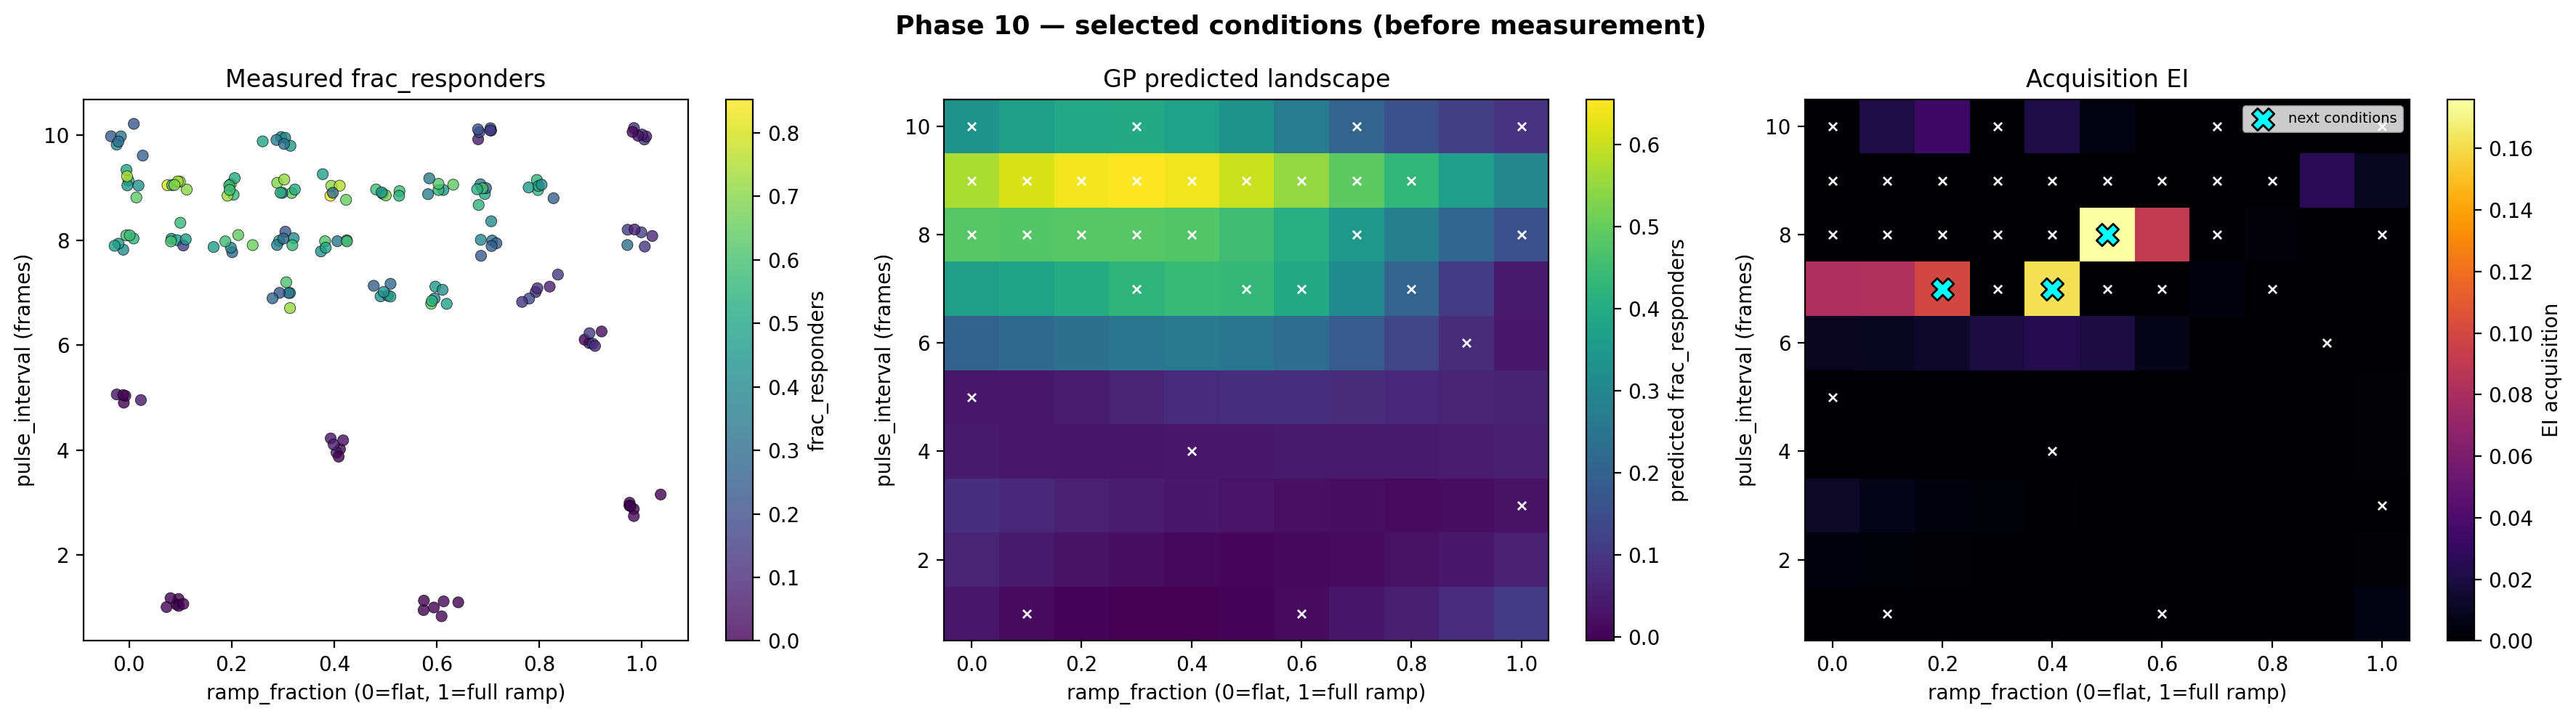

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.50, pulse_interval=8: n_pulses=8 -> base=625.0ms, ramp=178.57ms/pulse, peak=1875.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.40, pulse_interval=7: n_pulses=9 -> base=666.7ms, ramp=111.11ms/pulse, peak=1555.6ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.20, pulse_interval=7: n_pulses=9 -> base=888.9ms, ramp=55.56ms/pulse, peak=1333.3ms
  Created 1620 events for phase 10
    Cond 0 (FOVs 180-185): stim_exposure=625ms, ramp=179ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 1875ms)
    Cond 1 (FOVs 186-191): stim_exposure=667ms, ramp=111ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 1556ms)
    Cond 2 (FOVs 192-197): stim_exposure=889ms, ramp=56ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 1333ms)
  Recovered optoRTK for FOV 197 after 1.0 s re-read (87 cells, mean=1279.556)
  Phase 10: 18 FOVs, mean frac_oscillating=0.9990, max=1.0000
  optoRT

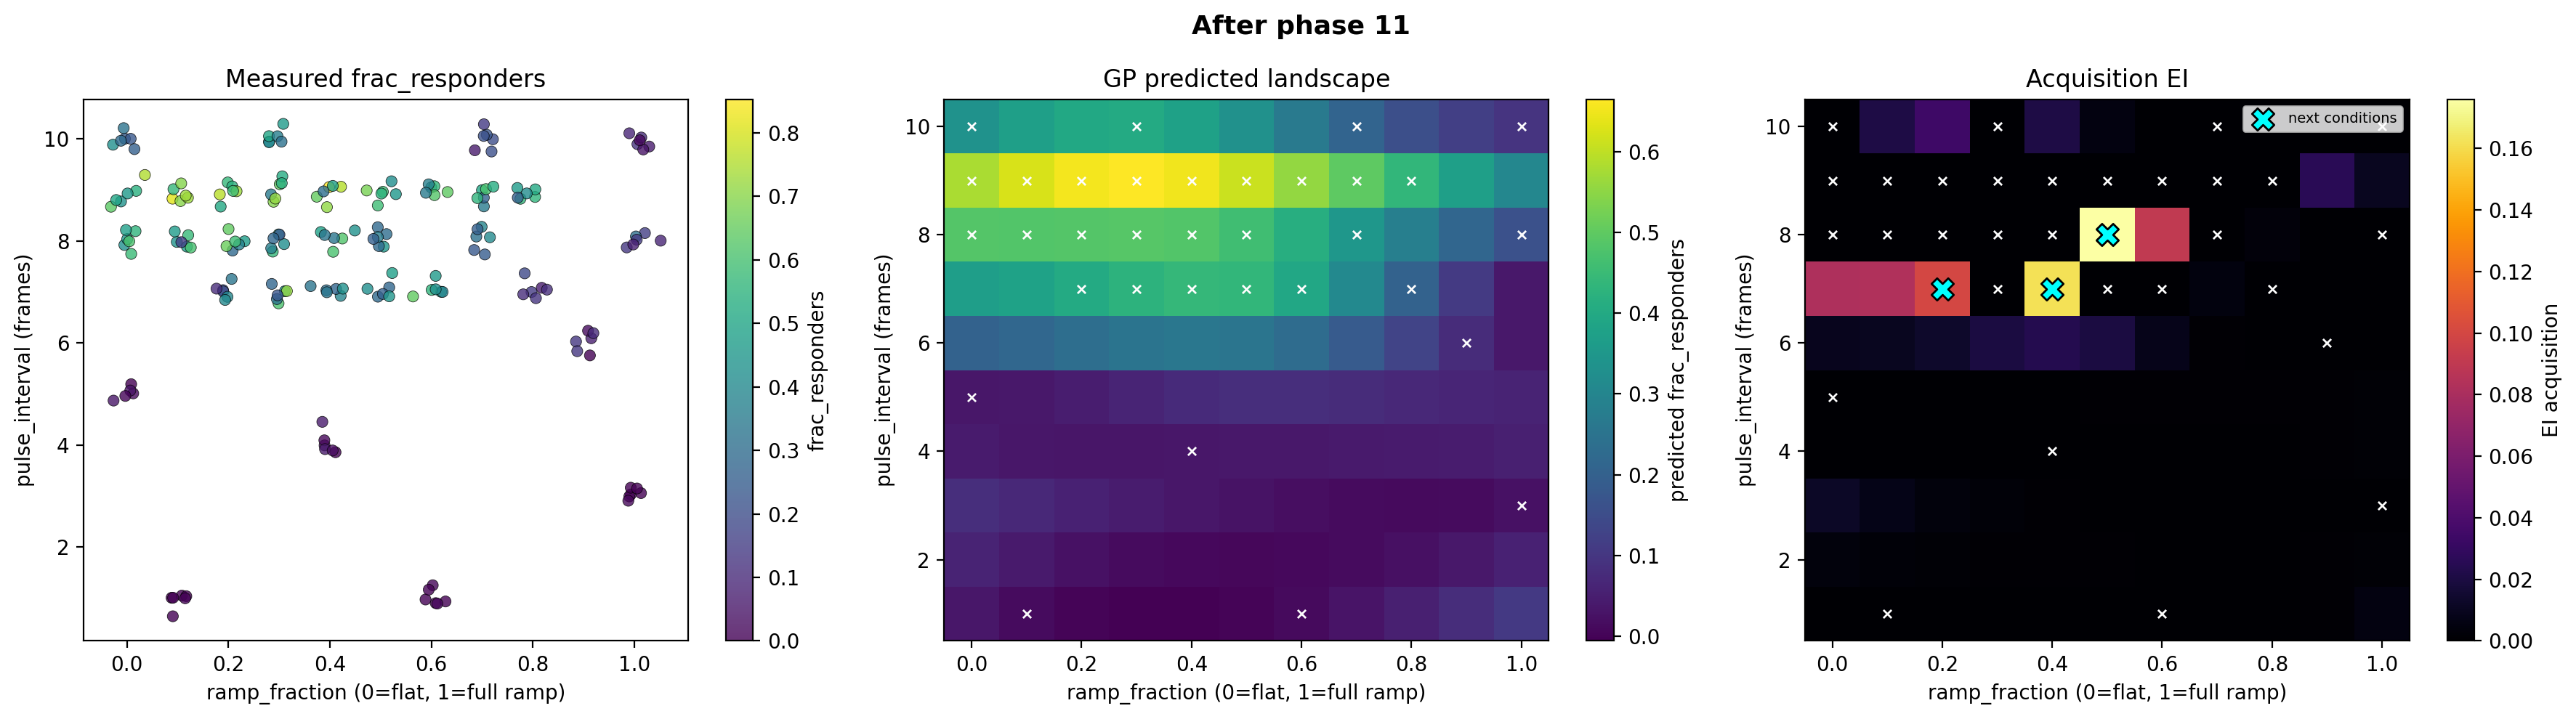


=== ComposedAgent: phase 12/13 ===
[FOVFinderAgent] Phase 11 — selected FOVs:
    G2_0000: 44 cells  cnr(mean=0.761, 84% below 1)
    G2_0001: 75 cells  cnr(mean=0.829, 80% below 1)
    G2_0002: 126 cells  cnr(mean=0.778, 82% below 1)
    G3_0000: 150 cells  cnr(mean=0.781, 82% below 1)
    G3_0001: 199 cells  cnr(mean=0.630, 92% below 1)
    G3_0002: 76 cells  cnr(mean=0.875, 70% below 1) (below min_cells)
    G4_0000: 56 cells  cnr(mean=0.812, 78% below 1)
    G4_0001: 89 cells  cnr(mean=0.754, 82% below 1)
    G4_0002: 201 cells  cnr(mean=0.580, 98% below 1)
    G5_0000: 45 cells  cnr(mean=0.803, 89% below 1)
    G5_0001: 95 cells  cnr(mean=0.758, 91% below 1)
    G5_0002: 124 cells  cnr(mean=0.669, 93% below 1)
    G6_0000: 85 cells  cnr(mean=0.864, 75% below 1)
    G6_0001: 67 cells  cnr(mean=0.823, 72% below 1) (below min_cells)
    G6_0002: 56 cells  cnr(mean=0.925, 65% below 1) (below min_cells)
    G7_0000: 63 cells  cnr(mean=0.769, 81% below 1)
    G7_0001: 65 cells  cnr(mea

sample: 100%|##########| 1200/1200 [00:17<00:00, 68.76it/s, 7 steps of size 5.54e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.20      0.34      1.17      0.67      1.75    754.38      1.00
k_length[1]      0.32      0.07      0.32      0.20      0.41    719.66      1.00
k_length[2]      9.37      3.48      8.55      4.24     14.23    800.08      1.00
k_length[3]      9.24      3.00      8.76      4.61     13.60    642.24      1.00
k_length[4]     10.12      5.56      8.70      2.98     17.05    680.29      1.01
    k_scale      1.20      0.45      1.10      0.58      1.80    518.91      1.00
      noise      0.14      0.02      0.14      0.12      0.17   1006.21      1.00

Computing robust acquisition over 1232 scenarios (77 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.169191
  Robust acq stats: min=0.000000, max=0.109768
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 76 grid points x 16 covariate samples
  best_

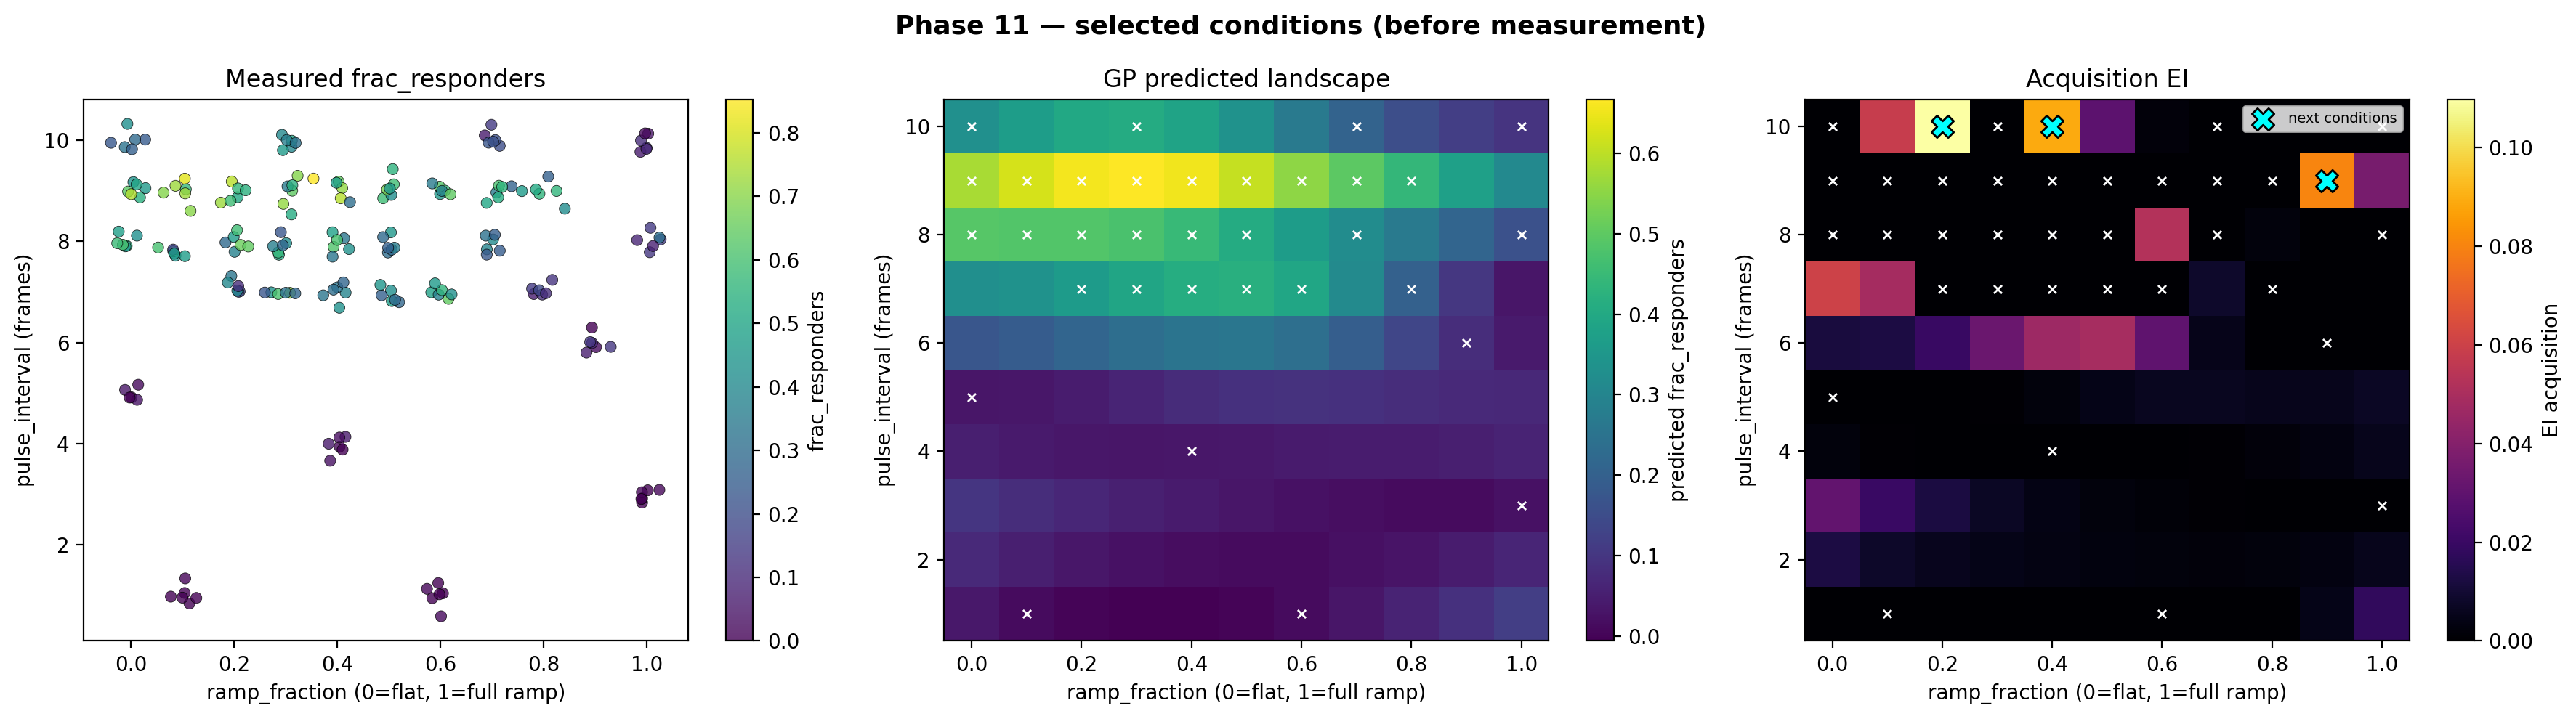

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.20, pulse_interval=10: n_pulses=6 -> base=1333.3ms, ramp=133.33ms/pulse, peak=2000.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.40, pulse_interval=10: n_pulses=6 -> base=1000.0ms, ramp=266.67ms/pulse, peak=2333.3ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.90, pulse_interval=9: n_pulses=7 -> base=142.9ms, ramp=428.57ms/pulse, peak=2714.3ms
  Created 1620 events for phase 11
    Cond 0 (FOVs 198-203): stim_exposure=1333ms, ramp=133ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 2000ms)
    Cond 1 (FOVs 204-209): stim_exposure=1000ms, ramp=267ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 2333ms)
    Cond 2 (FOVs 210-215): stim_exposure=143ms, ramp=429ms/frame, pulse_interval=9min, n_pulses=7 (final exposure: 2714ms)
  Recovered optoRTK for FOV 215 after 1.0 s re-read (112 cells, mean=1325.009)
  Phase 11: 18 FOVs, mean frac_oscillating=1.0000, max=1.00

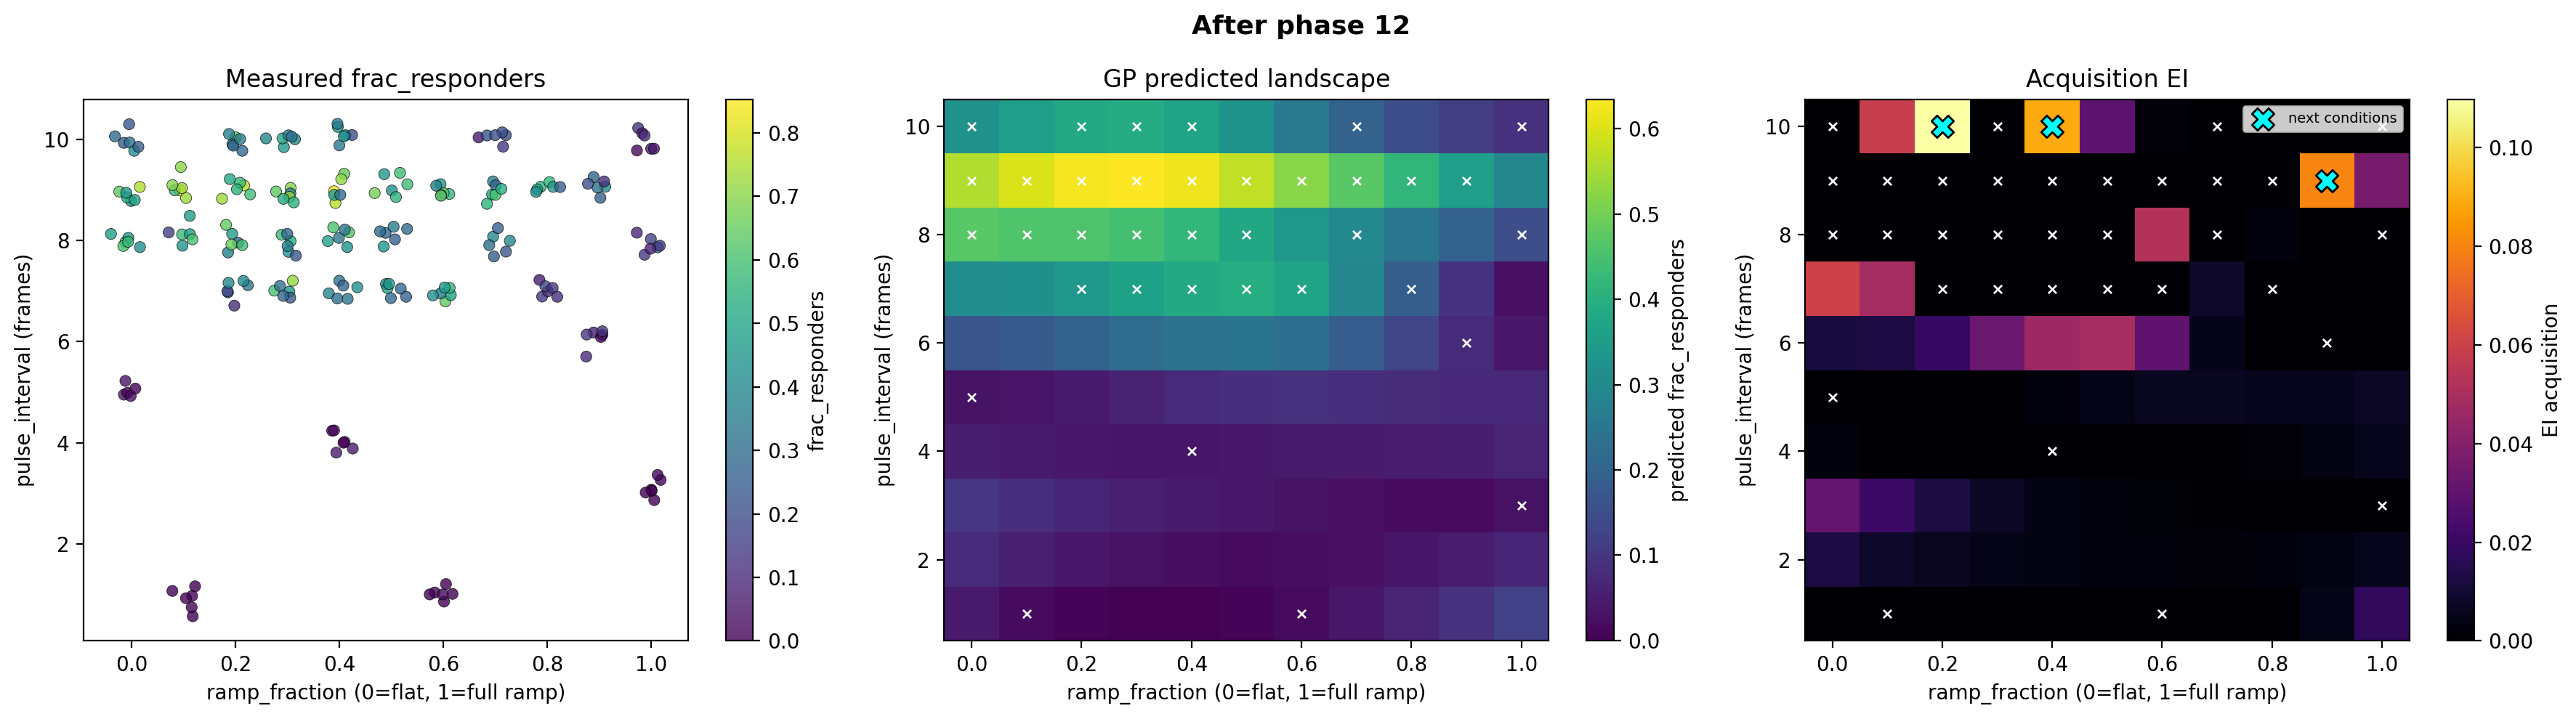


=== ComposedAgent: phase 13/13 ===
[FOVFinderAgent] Phase 12 — selected FOVs:
    G8_0000: 65 cells  cnr(mean=0.857, 78% below 1)
    G8_0001: 66 cells  cnr(mean=0.835, 82% below 1)
    G8_0002: 78 cells  cnr(mean=0.801, 83% below 1)
    G9_0000: 48 cells  cnr(mean=0.724, 87% below 1)
    G9_0001: 72 cells  cnr(mean=0.777, 86% below 1)
    G9_0002: 109 cells  cnr(mean=0.824, 76% below 1)
    G10_0000: 43 cells  cnr(mean=0.835, 79% below 1)
    G10_0001: 68 cells  cnr(mean=0.786, 77% below 1)
    G10_0002: 126 cells  cnr(mean=0.674, 89% below 1)
    G11_0000: 52 cells  cnr(mean=0.800, 77% below 1)
    G11_0001: 56 cells  cnr(mean=0.837, 80% below 1)
    G11_0002: 53 cells  cnr(mean=0.947, 60% below 1) (below min_cells)
    G12_0000: 38 cells  cnr(mean=0.687, 82% below 1)
    G12_0001: 49 cells  cnr(mean=0.735, 90% below 1)
    G12_0002: 160 cells  cnr(mean=0.602, 94% below 1)
    H12_0000: 42 cells  cnr(mean=0.635, 95% below 1)
    H12_0001: 56 cells  cnr(mean=0.726, 86% below 1)
    H

sample: 100%|##########| 1200/1200 [00:20<00:00, 57.35it/s, 7 steps of size 4.88e-01. acc. prob=0.92] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.20      0.33      1.17      0.66      1.74    744.49      1.00
k_length[1]      0.33      0.06      0.32      0.23      0.43    662.48      1.00
k_length[2]      9.06      3.36      8.44      4.08     13.93    523.63      1.00
k_length[3]      8.93      2.85      8.51      4.71     13.25    695.55      1.00
k_length[4]     10.67      6.09      8.95      3.30     19.05    640.70      1.00
    k_scale      1.24      0.46      1.16      0.56      1.82    548.62      1.00
      noise      0.15      0.02      0.15      0.12      0.18   1179.06      1.00

Computing robust acquisition over 1184 scenarios (74 grid points x 16 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.105528
  Robust acq stats: min=0.000001, max=0.107860
  [reusing cached GP fit from earlier in this batch]
  [cached predict] reusing predictions for 73 grid points x 16 covariate samples
  best_

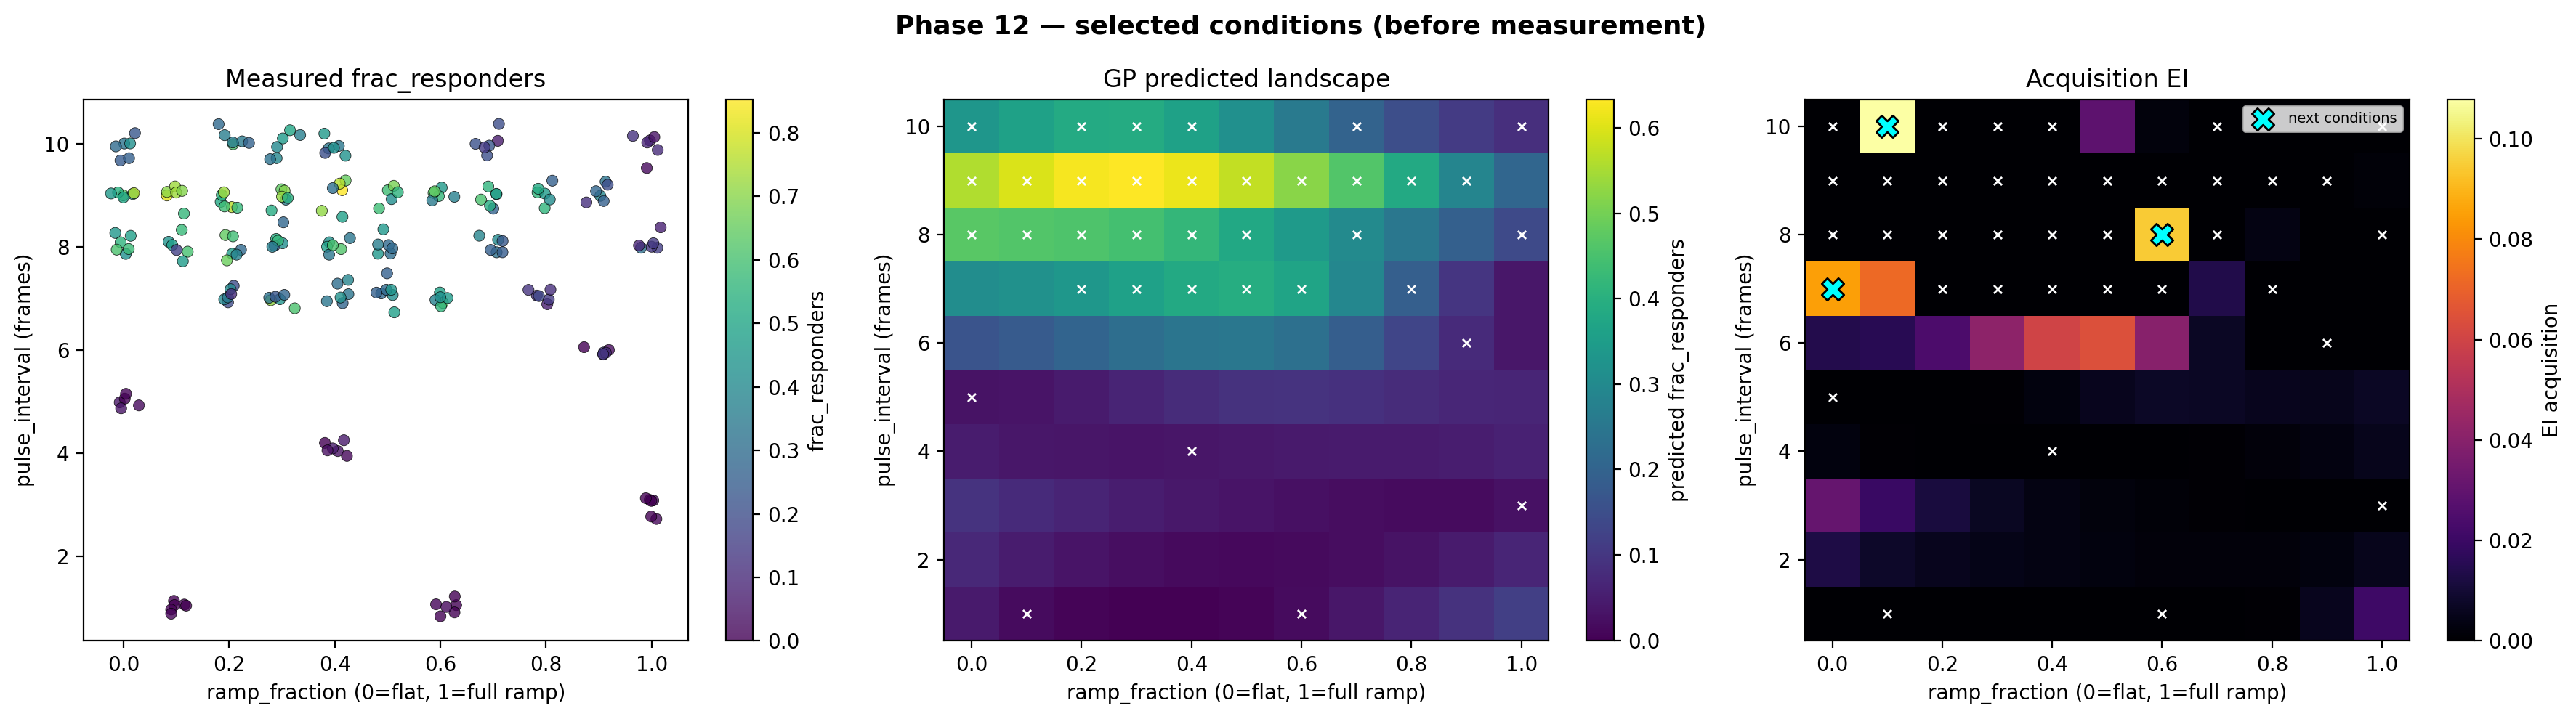

    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.10, pulse_interval=10: n_pulses=6 -> base=1500.0ms, ramp=66.67ms/pulse, peak=1833.3ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.60, pulse_interval=8: n_pulses=8 -> base=500.0ms, ramp=214.29ms/pulse, peak=2000.0ms
    [fixed-budget reparam] light_budget=10000ms, ramp_fraction=0.00, pulse_interval=7: n_pulses=9 -> base=1111.1ms, ramp=0.00ms/pulse, peak=1111.1ms
  Created 1620 events for phase 12
    Cond 0 (FOVs 216-221): stim_exposure=1500ms, ramp=67ms/frame, pulse_interval=10min, n_pulses=6 (final exposure: 1833ms)
    Cond 1 (FOVs 222-227): stim_exposure=500ms, ramp=214ms/frame, pulse_interval=8min, n_pulses=8 (final exposure: 2000ms)
    Cond 2 (FOVs 228-233): stim_exposure=1111ms, ramp=0ms/frame, pulse_interval=7min, n_pulses=9 (final exposure: 1111ms)
  Recovered optoRTK for FOV 233 after 1.0 s re-read (138 cells, mean=1607.563)
  Phase 12: 18 FOVs, mean frac_oscillating=0.9972, max=1.0000
  opt

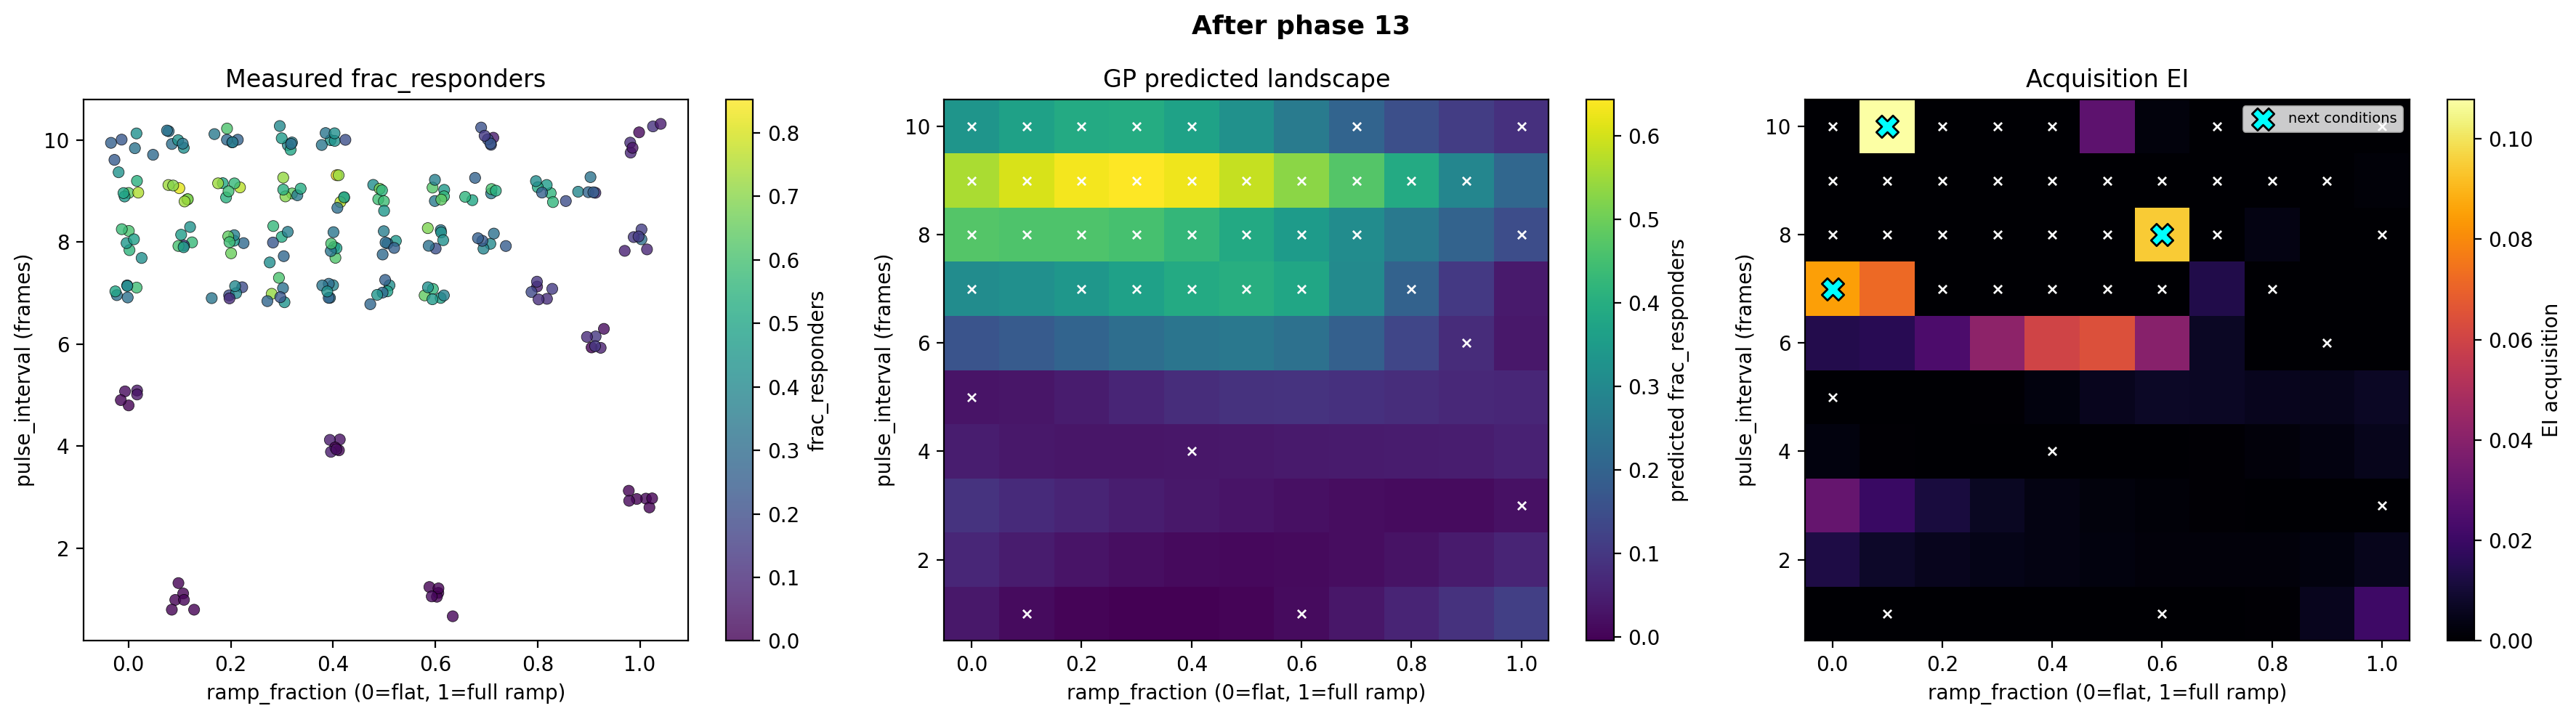

In [14]:
# --- Run the composed (FOV finder + BO) loop ---
# Each phase: FOVFinder picks 18 fresh FOVs (3 FOVs in 6 fresh wells), then
# OscillationBO runs one batch BO iteration over those FOVs.  The GP
# accumulates observations across all phases.

# Disconnect napari live view so it does not interfere with the acquisition engine.


try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass


for i in range(0, 3600 * 10):
    time.sleep(1)


composed_agent.run()

In [15]:
# Post-processing: merge per-FOV tracks
utils.generate_exp_data_from_tracks(path)

## Visualise results

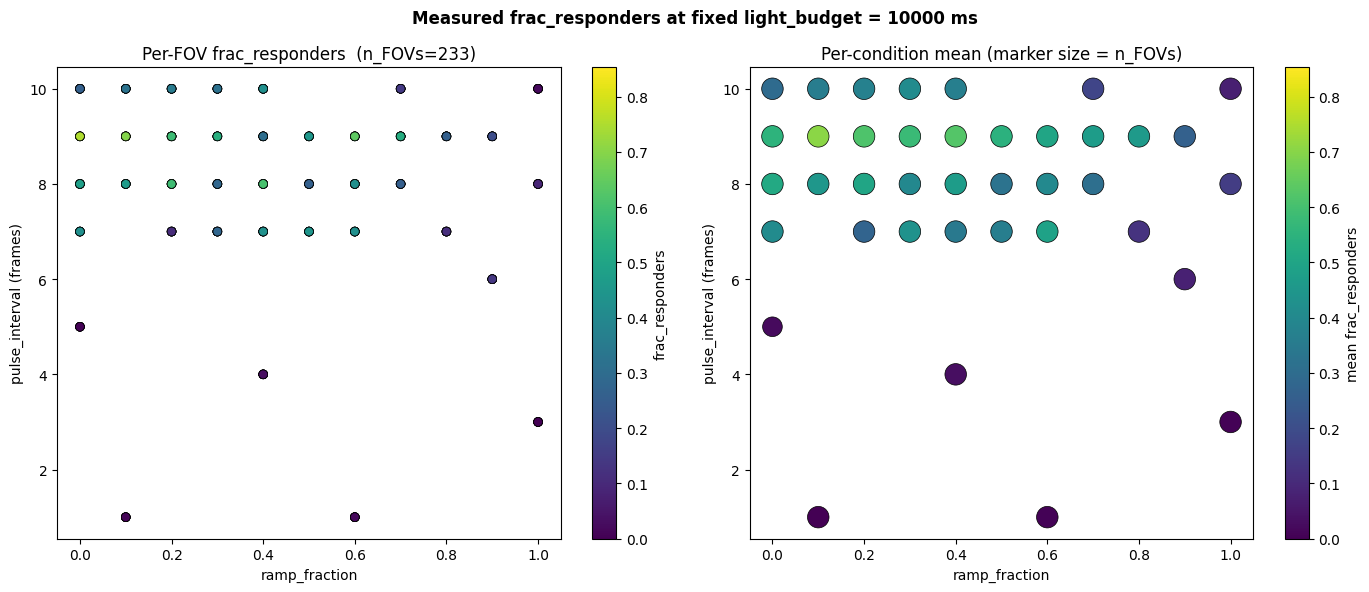

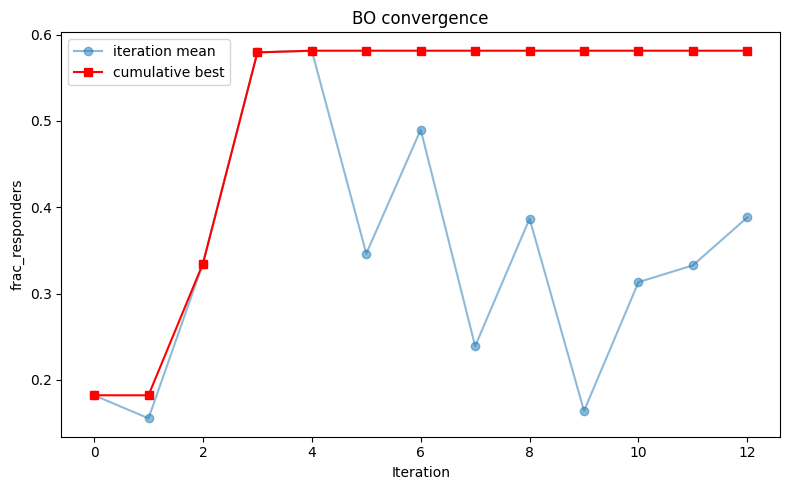


Best condition by frac_responders (mean across FOVs):
  light_budget          = 10000 ms (pinned)
  ramp_fraction         = 0.10
  pulse_interval        = 9 frames
  -> derived base_exp   = 1285.7 ms
  -> derived ramp       = 47.62 ms/pulse
  mean frac_responders  = 0.7051
  mean_cnr_above_baseline = 0.2809
  frac_responders       = 0.7051
  tested on 6 FOVs


In [16]:
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name

    # Single panel: 2 BO axes (ramp_fraction × pulse_interval).
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), squeeze=False)

    vmin = float(df[obj_name].min())
    vmax = float(df[obj_name].max())

    # --- per-FOV scatter ---
    ax = axes[0, 0]
    sc = ax.scatter(
        df["ramp_fraction"],
        df["pulse_interval"].astype(int),
        c=df[obj_name],
        cmap="viridis",
        s=40,
        edgecolors="k",
        linewidths=0.5,
        vmin=vmin,
        vmax=vmax,
    )
    fig.colorbar(sc, ax=ax, label=obj_name)
    ax.set_xlabel("ramp_fraction")
    ax.set_ylabel("pulse_interval (frames)")
    ax.set_title(f"Per-FOV {obj_name}  (n_FOVs={len(df)})")

    # --- per-condition mean ---
    ax = axes[0, 1]
    cond_agg = (
        df.groupby(["ramp_fraction", "pulse_interval"])
        .agg(mean_obj=(obj_name, "mean"), n_fovs=(obj_name, "count"))
        .reset_index()
    )
    if not cond_agg.empty:
        sc = ax.scatter(
            cond_agg["ramp_fraction"],
            cond_agg["pulse_interval"].astype(int),
            c=cond_agg["mean_obj"],
            s=cond_agg["n_fovs"] * 40,
            cmap="viridis",
            edgecolors="k",
            linewidths=0.5,
            vmin=vmin,
            vmax=vmax,
        )
        fig.colorbar(sc, ax=ax, label=f"mean {obj_name}")
    ax.set_xlabel("ramp_fraction")
    ax.set_ylabel("pulse_interval (frames)")
    ax.set_title("Per-condition mean (marker size = n_FOVs)")

    fig.suptitle(
        f"Measured {obj_name} at fixed light_budget = {LIGHT_BUDGET_MS:.0f} ms",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # --- Convergence (single panel) ---
    if agent._iteration_means:
        fig, ax = plt.subplots(figsize=(8, 5))
        means = np.array(agent._iteration_means)
        cumulative_best = np.maximum.accumulate(means)
        ax.plot(means, "o-", alpha=0.5, label="iteration mean")
        ax.plot(cumulative_best, "s-", color="red", label="cumulative best")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(obj_name)
        ax.set_title("BO convergence")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # --- Best condition by configured BO objective ---
    cond_agg_all = (
        df.groupby(["ramp_fraction", "pulse_interval"])
        .agg(
            mean_obj=(obj_name, "mean"),
            mean_response=("mean_cnr_above_baseline", "mean"),
            mean_frac_resp=("frac_responders", "mean"),
            n_fovs=(obj_name, "count"),
            mean_base_exposure=("stim_exposure", "mean"),
            mean_ramp=("ramp", "mean"),
        )
        .reset_index()
    )
    best_idx = cond_agg_all["mean_obj"].idxmax()
    best = cond_agg_all.loc[best_idx]
    print(f"\nBest condition by {obj_name} (mean across FOVs):")
    print(f"  light_budget          = {LIGHT_BUDGET_MS:.0f} ms (pinned)")
    print(f"  ramp_fraction         = {best['ramp_fraction']:.2f}")
    print(f"  pulse_interval        = {int(best['pulse_interval'])} frames")
    print(f"  -> derived base_exp   = {best['mean_base_exposure']:.1f} ms")
    print(f"  -> derived ramp       = {best['mean_ramp']:.2f} ms/pulse")
    print(f"  mean {obj_name:<17}= {best['mean_obj']:.4f}")
    print(f"  mean_cnr_above_baseline = {best['mean_response']:.4f}")
    print(f"  frac_responders       = {best['mean_frac_resp']:.4f}")
    print(f"  tested on {int(best['n_fovs'])} FOVs")
else:
    print("No data collected yet.")

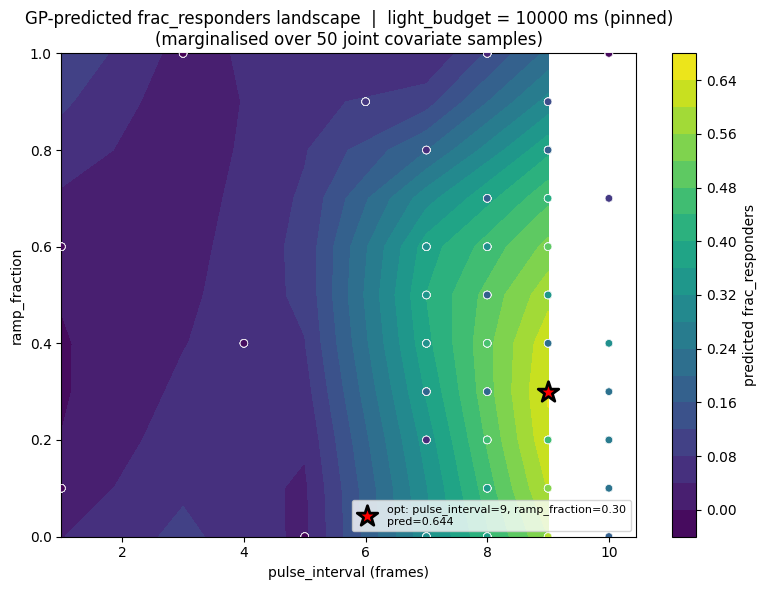

GP-predicted optimum (marginalised over covariates):
  pulse_interval = 9
  ramp_fraction  = 0.30
  predicted frac_responders = 0.6436
  light_budget   = 10000 ms (pinned)


In [17]:
# GP-predicted landscape (single 2D heatmap), marginalised over covariates
# the SAME way the BO acquisition does: average GP predictions over joint
# samples from the empirical covariate distribution.
import gpax
import gpax.utils
from faro.agents.bo_optimization_sparse import _safe_batch_size

if agent.model is not None and agent.x is not None:
    obj_name = agent.objective_metric.name
    rng_key, rng_key_pred = gpax.utils.get_keys()

    rf_vals = np.arange(0.0, 1.0 + 0.1, 0.1)  # 11 levels
    pi_vals = np.arange(1, 10, 2, dtype=float)  # {1,3,5,7,9}
    n_r = len(rf_vals)
    n_pi = len(pi_vals)

    df = agent.df_results
    n_cov_samples = 50
    cov_vals_full = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    if cov_vals_full.shape[0] == 0:
        raise RuntimeError("No covariate observations available for marginalisation.")
    _rng = np.random.default_rng(0)
    idx = _rng.integers(0, cov_vals_full.shape[0], size=n_cov_samples)
    cov_samples = cov_vals_full[idx]

    ctrl_grid = np.array([[r, pi] for r in rf_vals for pi in pi_vals])
    n_grid = ctrl_grid.shape[0]

    x_full = np.hstack(
        [
            np.repeat(ctrl_grid, n_cov_samples, axis=0),
            np.tile(cov_samples, (n_grid, 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    n_rows = np.asarray(x_full_scaled).shape[0]
    bs = _safe_batch_size(n_rows, 2000)
    y_pred_scaled, _ = agent.model.predict_in_batches(
        rng_key_pred,
        x_full_scaled,
        batch_size=bs,
        n=1,
        noiseless=True,
    )
    y_pred = agent._y_scaler.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).flatten()

    Y_marg = y_pred.reshape(n_grid, n_cov_samples).mean(axis=1)
    Y_grid = Y_marg.reshape(n_r, n_pi)

    flat_idx = int(np.argmax(Y_grid))
    r_idx, pi_idx = np.unravel_index(flat_idx, (n_r, n_pi))
    opt_r, opt_pi, opt_val = (
        float(rf_vals[r_idx]),
        int(pi_vals[pi_idx]),
        float(Y_grid[r_idx, pi_idx]),
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(
        pi_vals.astype(int),
        rf_vals,
        Y_grid,
        levels=20,
        cmap="viridis",
    )
    fig.colorbar(cf, ax=ax, label=f"predicted {obj_name}")

    if not df.empty:
        ax.scatter(
            df["pulse_interval"].astype(int),
            df["ramp_fraction"],
            c=df[obj_name],
            cmap="viridis",
            s=30,
            edgecolors="white",
            linewidths=0.5,
            zorder=5,
        )

    ax.scatter(
        opt_pi,
        opt_r,
        c="red",
        s=240,
        marker="*",
        edgecolors="black",
        linewidths=2,
        zorder=10,
        label=f"opt: pulse_interval={opt_pi}, ramp_fraction={opt_r:.2f}\npred={opt_val:.3f}",
    )
    ax.set_xlabel("pulse_interval (frames)")
    ax.set_ylabel("ramp_fraction")
    ax.set_title(
        f"GP-predicted {obj_name} landscape  |  light_budget = {LIGHT_BUDGET_MS:.0f} ms (pinned)\n"
        f"(marginalised over {n_cov_samples} joint covariate samples)"
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(
        f"GP-predicted optimum (marginalised over covariates):\n"
        f"  pulse_interval = {opt_pi}\n"
        f"  ramp_fraction  = {opt_r:.2f}\n"
        f"  predicted {obj_name} = {opt_val:.4f}\n"
        f"  light_budget   = {LIGHT_BUDGET_MS:.0f} ms (pinned)"
    )

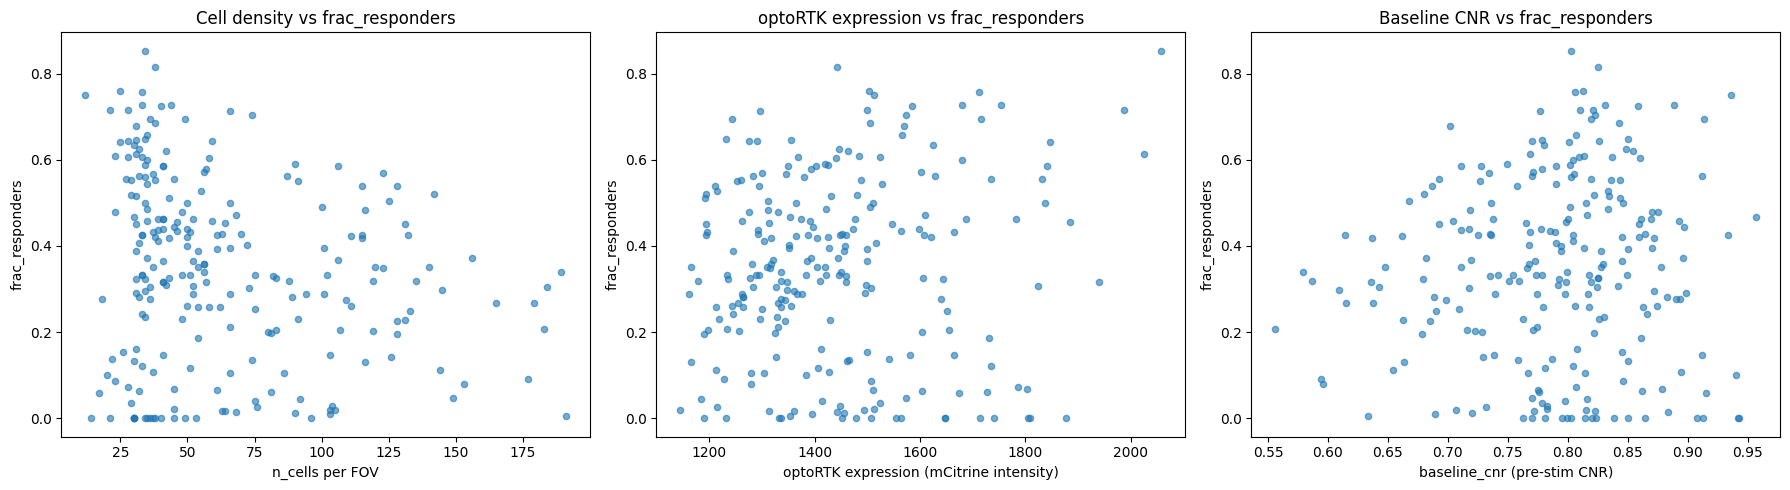

In [18]:
# Covariate effects on the configured BO objective (per FOV)
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results
    obj_name = agent.objective_metric.name

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(df["n_cells"], df[obj_name], alpha=0.6, s=20)
    axes[0].set_xlabel("n_cells per FOV")
    axes[0].set_ylabel(obj_name)
    axes[0].set_title(f"Cell density vs {obj_name}")

    axes[1].scatter(df["optortk_expression"], df[obj_name], alpha=0.6, s=20)
    axes[1].set_xlabel("optoRTK expression (mCitrine intensity)")
    axes[1].set_ylabel(obj_name)
    axes[1].set_title(f"optoRTK expression vs {obj_name}")

    axes[2].scatter(df["baseline_cnr"], df[obj_name], alpha=0.6, s=20)
    axes[2].set_xlabel("baseline_cnr (pre-stim CNR)")
    axes[2].set_ylabel(obj_name)
    axes[2].set_title(f"Baseline CNR vs {obj_name}")

    plt.tight_layout()
    plt.show()

In [19]:
import pandas as pd
import glob, os

# Per-phase delta of conditions tested.  Each checkpoint stores the
# cumulative df_results, so phase N's new conditions = rows in ckpt N
# that aren't in ckpt N-1.  Rendered in BO-axis terms (ramp_fraction,
# pulse_interval) since those are what the BO actually searches over;
# light_budget is pinned at LIGHT_BUDGET_MS for every condition.
RUN_PATH = path  # storage_path of this notebook's run
ckpts = sorted(
    glob.glob(os.path.join(RUN_PATH, "checkpoints", "bo_results_phase_*.parquet"))
)

prev_len = 0
summary = []
for f in ckpts:
    phase_id = int(os.path.basename(f).split("_")[-1].split(".")[0])
    df = pd.read_parquet(f)
    df_new = df.iloc[prev_len:]
    prev_len = len(df)
    conds = (
        df_new[["ramp_fraction", "pulse_interval"]].drop_duplicates().values.tolist()
    )
    summary.append(
        {
            "phase_id": phase_id,
            "n_fovs": len(df_new),
            "conditions": [f"(frac={r:.2f}, pi={int(p)})" for r, p in conds],
        }
    )

for row in summary:
    print(
        f"Phase {row['phase_id']:2d}  ({row['n_fovs']:2d} FOVs): "
        f"{'  |  '.join(row['conditions'])}"
    )

Phase  0  (17 FOVs): (frac=0.00, pi=5)  |  (frac=0.60, pi=1)  |  (frac=0.60, pi=7)
Phase  1  (18 FOVs): (frac=0.10, pi=1)  |  (frac=0.40, pi=4)  |  (frac=0.30, pi=7)
Phase  2  (18 FOVs): (frac=0.70, pi=8)  |  (frac=1.00, pi=8)  |  (frac=0.50, pi=9)
Phase  3  (18 FOVs): (frac=0.40, pi=9)  |  (frac=0.10, pi=9)  |  (frac=0.30, pi=10)
Phase  4  (18 FOVs): (frac=0.20, pi=9)  |  (frac=0.30, pi=9)  |  (frac=0.00, pi=9)
Phase  5  (18 FOVs): (frac=0.60, pi=9)  |  (frac=0.90, pi=6)  |  (frac=0.80, pi=9)
Phase  6  (18 FOVs): (frac=0.20, pi=8)  |  (frac=0.00, pi=8)  |  (frac=0.10, pi=8)
Phase  7  (18 FOVs): (frac=0.40, pi=8)  |  (frac=1.00, pi=10)  |  (frac=0.70, pi=10)
Phase  8  (18 FOVs): (frac=0.30, pi=8)  |  (frac=0.70, pi=9)  |  (frac=0.00, pi=10)
Phase  9  (18 FOVs): (frac=0.50, pi=7)  |  (frac=1.00, pi=3)  |  (frac=0.80, pi=7)
Phase 10  (18 FOVs): (frac=0.50, pi=8)  |  (frac=0.40, pi=7)  |  (frac=0.20, pi=7)
Phase 11  (18 FOVs): (frac=0.20, pi=10)  |  (frac=0.40, pi=10)  |  (frac=0.90, pi=9